
Reasoning Steps:
Question: Which animals can fly?
Step 1: Identify entities that are animals
Step 2: Check which animals can fly
Found animals that can fly: Eagle, Bat, Butterfly
Step 3: Verify that the answer is complete and correct
Conclusion: Eagle, Bat, Butterfly

Visualizing the ontology...


/tmp/ipykernel_1459460/3414792580.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


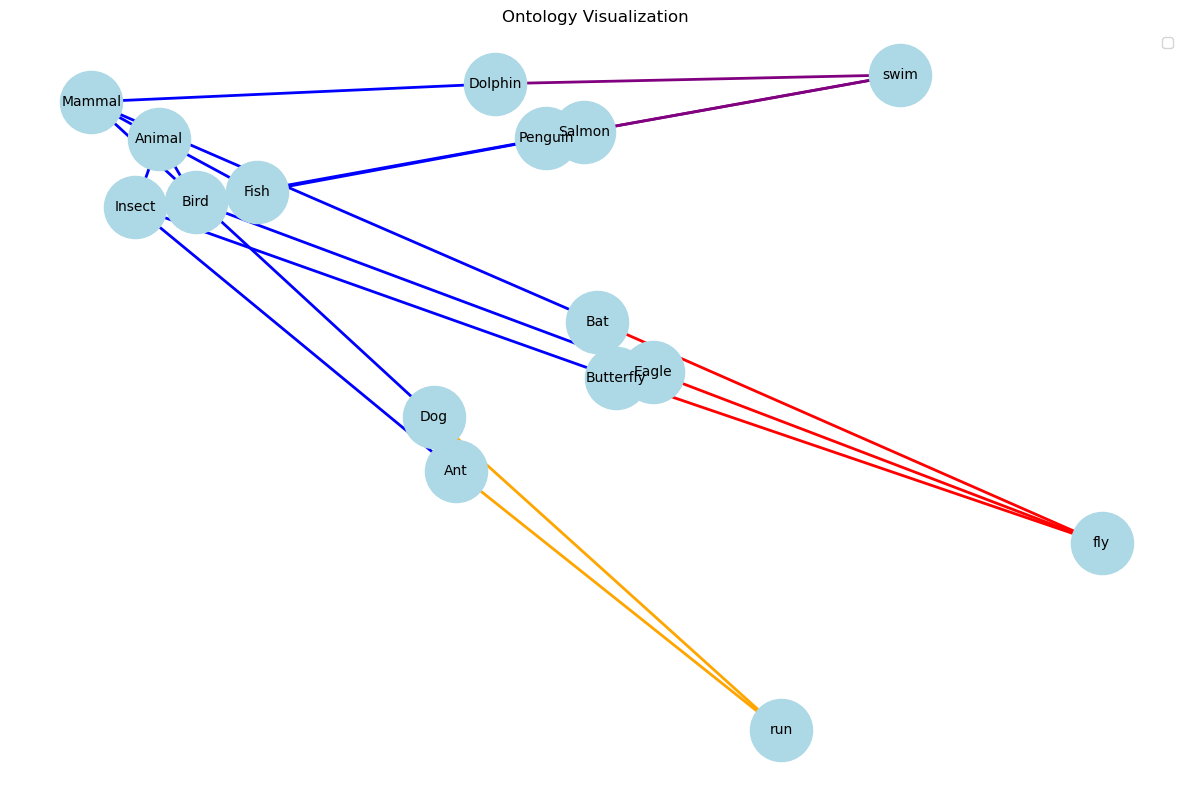

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Set

class OntologyReasoner:
    def __init__(self):
        # Initialize the ontology as a directed graph
        self.ontology = nx.DiGraph()
        
        # Store rules as (condition, consequence) pairs
        self.rules = []
        
        # Track relationships between entities
        self.relationships = {}
        
    def add_concept(self, concept: str, properties: Dict = None):
        """Add a concept to the ontology with optional properties"""
        if properties is None:
            properties = {}
        self.ontology.add_node(concept, **properties)
    
    def add_relationship(self, source: str, target: str, relation_type: str):
        """Add a relationship between two concepts"""
        self.ontology.add_edge(source, target, relation=relation_type)
        
        # Store the relationship for easier access
        if relation_type not in self.relationships:
            self.relationships[relation_type] = []
        self.relationships[relation_type].append((source, target))
    
    def add_rule(self, condition: str, consequence: str):
        """Add a rule to the ontology"""
        self.rules.append((condition, consequence))
    
    def get_subclasses(self, concept: str) -> List[str]:
        """Get all subclasses of a concept"""
        subclasses = []
        for source, target, data in self.ontology.edges(data=True):
            if target == concept and data['relation'] == 'is_a':
                subclasses.append(source)
                # Recursively get subclasses
                subclasses.extend(self.get_subclasses(source))
        return subclasses
    
    def get_properties(self, concept: str) -> Dict:
        """Get properties of a concept"""
        return self.ontology.nodes[concept]
    
    def apply_rules(self, facts: Set[str]) -> Set[str]:
        """Apply rules to derive new facts"""
        new_facts = facts.copy()
        changed = True
        
        while changed:
            changed = False
            for condition, consequence in self.rules:
                if condition in new_facts and consequence not in new_facts:
                    new_facts.add(consequence)
                    changed = True
                    
        return new_facts
    
    def reason(self, question: str, answer: str) -> List[str]:
        """Generate reasoning steps from a question to an answer"""
        # This is a simplified implementation
        # In a real system, you'd need NLP to parse the question
        
        reasoning_steps = ["Question: " + question]
        
        # Example patterns - in a real system this would be more sophisticated
        if "Which animals" in question:
            category = question.split("Which animals")[1].strip().strip("?")
            if "can" in category:
                ability = category.split("can")[1].strip()
                reasoning_steps.append(f"Step 1: Identify entities that are animals")
                
                # Find animals with the ability
                animals_with_ability = []
                for source, target in self.relationships.get(f"can_{ability}", []):
                    animals_with_ability.append(source)
                
                reasoning_steps.append(f"Step 2: Check which animals can {ability}")
                reasoning_steps.append(f"Found animals that can {ability}: {', '.join(animals_with_ability)}")
                
                # Verify against answer
                expected_animals = [a.strip() for a in answer.split(',')]
                found_all = all(animal in animals_with_ability for animal in expected_animals)
                
                if found_all:
                    reasoning_steps.append(f"Step 3: Verify that the answer is complete and correct")
                    reasoning_steps.append(f"Conclusion: {answer}")
                else:
                    reasoning_steps.append(f"Step 3: The derived answer doesn't match the expected answer")
                    reasoning_steps.append(f"Expected: {answer}")
                    reasoning_steps.append(f"Derived: {', '.join(animals_with_ability)}")
        
        return reasoning_steps
    
    def visualize(self):
        """Visualize the ontology"""
        plt.figure(figsize=(12, 8))
        
        # Create position layout
        pos = nx.spring_layout(self.ontology)
        
        # Draw nodes
        nx.draw_networkx_nodes(self.ontology, pos, node_size=2000, node_color="lightblue")
        
        # Draw edges with different colors based on relation type
        relation_colors = {
            'is_a': 'blue',
            'has_part': 'green',
            'can_fly': 'red',
            'can_swim': 'purple',
            'can_run': 'orange'
        }
        
        for relation, color in relation_colors.items():
            edges = [(s, t) for s, t, d in self.ontology.edges(data=True) if d['relation'] == relation]
            if edges:
                nx.draw_networkx_edges(self.ontology, pos, edgelist=edges, 
                                      edge_color=color, width=2, label=relation)
        
        # Draw labels
        nx.draw_networkx_labels(self.ontology, pos, font_size=10)
        
        plt.title("Ontology Visualization")
        plt.legend()
        plt.axis('off')
        plt.tight_layout()
        plt.show()


# Example usage
def create_animal_ontology():
    reasoner = OntologyReasoner()
    
    # Add concepts
    reasoner.add_concept("Animal")
    reasoner.add_concept("Bird")
    reasoner.add_concept("Mammal")
    reasoner.add_concept("Fish")
    reasoner.add_concept("Insect")
    
    # Add specific animals
    reasoner.add_concept("Eagle")
    reasoner.add_concept("Penguin")
    reasoner.add_concept("Bat")
    reasoner.add_concept("Dog")
    reasoner.add_concept("Dolphin")
    reasoner.add_concept("Salmon")
    reasoner.add_concept("Butterfly")
    reasoner.add_concept("Ant")
    
    # Add taxonomy relationships
    reasoner.add_relationship("Bird", "Animal", "is_a")
    reasoner.add_relationship("Mammal", "Animal", "is_a")
    reasoner.add_relationship("Fish", "Animal", "is_a")
    reasoner.add_relationship("Insect", "Animal", "is_a")
    
    reasoner.add_relationship("Eagle", "Bird", "is_a")
    reasoner.add_relationship("Penguin", "Bird", "is_a")
    reasoner.add_relationship("Bat", "Mammal", "is_a")
    reasoner.add_relationship("Dog", "Mammal", "is_a")
    reasoner.add_relationship("Dolphin", "Mammal", "is_a")
    reasoner.add_relationship("Salmon", "Fish", "is_a")
    reasoner.add_relationship("Butterfly", "Insect", "is_a")
    reasoner.add_relationship("Ant", "Insect", "is_a")
    
    # Add capabilities
    reasoner.add_relationship("Eagle", "fly", "can_fly")
    reasoner.add_relationship("Bat", "fly", "can_fly")
    reasoner.add_relationship("Butterfly", "fly", "can_fly")
    
    reasoner.add_relationship("Penguin", "swim", "can_swim")
    reasoner.add_relationship("Dolphin", "swim", "can_swim")
    reasoner.add_relationship("Salmon", "swim", "can_swim")
    
    reasoner.add_relationship("Dog", "run", "can_run")
    reasoner.add_relationship("Ant", "run", "can_run")
    
    # Add rules
    # If an animal can fly, it can move through air
    reasoner.add_rule("can_fly", "can_move_through_air")
    
    return reasoner

def demonstrate_reasoning():
    # Create ontology
    reasoner = create_animal_ontology()
    
    # Example question-answer pair
    question = "Which animals can fly?"
    answer = "Eagle, Bat, Butterfly"
    
    # Generate reasoning steps
    steps = reasoner.reason(question, answer)
    
    # Print the steps
    print("\nReasoning Steps:")
    for step in steps:
        print(step)
    
    # Visualize the ontology
    print("\nVisualizing the ontology...")
    reasoner.visualize()

if __name__ == "__main__":
    demonstrate_reasoning()


Reasoning Example 1:
Question: Which elements are metals with high reactivity?
Step 1: Identify elements that are metals
Step 2: Found elements with this property: Sodium (Na), Potassium (K), Calcium (Ca), Iron (Fe), Gold (Au)
Step 3: Verify that the answer is complete and correct
Conclusion: Sodium (Na), Potassium (K)

Reasoning Example 2:
Question: What happens in the reaction between Sodium (Na) and Water (H2O)?
Step 1: Identify the reactants: Sodium (Na) and Water (H2O)
Step 2: Find products of the reaction
Found products: Sodium Hydroxide (NaOH), Hydrogen (H)
Step 3: Applying chemistry rules
Applied rule: The reaction between sodium and water is highly exothermic (releases heat)
Applied rule: The reaction produces hydrogen gas, which can be observed as bubbles
Conclusion: Sodium hydroxide (NaOH) and hydrogen gas are produced in an exothermic reaction

Visualizing the chemistry ontology...


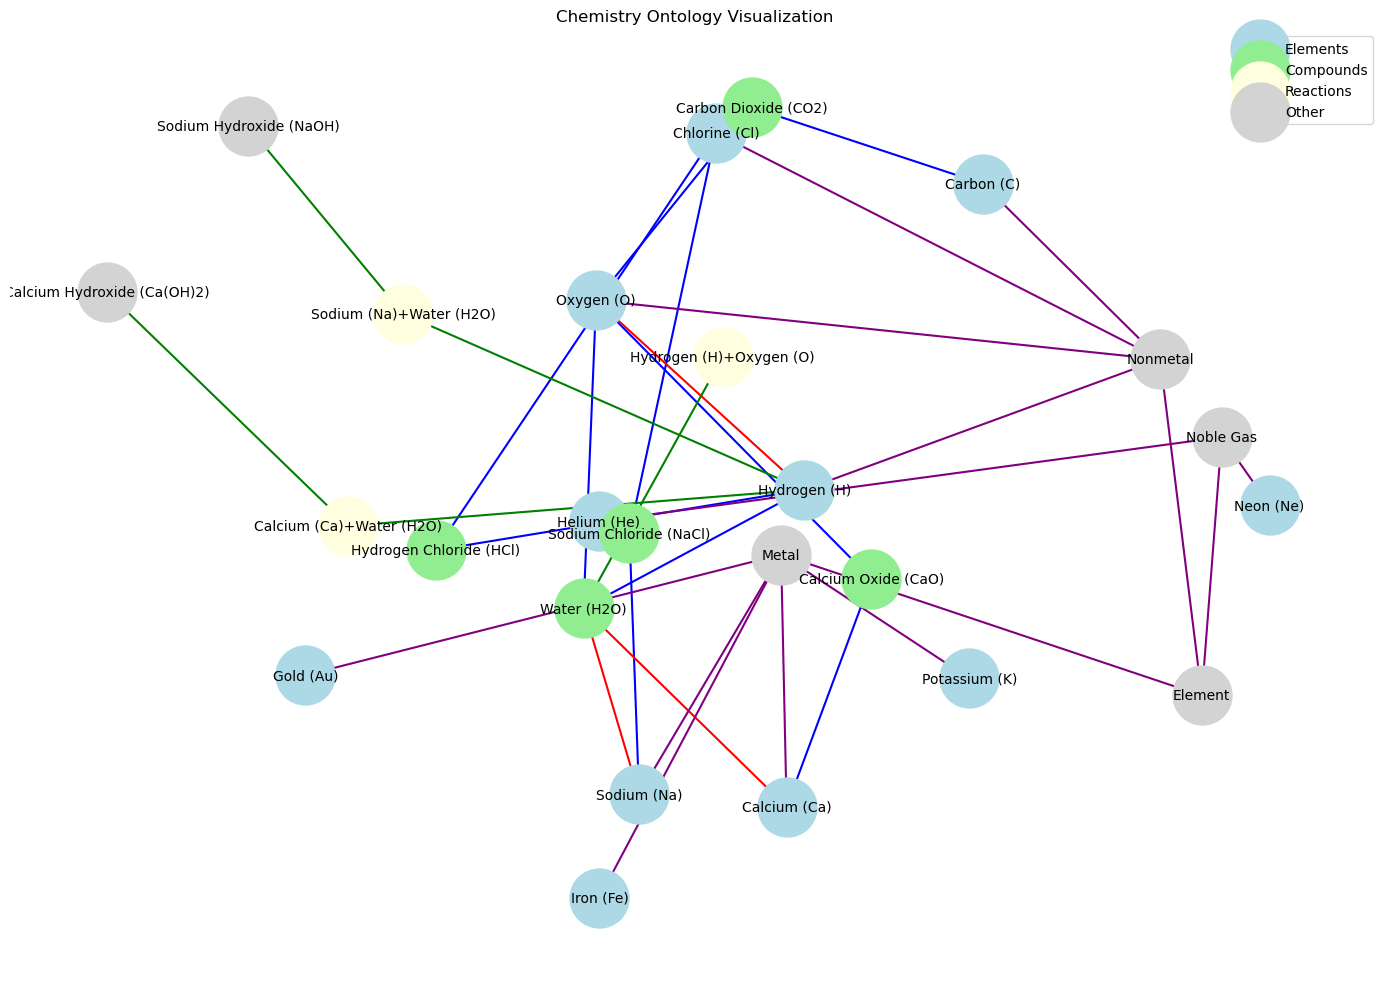

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Set

class OntologyReasoner:
    def __init__(self):
        # Initialize the ontology as a directed graph
        self.ontology = nx.DiGraph()
        
        # Store rules as (condition, consequence) pairs
        self.rules = []
        
        # Track relationships between entities
        self.relationships = {}
        
    def add_concept(self, concept: str, properties: Dict = None):
        """Add a concept to the ontology with optional properties"""
        if properties is None:
            properties = {}
        self.ontology.add_node(concept, **properties)
    
    def add_relationship(self, source: str, target: str, relation_type: str):
        """Add a relationship between two concepts"""
        self.ontology.add_edge(source, target, relation=relation_type)
        
        # Store the relationship for easier access
        if relation_type not in self.relationships:
            self.relationships[relation_type] = []
        self.relationships[relation_type].append((source, target))
    
    def add_rule(self, condition: str, consequence: str, description: str = None):
        """Add a rule to the ontology with optional description"""
        self.rules.append((condition, consequence, description))
    
    def get_related_concepts(self, concept: str, relation_type: str) -> List[str]:
        """Get all concepts related to a given concept by a specific relation type"""
        related = []
        for source, target, data in self.ontology.edges(data=True):
            if source == concept and data['relation'] == relation_type:
                related.append(target)
        return related
    
    def get_concepts_with_property(self, property_name: str, property_value=None) -> List[str]:
        """Get all concepts with a specific property"""
        concepts = []
        for node, properties in self.ontology.nodes(data=True):
            if property_name in properties:
                if property_value is None or properties[property_name] == property_value:
                    concepts.append(node)
        return concepts
    
    def apply_rules(self, facts: Set[str]) -> Tuple[Set[str], List[str]]:
        """Apply rules to derive new facts and return reasoning steps"""
        new_facts = facts.copy()
        reasoning_steps = []
        
        for condition, consequence, description in self.rules:
            if condition in new_facts and consequence not in new_facts:
                new_facts.add(consequence)
                if description:
                    reasoning_steps.append(f"Applied rule: {description}")
                else:
                    reasoning_steps.append(f"From '{condition}', derived '{consequence}'")
                    
        return new_facts, reasoning_steps
    
    def reason(self, question: str, answer: str) -> List[str]:
        """Generate reasoning steps from a question to an answer"""
        reasoning_steps = ["Question: " + question]
        
        # Chemistry question patterns
        if "Which elements" in question:
            property_name = None
            
            if "metal" in question.lower():
                property_name = "is_metal"
                value = True
                reasoning_steps.append("Step 1: Identify elements that are metals")
                
            elif "reactive" in question.lower():
                property_name = "reactivity"
                value = "high"
                reasoning_steps.append("Step 1: Identify elements with high reactivity")
            
            if property_name:
                elements = self.get_concepts_with_property(property_name, value)
                reasoning_steps.append(f"Step 2: Found elements with this property: {', '.join(elements)}")
                
                # Verify against answer
                expected_elements = [e.strip() for e in answer.split(',')]
                found_all = all(element in elements for element in expected_elements)
                
                if found_all:
                    reasoning_steps.append(f"Step 3: Verify that the answer is complete and correct")
                    reasoning_steps.append(f"Conclusion: {answer}")
                else:
                    reasoning_steps.append(f"Step 3: The derived answer doesn't match the expected answer")
                    reasoning_steps.append(f"Expected: {answer}")
                    reasoning_steps.append(f"Derived: {', '.join(elements)}")
        
        elif "reaction between" in question.lower():
            # Extract reactants from question
            parts = question.split("reaction between")[1].split("and")
            reactant1 = parts[0].strip().strip("?")
            reactant2 = parts[1].strip().strip("?")
            
            reasoning_steps.append(f"Step 1: Identify the reactants: {reactant1} and {reactant2}")
            
            # Look for reactions
            products = []
            for source, target, data in self.ontology.edges(data=True):
                if data['relation'] == "reacts_with" and source == reactant1 and target == reactant2:
                    products = self.get_related_concepts(f"{reactant1}+{reactant2}", "produces")
            
            if products:
                reasoning_steps.append(f"Step 2: Find products of the reaction")
                reasoning_steps.append(f"Found products: {', '.join(products)}")
                
                # Apply rules for additional information
                facts = set([f"reaction:{reactant1}+{reactant2}"])
                derived_facts, rule_steps = self.apply_rules(facts)
                
                if rule_steps:
                    reasoning_steps.append("Step 3: Applying chemistry rules")
                    reasoning_steps.extend(rule_steps)
                
                reasoning_steps.append(f"Conclusion: {answer}")
            else:
                reasoning_steps.append("Step 2: No reaction found in the ontology")
        
        return reasoning_steps
    
    def visualize(self):
        """Visualize the ontology"""
        plt.figure(figsize=(14, 10))
        
        # Create position layout
        pos = nx.spring_layout(self.ontology, k=0.8)
        
        # Draw nodes with different colors based on type
        element_nodes = [node for node in self.ontology.nodes() if self.ontology.nodes[node].get('is_element', False)]
        compound_nodes = [node for node in self.ontology.nodes() if self.ontology.nodes[node].get('is_compound', False)]
        reaction_nodes = [node for node in self.ontology.nodes() if "+" in node]
        other_nodes = [node for node in self.ontology.nodes() if node not in element_nodes + compound_nodes + reaction_nodes]
        
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=element_nodes, node_size=1800, node_color="lightblue", label="Elements")
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=compound_nodes, node_size=1800, node_color="lightgreen", label="Compounds")
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=reaction_nodes, node_size=1800, node_color="lightyellow", label="Reactions")
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=other_nodes, node_size=1800, node_color="lightgray", label="Other")
        
        # Draw edges with different colors based on relation type
        relation_colors = {
            'has_element': 'blue',
            'reacts_with': 'red',
            'produces': 'green',
            'is_type': 'purple'
        }
        
        for relation, color in relation_colors.items():
            edges = [(s, t) for s, t, d in self.ontology.edges(data=True) if d['relation'] == relation]
            if edges:
                nx.draw_networkx_edges(self.ontology, pos, edgelist=edges, 
                                      edge_color=color, width=1.5, label=relation)
        
        # Draw labels
        nx.draw_networkx_labels(self.ontology, pos, font_size=10)
        
        plt.title("Chemistry Ontology Visualization")
        plt.legend()
        plt.axis('off')
        plt.tight_layout()
        plt.show()


# Create a chemistry ontology
def create_chemistry_ontology():
    reasoner = OntologyReasoner()
    
    # Add element categories
    reasoner.add_concept("Element")
    reasoner.add_concept("Metal")
    reasoner.add_concept("Nonmetal")
    reasoner.add_concept("Noble Gas")
    
    # Add relationships for categories
    reasoner.add_relationship("Metal", "Element", "is_type")
    reasoner.add_relationship("Nonmetal", "Element", "is_type")
    reasoner.add_relationship("Noble Gas", "Element", "is_type")
    
    # Add elements with properties
    # Metals
    reasoner.add_concept("Sodium (Na)", {"is_element": True, "is_metal": True, "reactivity": "high", "atomic_number": 11})
    reasoner.add_concept("Potassium (K)", {"is_element": True, "is_metal": True, "reactivity": "high", "atomic_number": 19})
    reasoner.add_concept("Calcium (Ca)", {"is_element": True, "is_metal": True, "reactivity": "medium", "atomic_number": 20})
    reasoner.add_concept("Iron (Fe)", {"is_element": True, "is_metal": True, "reactivity": "low", "atomic_number": 26})
    reasoner.add_concept("Gold (Au)", {"is_element": True, "is_metal": True, "reactivity": "very_low", "atomic_number": 79})
    
    # Nonmetals
    reasoner.add_concept("Oxygen (O)", {"is_element": True, "is_metal": False, "reactivity": "high", "atomic_number": 8})
    reasoner.add_concept("Chlorine (Cl)", {"is_element": True, "is_metal": False, "reactivity": "high", "atomic_number": 17})
    reasoner.add_concept("Carbon (C)", {"is_element": True, "is_metal": False, "reactivity": "medium", "atomic_number": 6})
    reasoner.add_concept("Hydrogen (H)", {"is_element": True, "is_metal": False, "reactivity": "medium", "atomic_number": 1})
    
    # Noble gases
    reasoner.add_concept("Helium (He)", {"is_element": True, "is_metal": False, "reactivity": "very_low", "atomic_number": 2})
    reasoner.add_concept("Neon (Ne)", {"is_element": True, "is_metal": False, "reactivity": "very_low", "atomic_number": 10})
    
    # Add element type relationships
    reasoner.add_relationship("Sodium (Na)", "Metal", "is_type")
    reasoner.add_relationship("Potassium (K)", "Metal", "is_type")
    reasoner.add_relationship("Calcium (Ca)", "Metal", "is_type")
    reasoner.add_relationship("Iron (Fe)", "Metal", "is_type")
    reasoner.add_relationship("Gold (Au)", "Metal", "is_type")
    
    reasoner.add_relationship("Oxygen (O)", "Nonmetal", "is_type")
    reasoner.add_relationship("Chlorine (Cl)", "Nonmetal", "is_type")
    reasoner.add_relationship("Carbon (C)", "Nonmetal", "is_type")
    reasoner.add_relationship("Hydrogen (H)", "Nonmetal", "is_type")
    
    reasoner.add_relationship("Helium (He)", "Noble Gas", "is_type")
    reasoner.add_relationship("Neon (Ne)", "Noble Gas", "is_type")
    
    # Add compounds
    reasoner.add_concept("Water (H2O)", {"is_compound": True, "state": "liquid"})
    reasoner.add_concept("Sodium Chloride (NaCl)", {"is_compound": True, "state": "solid"})
    reasoner.add_concept("Calcium Oxide (CaO)", {"is_compound": True, "state": "solid"})
    reasoner.add_concept("Carbon Dioxide (CO2)", {"is_compound": True, "state": "gas"})
    reasoner.add_concept("Hydrogen Chloride (HCl)", {"is_compound": True, "state": "gas"})
    
    # Add compound composition
    reasoner.add_relationship("Water (H2O)", "Hydrogen (H)", "has_element")
    reasoner.add_relationship("Water (H2O)", "Oxygen (O)", "has_element")
    
    reasoner.add_relationship("Sodium Chloride (NaCl)", "Sodium (Na)", "has_element")
    reasoner.add_relationship("Sodium Chloride (NaCl)", "Chlorine (Cl)", "has_element")
    
    reasoner.add_relationship("Calcium Oxide (CaO)", "Calcium (Ca)", "has_element")
    reasoner.add_relationship("Calcium Oxide (CaO)", "Oxygen (O)", "has_element")
    
    reasoner.add_relationship("Carbon Dioxide (CO2)", "Carbon (C)", "has_element")
    reasoner.add_relationship("Carbon Dioxide (CO2)", "Oxygen (O)", "has_element")
    
    reasoner.add_relationship("Hydrogen Chloride (HCl)", "Hydrogen (H)", "has_element")
    reasoner.add_relationship("Hydrogen Chloride (HCl)", "Chlorine (Cl)", "has_element")
    
    # Add reactions
    reasoner.add_concept("Sodium (Na)+Water (H2O)")
    reasoner.add_concept("Calcium (Ca)+Water (H2O)")
    reasoner.add_concept("Hydrogen (H)+Oxygen (O)")
    reasoner.add_relationship("Sodium (Na)", "Water (H2O)", "reacts_with")
    reasoner.add_relationship("Sodium (Na)+Water (H2O)", "Sodium Hydroxide (NaOH)", "produces")
    reasoner.add_relationship("Sodium (Na)+Water (H2O)", "Hydrogen (H)", "produces")
    
    reasoner.add_relationship("Calcium (Ca)", "Water (H2O)", "reacts_with")
    reasoner.add_relationship("Calcium (Ca)+Water (H2O)", "Calcium Hydroxide (Ca(OH)2)", "produces")
    reasoner.add_relationship("Calcium (Ca)+Water (H2O)", "Hydrogen (H)", "produces")
    
    reasoner.add_relationship("Hydrogen (H)", "Oxygen (O)", "reacts_with")
    reasoner.add_relationship("Hydrogen (H)+Oxygen (O)", "Water (H2O)", "produces")
    
    # Add rules
    reasoner.add_rule("reaction:Sodium (Na)+Water (H2O)", 
                     "exothermic", 
                     "The reaction between sodium and water is highly exothermic (releases heat)")
    
    reasoner.add_rule("reaction:Sodium (Na)+Water (H2O)", 
                     "hydrogen_gas", 
                     "The reaction produces hydrogen gas, which can be observed as bubbles")
    
    reasoner.add_rule("reaction:Calcium (Ca)+Water (H2O)", 
                     "less_exothermic", 
                     "The reaction between calcium and water is less violent than sodium and water")
    
    return reasoner

def demonstrate_chemistry_reasoning():
    # Create ontology
    reasoner = create_chemistry_ontology()
    
    # Example question-answer pairs
    q1 = "Which elements are metals with high reactivity?"
    a1 = "Sodium (Na), Potassium (K)"
    
    q2 = "What happens in the reaction between Sodium (Na) and Water (H2O)?"
    a2 = "Sodium hydroxide (NaOH) and hydrogen gas are produced in an exothermic reaction"
    
    # Generate reasoning steps
    steps1 = reasoner.reason(q1, a1)
    steps2 = reasoner.reason(q2, a2)
    
    # Print the steps
    print("\nReasoning Example 1:")
    for step in steps1:
        print(step)
    
    print("\nReasoning Example 2:")
    for step in steps2:
        print(step)
    
    # Visualize the ontology
    print("\nVisualizing the chemistry ontology...")
    reasoner.visualize()

if __name__ == "__main__":
    demonstrate_chemistry_reasoning()


=== CHEMISTRY REASONING EXAMPLES ===

 EXAMPLE 1: Property-based Query
Question: Which elements are metals with high reactivity?
Step 1: Identify elements that are metals
Step 2: Found elements with this property: Sodium (Na), Potassium (K), Calcium (Ca), Iron (Fe), Gold (Au)
Step 3: Verify that the answer is complete and correct
Conclusion: Sodium (Na), Potassium (K)

 EXAMPLE 2: Reaction Analysis Query
Question: What happens in the reaction between Sodium (Na) and Water (H2O)?
Step 1: Identify the reactants: Sodium (Na) and Water (H2O)
Step 2: Find products of the reaction
Found products: Sodium Hydroxide (NaOH), Hydrogen (H)
Step 3: Applying chemistry rules
Applied rule: The reaction between sodium and water is highly exothermic (releases heat)
Applied rule: The reaction produces hydrogen gas, which can be observed as bubbles
Conclusion: Sodium hydroxide (NaOH) and hydrogen gas are produced in an exothermic reaction

 CUSTOM QUERIES

Query: Find all non-metal elements
Non-metal ele

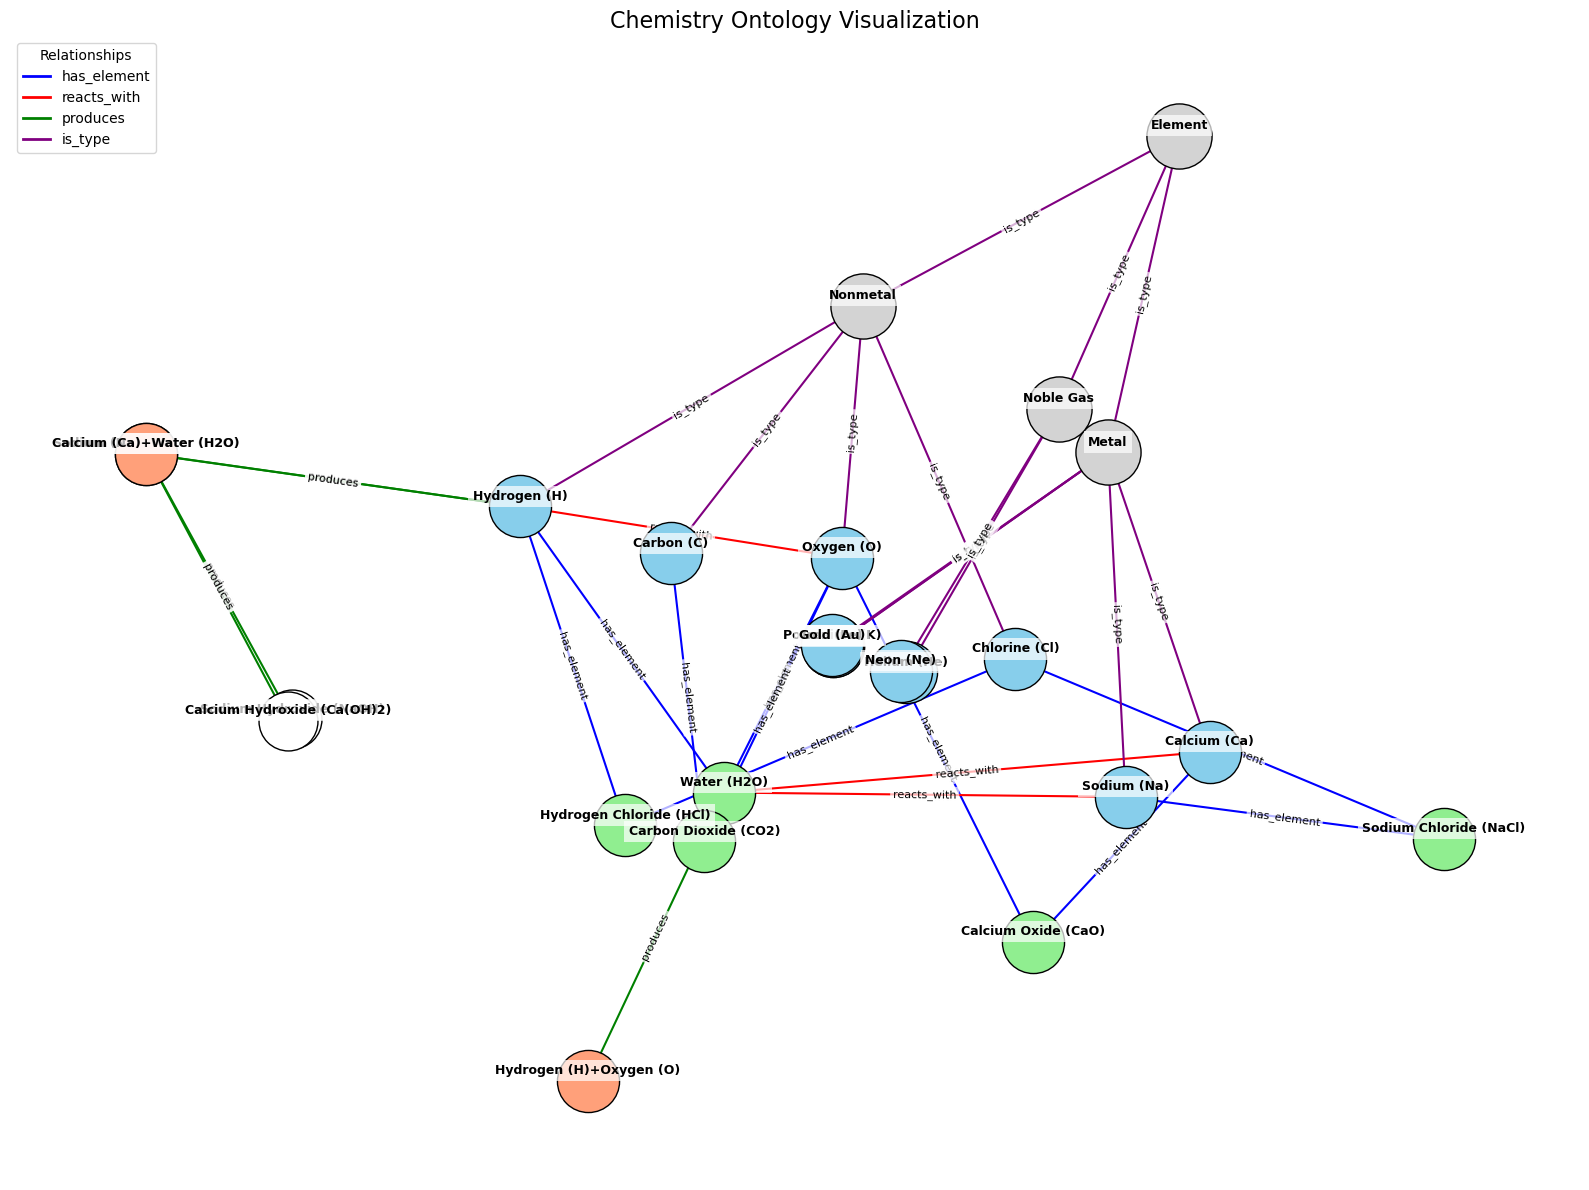

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Set

class OntologyReasoner:
    def __init__(self):
        # Initialize the ontology as a directed graph
        self.ontology = nx.DiGraph()
        
        # Store rules as (condition, consequence) pairs
        self.rules = []
        
        # Track relationships between entities
        self.relationships = {}
        
    def add_concept(self, concept: str, properties: Dict = None):
        """Add a concept to the ontology with optional properties"""
        if properties is None:
            properties = {}
        self.ontology.add_node(concept, **properties)
    
    def add_relationship(self, source: str, target: str, relation_type: str):
        """Add a relationship between two concepts"""
        self.ontology.add_edge(source, target, relation=relation_type)
        
        # Store the relationship for easier access
        if relation_type not in self.relationships:
            self.relationships[relation_type] = []
        self.relationships[relation_type].append((source, target))
    
    def add_rule(self, condition: str, consequence: str, description: str = None):
        """Add a rule to the ontology with optional description"""
        self.rules.append((condition, consequence, description))
    
    def get_related_concepts(self, concept: str, relation_type: str) -> List[str]:
        """Get all concepts related to a given concept by a specific relation type"""
        related = []
        for source, target, data in self.ontology.edges(data=True):
            if source == concept and data['relation'] == relation_type:
                related.append(target)
        return related
    
    def get_concepts_with_property(self, property_name: str, property_value=None) -> List[str]:
        """Get all concepts with a specific property"""
        concepts = []
        for node, properties in self.ontology.nodes(data=True):
            if property_name in properties:
                if property_value is None or properties[property_name] == property_value:
                    concepts.append(node)
        return concepts
    
    def apply_rules(self, facts: Set[str]) -> Tuple[Set[str], List[str]]:
        """Apply rules to derive new facts and return reasoning steps"""
        new_facts = facts.copy()
        reasoning_steps = []
        
        for condition, consequence, description in self.rules:
            if condition in new_facts and consequence not in new_facts:
                new_facts.add(consequence)
                if description:
                    reasoning_steps.append(f"Applied rule: {description}")
                else:
                    reasoning_steps.append(f"From '{condition}', derived '{consequence}'")
                    
        return new_facts, reasoning_steps
    
    def reason(self, question: str, answer: str) -> List[str]:
        """Generate reasoning steps from a question to an answer"""
        reasoning_steps = ["Question: " + question]
        
        # Chemistry question patterns
        if "Which elements" in question:
            property_name = None
            
            if "metal" in question.lower():
                property_name = "is_metal"
                value = True
                reasoning_steps.append("Step 1: Identify elements that are metals")
                
            elif "reactive" in question.lower():
                property_name = "reactivity"
                value = "high"
                reasoning_steps.append("Step 1: Identify elements with high reactivity")
            
            if property_name:
                elements = self.get_concepts_with_property(property_name, value)
                reasoning_steps.append(f"Step 2: Found elements with this property: {', '.join(elements)}")
                
                # Verify against answer
                expected_elements = [e.strip() for e in answer.split(',')]
                found_all = all(element in elements for element in expected_elements)
                
                if found_all:
                    reasoning_steps.append(f"Step 3: Verify that the answer is complete and correct")
                    reasoning_steps.append(f"Conclusion: {answer}")
                else:
                    reasoning_steps.append(f"Step 3: The derived answer doesn't match the expected answer")
                    reasoning_steps.append(f"Expected: {answer}")
                    reasoning_steps.append(f"Derived: {', '.join(elements)}")
        
        elif "reaction between" in question.lower():
            # Extract reactants from question
            parts = question.split("reaction between")[1].split("and")
            reactant1 = parts[0].strip().strip("?")
            reactant2 = parts[1].strip().strip("?")
            
            reasoning_steps.append(f"Step 1: Identify the reactants: {reactant1} and {reactant2}")
            
            # Look for reactions
            products = []
            for source, target, data in self.ontology.edges(data=True):
                if data['relation'] == "reacts_with" and source == reactant1 and target == reactant2:
                    products = self.get_related_concepts(f"{reactant1}+{reactant2}", "produces")
            
            if products:
                reasoning_steps.append(f"Step 2: Find products of the reaction")
                reasoning_steps.append(f"Found products: {', '.join(products)}")
                
                # Apply rules for additional information
                facts = set([f"reaction:{reactant1}+{reactant2}"])
                derived_facts, rule_steps = self.apply_rules(facts)
                
                if rule_steps:
                    reasoning_steps.append("Step 3: Applying chemistry rules")
                    reasoning_steps.extend(rule_steps)
                
                reasoning_steps.append(f"Conclusion: {answer}")
            else:
                reasoning_steps.append("Step 2: No reaction found in the ontology")
        
        return reasoning_steps
    
    def visualize(self):
        """Visualize the ontology with improved readability"""
        plt.figure(figsize=(16, 12))
        
        # Create position layout with more spacing
        pos = nx.kamada_kawai_layout(self.ontology)  # Better for dense graphs
        
        # Draw nodes with different colors based on type
        element_nodes = [node for node in self.ontology.nodes() if self.ontology.nodes[node].get('is_element', False)]
        compound_nodes = [node for node in self.ontology.nodes() if self.ontology.nodes[node].get('is_compound', False)]
        reaction_nodes = [node for node in self.ontology.nodes() if "+" in node]
        category_nodes = ["Element", "Metal", "Nonmetal", "Noble Gas"]
        other_nodes = [node for node in self.ontology.nodes() if (node not in element_nodes and 
                                                                  node not in compound_nodes and 
                                                                  node not in reaction_nodes and
                                                                  node not in category_nodes)]
        
        # Draw different node types
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=element_nodes, node_size=2000, 
                               node_color="skyblue", label="Elements", edgecolors='black')
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=compound_nodes, node_size=2000, 
                               node_color="lightgreen", label="Compounds", edgecolors='black')
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=reaction_nodes, node_size=2000, 
                               node_color="lightsalmon", label="Reactions", edgecolors='black')
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=category_nodes, node_size=2200, 
                               node_color="lightgray", label="Categories", edgecolors='black')
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=other_nodes, node_size=1800, 
                               node_color="white", label="Other", edgecolors='black')
        
        # Draw edges with different colors and add edge labels
        relation_colors = {
            'has_element': 'blue',
            'reacts_with': 'red',
            'produces': 'green', 
            'is_type': 'purple'
        }
        
        # Create separate edge lists for drawing
        all_edges = []
        edge_colors = []
        
        # Draw edge labels separately for better visibility
        edge_labels = {}
        
        for relation, color in relation_colors.items():
            edges = [(s, t) for s, t, d in self.ontology.edges(data=True) if d['relation'] == relation]
            
            if edges:
                # Add edges to the master list
                all_edges.extend(edges)
                edge_colors.extend([color] * len(edges))
                
                # Create edge labels
                for s, t in edges:
                    edge_labels[(s, t)] = relation
        
        # Draw all edges at once
        nx.draw_networkx_edges(self.ontology, pos, edgelist=all_edges, 
                               edge_color=edge_colors, width=1.5, arrows=True, 
                               arrowsize=15, arrowstyle='->')
        
        # Draw edge labels with background
        nx.draw_networkx_edge_labels(self.ontology, pos, edge_labels=edge_labels, 
                                     font_size=8, font_color='black',
                                     bbox=dict(facecolor='white', edgecolor='none', 
                                              alpha=0.7, pad=2))
        
        # Draw node labels more clearly
        label_pos = {k: (v[0], v[1] + 0.02) for k, v in pos.items()}  # Adjust label positions
        nx.draw_networkx_labels(self.ontology, label_pos, font_size=9, font_weight='bold',
                               bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=3))
        
        # Create custom legend for edge types
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='blue', lw=2, label='has_element'),
            Line2D([0], [0], color='red', lw=2, label='reacts_with'),
            Line2D([0], [0], color='green', lw=2, label='produces'),
            Line2D([0], [0], color='purple', lw=2, label='is_type')
        ]
        
        # Add a title and legend
        plt.title("Chemistry Ontology Visualization", fontsize=16)
        plt.legend(handles=legend_elements, loc='upper left', title="Relationships")
        
        plt.axis('off')
        plt.tight_layout()
        plt.show()


# Create a chemistry ontology
def create_chemistry_ontology():
    reasoner = OntologyReasoner()
    
    # Add element categories
    reasoner.add_concept("Element")
    reasoner.add_concept("Metal")
    reasoner.add_concept("Nonmetal")
    reasoner.add_concept("Noble Gas")
    
    # Add relationships for categories
    reasoner.add_relationship("Metal", "Element", "is_type")
    reasoner.add_relationship("Nonmetal", "Element", "is_type")
    reasoner.add_relationship("Noble Gas", "Element", "is_type")
    
    # Add elements with properties
    # Metals
    reasoner.add_concept("Sodium (Na)", {"is_element": True, "is_metal": True, "reactivity": "high", "atomic_number": 11})
    reasoner.add_concept("Potassium (K)", {"is_element": True, "is_metal": True, "reactivity": "high", "atomic_number": 19})
    reasoner.add_concept("Calcium (Ca)", {"is_element": True, "is_metal": True, "reactivity": "medium", "atomic_number": 20})
    reasoner.add_concept("Iron (Fe)", {"is_element": True, "is_metal": True, "reactivity": "low", "atomic_number": 26})
    reasoner.add_concept("Gold (Au)", {"is_element": True, "is_metal": True, "reactivity": "very_low", "atomic_number": 79})
    
    # Nonmetals
    reasoner.add_concept("Oxygen (O)", {"is_element": True, "is_metal": False, "reactivity": "high", "atomic_number": 8})
    reasoner.add_concept("Chlorine (Cl)", {"is_element": True, "is_metal": False, "reactivity": "high", "atomic_number": 17})
    reasoner.add_concept("Carbon (C)", {"is_element": True, "is_metal": False, "reactivity": "medium", "atomic_number": 6})
    reasoner.add_concept("Hydrogen (H)", {"is_element": True, "is_metal": False, "reactivity": "medium", "atomic_number": 1})
    
    # Noble gases
    reasoner.add_concept("Helium (He)", {"is_element": True, "is_metal": False, "reactivity": "very_low", "atomic_number": 2})
    reasoner.add_concept("Neon (Ne)", {"is_element": True, "is_metal": False, "reactivity": "very_low", "atomic_number": 10})
    
    # Add element type relationships
    reasoner.add_relationship("Sodium (Na)", "Metal", "is_type")
    reasoner.add_relationship("Potassium (K)", "Metal", "is_type")
    reasoner.add_relationship("Calcium (Ca)", "Metal", "is_type")
    reasoner.add_relationship("Iron (Fe)", "Metal", "is_type")
    reasoner.add_relationship("Gold (Au)", "Metal", "is_type")
    
    reasoner.add_relationship("Oxygen (O)", "Nonmetal", "is_type")
    reasoner.add_relationship("Chlorine (Cl)", "Nonmetal", "is_type")
    reasoner.add_relationship("Carbon (C)", "Nonmetal", "is_type")
    reasoner.add_relationship("Hydrogen (H)", "Nonmetal", "is_type")
    
    reasoner.add_relationship("Helium (He)", "Noble Gas", "is_type")
    reasoner.add_relationship("Neon (Ne)", "Noble Gas", "is_type")
    
    # Add compounds
    reasoner.add_concept("Water (H2O)", {"is_compound": True, "state": "liquid"})
    reasoner.add_concept("Sodium Chloride (NaCl)", {"is_compound": True, "state": "solid"})
    reasoner.add_concept("Calcium Oxide (CaO)", {"is_compound": True, "state": "solid"})
    reasoner.add_concept("Carbon Dioxide (CO2)", {"is_compound": True, "state": "gas"})
    reasoner.add_concept("Hydrogen Chloride (HCl)", {"is_compound": True, "state": "gas"})
    
    # Add compound composition
    reasoner.add_relationship("Water (H2O)", "Hydrogen (H)", "has_element")
    reasoner.add_relationship("Water (H2O)", "Oxygen (O)", "has_element")
    
    reasoner.add_relationship("Sodium Chloride (NaCl)", "Sodium (Na)", "has_element")
    reasoner.add_relationship("Sodium Chloride (NaCl)", "Chlorine (Cl)", "has_element")
    
    reasoner.add_relationship("Calcium Oxide (CaO)", "Calcium (Ca)", "has_element")
    reasoner.add_relationship("Calcium Oxide (CaO)", "Oxygen (O)", "has_element")
    
    reasoner.add_relationship("Carbon Dioxide (CO2)", "Carbon (C)", "has_element")
    reasoner.add_relationship("Carbon Dioxide (CO2)", "Oxygen (O)", "has_element")
    
    reasoner.add_relationship("Hydrogen Chloride (HCl)", "Hydrogen (H)", "has_element")
    reasoner.add_relationship("Hydrogen Chloride (HCl)", "Chlorine (Cl)", "has_element")
    
    # Add reactions
    reasoner.add_concept("Sodium (Na)+Water (H2O)")
    reasoner.add_concept("Calcium (Ca)+Water (H2O)")
    reasoner.add_concept("Hydrogen (H)+Oxygen (O)")
    reasoner.add_relationship("Sodium (Na)", "Water (H2O)", "reacts_with")
    reasoner.add_relationship("Sodium (Na)+Water (H2O)", "Sodium Hydroxide (NaOH)", "produces")
    reasoner.add_relationship("Sodium (Na)+Water (H2O)", "Hydrogen (H)", "produces")
    
    reasoner.add_relationship("Calcium (Ca)", "Water (H2O)", "reacts_with")
    reasoner.add_relationship("Calcium (Ca)+Water (H2O)", "Calcium Hydroxide (Ca(OH)2)", "produces")
    reasoner.add_relationship("Calcium (Ca)+Water (H2O)", "Hydrogen (H)", "produces")
    
    reasoner.add_relationship("Hydrogen (H)", "Oxygen (O)", "reacts_with")
    reasoner.add_relationship("Hydrogen (H)+Oxygen (O)", "Water (H2O)", "produces")
    
    # Add rules
    reasoner.add_rule("reaction:Sodium (Na)+Water (H2O)", 
                     "exothermic", 
                     "The reaction between sodium and water is highly exothermic (releases heat)")
    
    reasoner.add_rule("reaction:Sodium (Na)+Water (H2O)", 
                     "hydrogen_gas", 
                     "The reaction produces hydrogen gas, which can be observed as bubbles")
    
    reasoner.add_rule("reaction:Calcium (Ca)+Water (H2O)", 
                     "less_exothermic", 
                     "The reaction between calcium and water is less violent than sodium and water")
    
    return reasoner

def demonstrate_chemistry_reasoning():
    # Create ontology
    reasoner = create_chemistry_ontology()
    
    # Example question-answer pairs
    print("\n=== CHEMISTRY REASONING EXAMPLES ===")
    
    print("\n EXAMPLE 1: Property-based Query")
    q1 = "Which elements are metals with high reactivity?"
    a1 = "Sodium (Na), Potassium (K)"
    
    # Generate reasoning steps
    steps1 = reasoner.reason(q1, a1)
    
    # Print the steps
    for step in steps1:
        print(step)
    
    print("\n EXAMPLE 2: Reaction Analysis Query")
    q2 = "What happens in the reaction between Sodium (Na) and Water (H2O)?"
    a2 = "Sodium hydroxide (NaOH) and hydrogen gas are produced in an exothermic reaction"
    
    steps2 = reasoner.reason(q2, a2)
    for step in steps2:
        print(step)
        
    print("\n CUSTOM QUERIES")
    # Let's add some custom queries to demonstrate more reasoning capabilities
    
    # Find all elements that are non-metals
    print("\nQuery: Find all non-metal elements")
    non_metals = reasoner.get_concepts_with_property("is_metal", False)
    print(f"Non-metal elements: {', '.join(non_metals)}")
    
    # Find elements in a compound
    print("\nQuery: What elements make up Water (H2O)?")
    elements_in_water = reasoner.get_related_concepts("Water (H2O)", "has_element")
    print(f"Elements in water: {', '.join(elements_in_water)}")
    
    # Find compounds containing a specific element
    print("\nQuery: What compounds contain Oxygen (O)?")
    compounds = [node for node in reasoner.ontology.nodes() if reasoner.ontology.nodes[node].get('is_compound', False)]
    oxygen_compounds = []
    for compound in compounds:
        elements = reasoner.get_related_concepts(compound, "has_element")
        if "Oxygen (O)" in elements:
            oxygen_compounds.append(compound)
    print(f"Compounds containing oxygen: {', '.join(oxygen_compounds)}")
    
    # Visualize the ontology
    print("\n Visualizing the chemistry ontology...")
    reasoner.visualize()

if __name__ == "__main__":
    demonstrate_chemistry_reasoning()

In [5]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
from tqdm import tqdm

class ChemistryQuestionGenerator:
    """Generates synthetic chemistry questions for testing the ontology reasoner"""
    
    def __init__(self, reasoner):
        self.reasoner = reasoner
        self.elements = [node for node in self.reasoner.ontology.nodes() 
                         if self.reasoner.ontology.nodes[node].get('is_element', False)]
        self.compounds = [node for node in self.reasoner.ontology.nodes() 
                          if self.reasoner.ontology.nodes[node].get('is_compound', False)]
        
        # Create mappings for reactions
        self.reactions = {}
        for source, target, data in self.reasoner.ontology.edges(data=True):
            if data['relation'] == 'reacts_with':
                reaction_key = f"{source}+{target}"
                products = self.reasoner.get_related_concepts(reaction_key, "produces")
                if products:
                    self.reactions[(source, target)] = products
    
    def generate_property_question(self):
        """Generate a question about element properties"""
        property_types = [
            ("is_metal", True, "metals"),
            ("is_metal", False, "non-metals"),
            ("reactivity", "high", "highly reactive elements"),
            ("reactivity", "medium", "moderately reactive elements"),
            ("reactivity", "low", "elements with low reactivity"),
            ("reactivity", "very_low", "elements with very low reactivity")
        ]
        
        prop_type, prop_value, prop_desc = random.choice(property_types)
        
        # Find elements with the given property
        matching_elements = []
        for elem in self.elements:
            elem_props = self.reasoner.ontology.nodes[elem]
            if prop_type in elem_props and elem_props[prop_type] == prop_value:
                matching_elements.append(elem)
        
        if not matching_elements:
            # Fallback if no elements match
            return self.generate_reaction_question()
        
        # Format the question
        question = f"Which elements are {prop_desc}?"
        answer = ", ".join(matching_elements)
        
        return {
            "question": question,
            "answer": answer,
            "type": "property",
            "property": prop_type,
            "value": prop_value
        }
    
    def generate_reaction_question(self):
        """Generate a question about chemical reactions"""
        if not self.reactions:
            return self.generate_composition_question()
            
        # Choose a random reaction
        reactants, products = random.choice(list(self.reactions.items()))
        reactant1, reactant2 = reactants
        
        # Get any rules for this reaction
        reaction_key = f"reaction:{reactant1}+{reactant2}"
        facts = set([reaction_key])
        derived_facts, _ = self.reasoner.apply_rules(facts)
        
        # Format products and any additional information
        product_str = ", ".join(products)
        additional_info = []
        
        if "exothermic" in derived_facts:
            additional_info.append("an exothermic reaction")
        if "hydrogen_gas" in derived_facts:
            additional_info.append("produces hydrogen gas")
        
        # Create the answer
        if additional_info:
            answer = f"{product_str} in {' and '.join(additional_info)}"
        else:
            answer = product_str
        
        question = f"What happens in the reaction between {reactant1} and {reactant2}?"
        
        return {
            "question": question,
            "answer": answer,
            "type": "reaction",
            "reactants": [reactant1, reactant2],
            "products": products
        }
    
    def generate_composition_question(self):
        """Generate a question about compound composition"""
        if not self.compounds:
            return self.generate_property_question()
            
        compound = random.choice(self.compounds)
        elements = self.reasoner.get_related_concepts(compound, "has_element")
        
        if not elements:
            return self.generate_property_question()
        
        question = f"What elements make up {compound}?"
        answer = ", ".join(elements)
        
        return {
            "question": question,
            "answer": answer,
            "type": "composition",
            "compound": compound
        }
    
    def generate_question(self):
        """Generate a random chemistry question"""
        question_types = [
            self.generate_property_question,
            self.generate_reaction_question,
            self.generate_composition_question
        ]
        
        # Select a random question type
        generator = random.choice(question_types)
        return generator()
    
    def generate_question_set(self, n=100):
        """Generate a set of n chemistry questions"""
        questions = []
        for _ in range(n):
            questions.append(self.generate_question())
        return questions


class OntologyValidator:
    """Validates ontology reasoning against a set of questions"""
    
    def __init__(self, reasoner):
        self.reasoner = reasoner
    
    def validate_answer(self, question_dict):
        """Validate a single question-answer pair and return validation metrics"""
        question = question_dict["question"]
        expected_answer = question_dict["answer"]
        question_type = question_dict["type"]
        
        # Generate reasoning steps
        steps = self.reasoner.reason(question, expected_answer)
        
        # Determine if the reasoning was successful based on conclusive steps
        success = any("Conclusion" in step for step in steps)
        
        # Count reasoning steps
        step_count = len([s for s in steps if s.startswith("Step")])
        
        return {
            "question": question,
            "expected_answer": expected_answer,
            "steps": steps,
            "success": success,
            "step_count": step_count,
            "question_type": question_type
        }
    
    def batch_validate(self, question_set):
        """Run validation on a batch of questions"""
        results = []
        
        for q in tqdm(question_set, desc="Validating questions"):
            results.append(self.validate_answer(q))
            
        return results
    
    def generate_validation_report(self, results):
        """Generate a comprehensive validation report"""
        # Convert to DataFrame for easier analysis
        df = pd.DataFrame(results)
        
        # Calculate overall statistics
        total_questions = len(df)
        successful = df['success'].sum()
        success_rate = successful / total_questions * 100
        
        # Performance by question type
        type_stats = df.groupby('question_type').agg({
            'success': ['sum', 'count', lambda x: sum(x) / len(x) * 100]
        })
        type_stats.columns = ['Successful', 'Total', 'Success Rate (%)']
        
        # Average number of reasoning steps
        avg_steps = df['step_count'].mean()
        
        # Create the report
        report = {
            "total_questions": total_questions,
            "overall_success_rate": success_rate,
            "type_stats": type_stats,
            "average_steps": avg_steps,
            "results_df": df
        }
        
        return report
    
    def visualize_results(self, report):
        """Visualize the validation results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Overall success rate
        axes[0, 0].pie([report["overall_success_rate"], 100 - report["overall_success_rate"]], 
                    labels=['Success', 'Failure'], autopct='%1.1f%%', colors=['green', 'red'])
        axes[0, 0].set_title('Overall Success Rate')
        
        # Success rate by question type
        type_data = report["type_stats"].reset_index()
        sns.barplot(x='question_type', y='Success Rate (%)', data=type_data, ax=axes[0, 1])
        axes[0, 1].set_title('Success Rate by Question Type')
        axes[0, 1].set_ylim(0, 100)
        
        # Distribution of step counts
        sns.histplot(report["results_df"]['step_count'], bins=10, ax=axes[1, 0])
        axes[1, 0].set_title('Distribution of Reasoning Step Counts')
        axes[1, 0].set_xlabel('Number of Steps')
        
        # Question type distribution
        type_counts = report["results_df"]['question_type'].value_counts()
        axes[1, 1].bar(type_counts.index, type_counts.values)
        axes[1, 1].set_title('Question Type Distribution')
        
        plt.tight_layout()
        plt.show()
        
        # Example successful and failed questions
        if 'results_df' in report:
            success_example = report['results_df'][report['results_df']['success']].iloc[0] if any(report['results_df']['success']) else None
            failure_example = report['results_df'][~report['results_df']['success']].iloc[0] if any(~report['results_df']['success']) else None
            
            if success_example is not None:
                print("\nExample Successful Reasoning:")
                print(f"Question: {success_example['question']}")
                print(f"Expected Answer: {success_example['expected_answer']}")
                print("Reasoning Steps:")
                for step in success_example['steps']:
                    print(f"  {step}")
            
            if failure_example is not None:
                print("\nExample Failed Reasoning:")
                print(f"Question: {failure_example['question']}")
                print(f"Expected Answer: {failure_example['expected_answer']}")
                print("Reasoning Steps:")
                for step in failure_example['steps']:
                    print(f"  {step}")


def run_validation(reasoner, n_questions=100):
    """Run a complete validation of the reasoning system"""
    print(f"Generating {n_questions} synthetic chemistry questions...")
    generator = ChemistryQuestionGenerator(reasoner)
    questions = generator.generate_question_set(n=n_questions)
    
    print(f"Validating questions against the ontology reasoner...")
    validator = OntologyValidator(reasoner)
    results = validator.batch_validate(questions)
    
    print("Generating validation report...")
    report = validator.generate_validation_report(results)
    
    print("\n=== VALIDATION REPORT ===")
    print(f"Total Questions: {report['total_questions']}")
    print(f"Overall Success Rate: {report['overall_success_rate']:.2f}%")
    print(f"Average Reasoning Steps: {report['average_steps']:.2f}")
    
    print("\nSuccess Rate by Question Type:")
    print(report['type_stats'])
    
    print("\nVisualizing results...")
    validator.visualize_results(report)
    
    return report


# Example usage:
if __name__ == "__main__":
    from ontology_reasoner import create_chemistry_ontology
    
    # Create the chemistry ontology
    reasoner = create_chemistry_ontology()
    
    # Run validation with 100 questions
    validation_report = run_validation(reasoner, n_questions=100)

ModuleNotFoundError: No module named 'ontology_reasoner'

Generating 100 synthetic chemistry questions...
Validating questions against the ontology reasoner...


Validating questions: 100%|██████████| 100/100 [00:00<00:00, 176453.68it/s]

Generating validation report...

=== VALIDATION REPORT ===
Total Questions: 100
Overall Success Rate: 37.00%
Average Reasoning Steps: 1.42

Success Rate by Question Type:
               Successful  Total  Success Rate (%)
question_type                                     
composition             0     32          0.000000
property               13     44         29.545455
reaction               24     24        100.000000

Visualizing results...


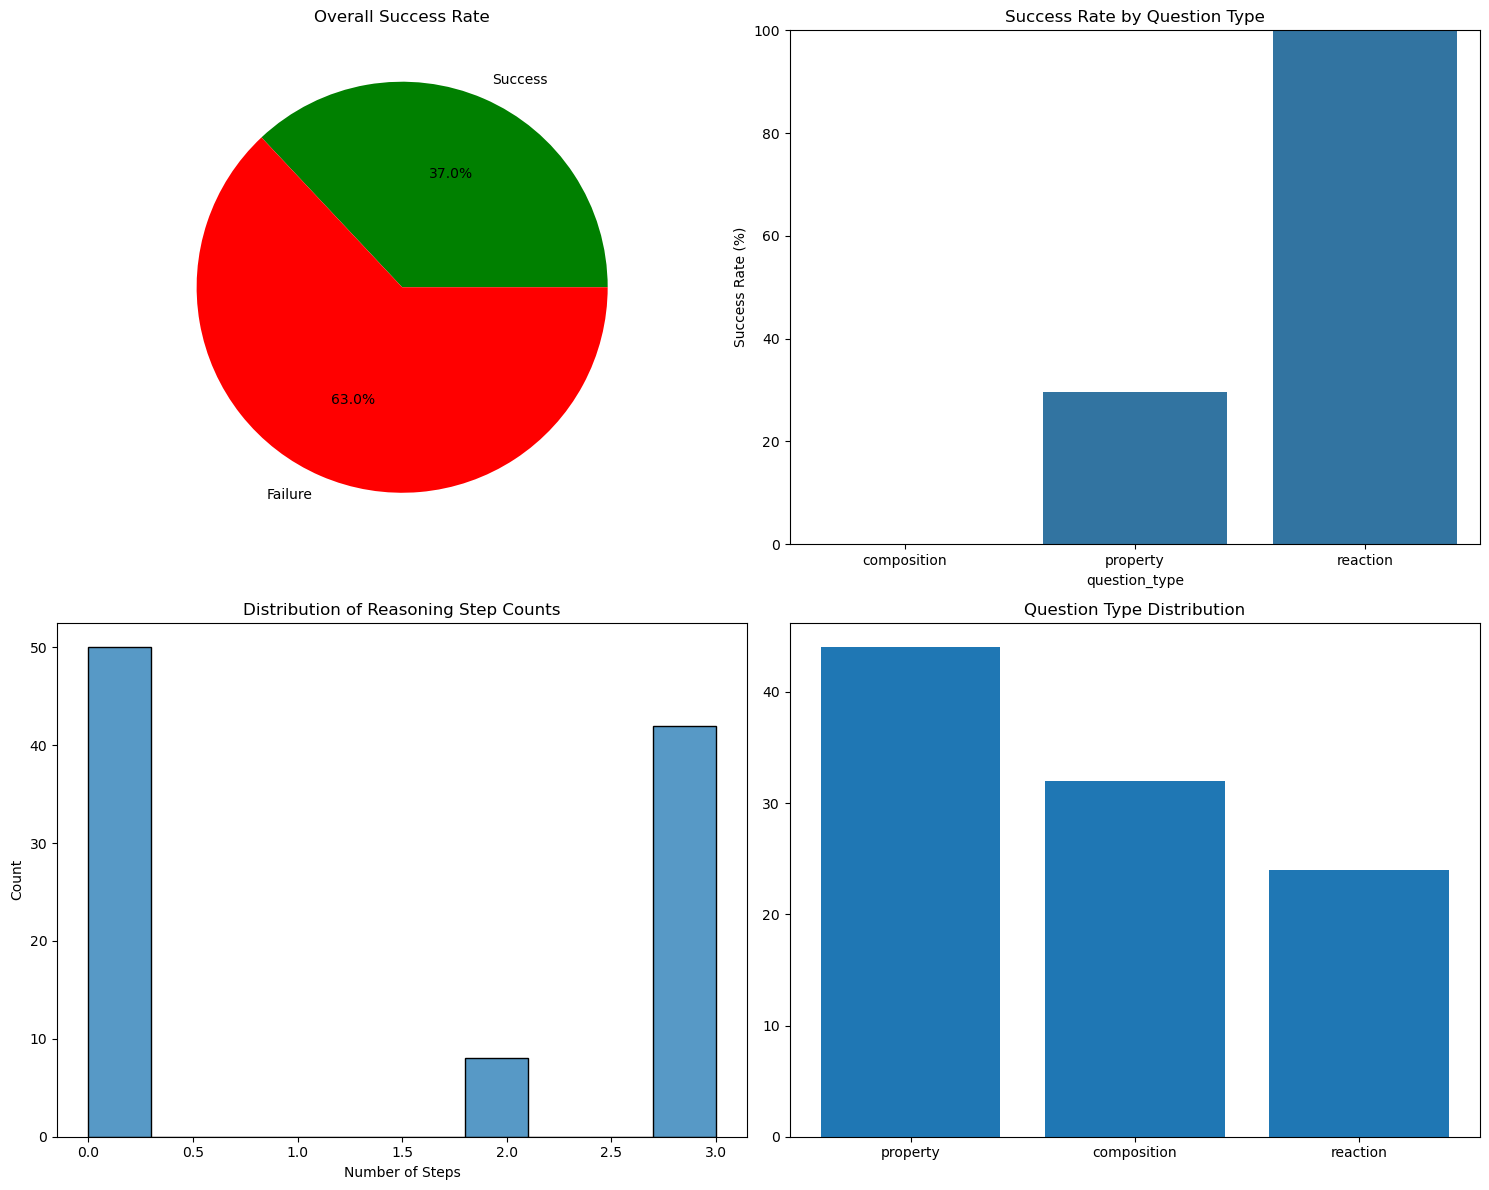


Example Successful Reasoning:
Question: What happens in the reaction between Sodium (Na) and Water (H2O)?
Expected Answer: Sodium Hydroxide (NaOH), Hydrogen (H) in an exothermic reaction and produces hydrogen gas
Reasoning Steps:
  Question: What happens in the reaction between Sodium (Na) and Water (H2O)?
  Step 1: Identify the reactants: Sodium (Na) and Water (H2O)
  Step 2: Find products of the reaction
  Found products: Sodium Hydroxide (NaOH), Hydrogen (H)
  Step 3: Applying chemistry rules
  Applied rule: The reaction between sodium and water is highly exothermic (releases heat)
  Applied rule: The reaction produces hydrogen gas, which can be observed as bubbles
  Conclusion: Sodium Hydroxide (NaOH), Hydrogen (H) in an exothermic reaction and produces hydrogen gas

Example Failed Reasoning:
Question: Which elements are moderately reactive elements?
Expected Answer: Calcium (Ca), Carbon (C), Hydrogen (H)
Reasoning Steps:
  Question: Which elements are moderately reactive elements

In [6]:
# Example usage
reasoner = create_chemistry_ontology()
validation_report = run_validation(reasoner, n_questions=100)

===== CHEMISTRY ONTOLOGY REASONING SYSTEM =====

1. Creating chemistry ontology...

2. Running individual reasoning examples...

=== CHEMISTRY REASONING EXAMPLES ===

 EXAMPLE 1: Property-based Query
Question: Which elements are metals with high reactivity?
Step 1: Identify elements that are metals
Step 2: Found elements with this property: Sodium (Na), Potassium (K), Calcium (Ca), Iron (Fe), Gold (Au)
Step 3: Verify that the answer is complete and correct
Conclusion: Sodium (Na), Potassium (K)

 EXAMPLE 2: Reaction Analysis Query
Question: What happens in the reaction between Sodium (Na) and Water (H2O)?
Step 1: Identify the reactants: Sodium (Na) and Water (H2O)
Step 2: Find products of the reaction
Found products: Sodium Hydroxide (NaOH), Hydrogen (H)
Step 3: Applying chemistry rules
Applied rule: The reaction between sodium and water is highly exothermic (releases heat)
Applied rule: The reaction produces hydrogen gas, which can be observed as bubbles
Conclusion: Sodium hydroxide (

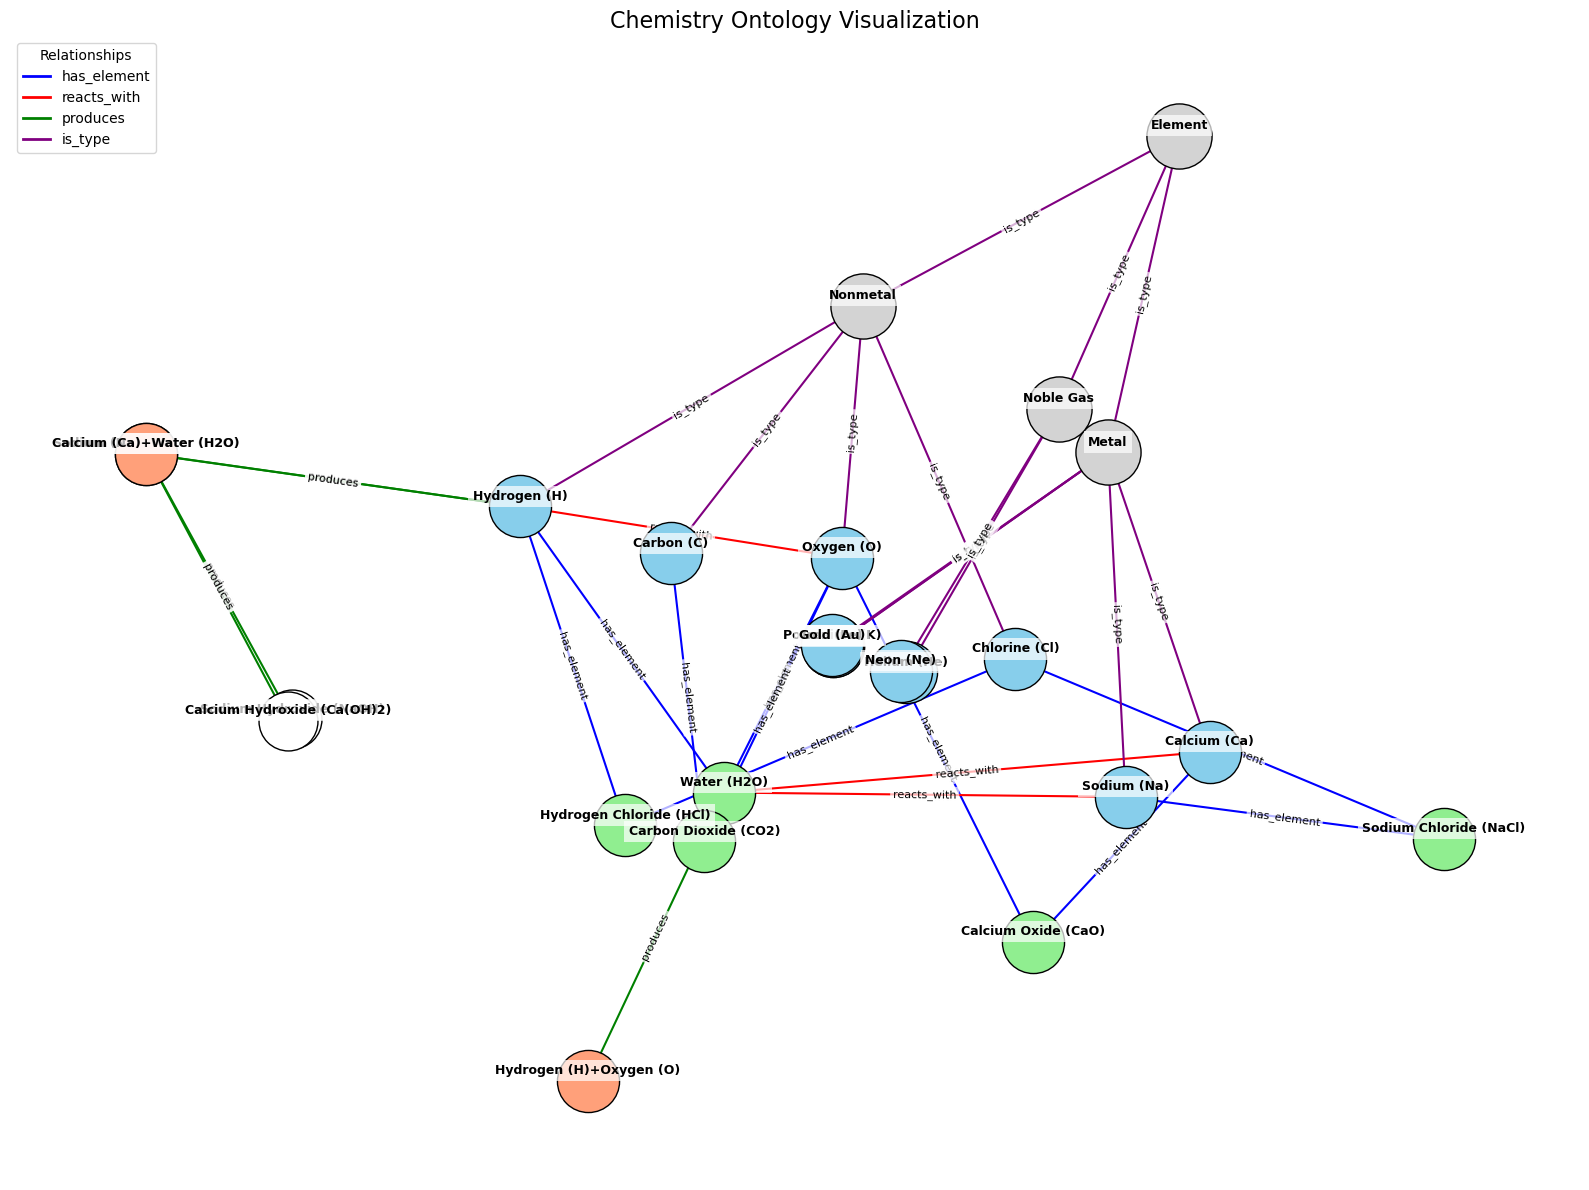


3. Running validation on 100 generated questions...
Generating 100 synthetic chemistry questions...
Validating questions against the ontology reasoner...


Validating questions: 100%|██████████| 100/100 [00:00<00:00, 128778.14it/s]

Generating validation report...

=== VALIDATION REPORT ===
Total Questions: 100
Overall Success Rate: 52.00%
Average Reasoning Steps: 1.74

Success Rate by Question Type:
               Successful  Total  Success Rate (%)
question_type                                     
composition             0     28          0.000000
property               11     31         35.483871
reaction               41     41        100.000000

Visualizing results...


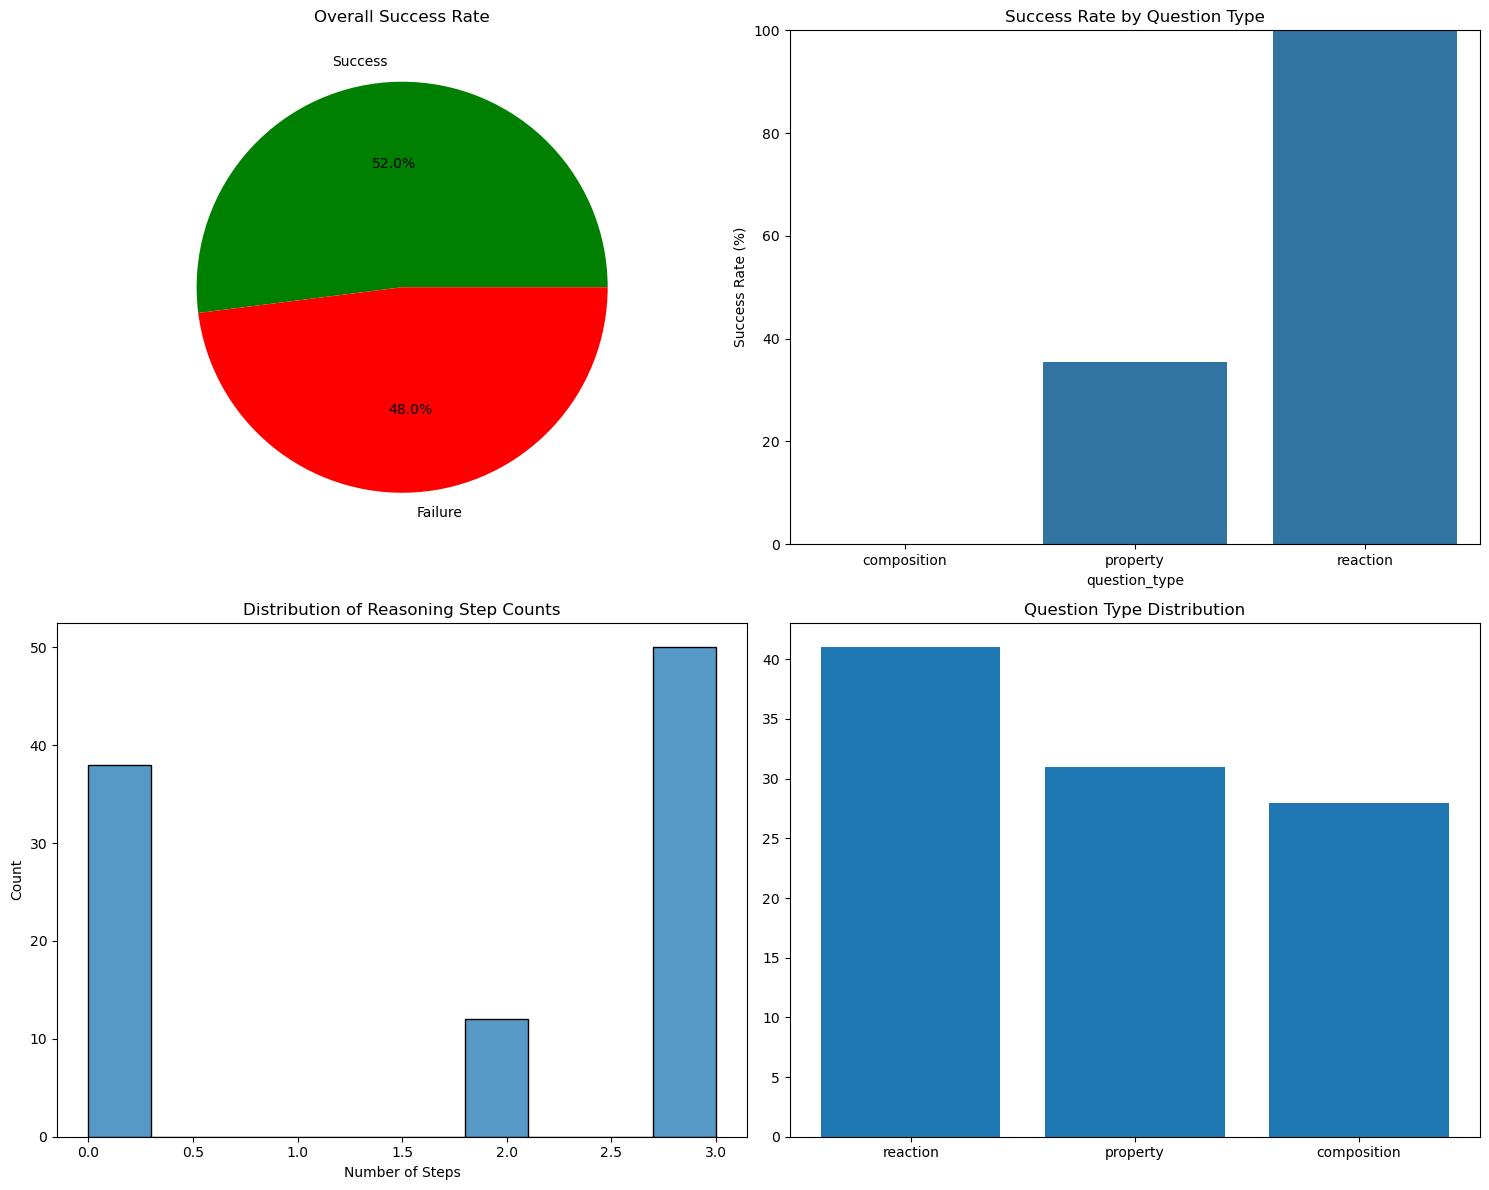


Example Successful Reasoning:
Question: What happens in the reaction between Sodium (Na) and Water (H2O)?
Expected Answer: Sodium Hydroxide (NaOH), Hydrogen (H) in an exothermic reaction and produces hydrogen gas
Reasoning Steps:
  Question: What happens in the reaction between Sodium (Na) and Water (H2O)?
  Step 1: Identify the reactants: Sodium (Na) and Water (H2O)
  Step 2: Find products of the reaction
  Found products: Sodium Hydroxide (NaOH), Hydrogen (H)
  Step 3: Applying chemistry rules
  Applied rule: The reaction between sodium and water is highly exothermic (releases heat)
  Applied rule: The reaction produces hydrogen gas, which can be observed as bubbles
  Conclusion: Sodium Hydroxide (NaOH), Hydrogen (H) in an exothermic reaction and produces hydrogen gas

Example Failed Reasoning:
Question: Which elements are elements with very low reactivity?
Expected Answer: Gold (Au), Helium (He), Neon (Ne)
Reasoning Steps:
  Question: Which elements are elements with very low react

In [11]:
# main.py
# Main script that integrates the ontology reasoner with the validation system

# Import the ontology reasoner module (assuming the module is named ontology_reasoner.py)

def main():
    print("===== CHEMISTRY ONTOLOGY REASONING SYSTEM =====")
    print("\n1. Creating chemistry ontology...")
    reasoner = create_chemistry_ontology()
    
    print("\n2. Running individual reasoning examples...")
    demonstrate_chemistry_reasoning()
    
    print("\n3. Running validation on 100 generated questions...")
    n_questions = 100  # Change this to validate more or fewer questions
    validation_report = run_validation(reasoner, n_questions=n_questions)
    
    print("\nValidation complete!")
    
if __name__ == "__main__":
    main()

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Set
import re

class ImprovedOntologyReasoner:
    def __init__(self):
        # Initialize the ontology as a directed graph
        self.ontology = nx.DiGraph()
        
        # Store rules as (condition, consequence, description) triples
        self.rules = []
        
        # Track relationships between entities
        self.relationships = {}
        
    def add_concept(self, concept: str, properties: Dict = None):
        """Add a concept to the ontology with optional properties"""
        if properties is None:
            properties = {}
        self.ontology.add_node(concept, **properties)
    
    def add_relationship(self, source: str, target: str, relation_type: str):
        """Add a relationship between two concepts"""
        self.ontology.add_edge(source, target, relation=relation_type)
        
        # Store the relationship for easier access
        if relation_type not in self.relationships:
            self.relationships[relation_type] = []
        self.relationships[relation_type].append((source, target))
    
    def add_rule(self, condition: str, consequence: str, description: str = None):
        """Add a rule to the ontology with optional description"""
        self.rules.append((condition, consequence, description))
    
    def get_related_concepts(self, concept: str, relation_type: str) -> List[str]:
        """Get all concepts related to a given concept by a specific relation type"""
        related = []
        for source, target, data in self.ontology.edges(data=True):
            if source == concept and data['relation'] == relation_type:
                related.append(target)
        return related
    
    def get_concepts_by_relation(self, relation_type: str) -> List[Tuple[str, str]]:
        """Get all concept pairs connected by a specific relation type"""
        return [(source, target) for source, target, data in self.ontology.edges(data=True) 
                if data['relation'] == relation_type]
    
    def get_concepts_with_property(self, property_name: str, property_value=None) -> List[str]:
        """Get all concepts with a specific property"""
        concepts = []
        for node, properties in self.ontology.nodes(data=True):
            if property_name in properties:
                if property_value is None or properties[property_name] == property_value:
                    concepts.append(node)
        return concepts
    
    def apply_rules(self, facts: Set[str]) -> Tuple[Set[str], List[str]]:
        """Apply rules to derive new facts and return reasoning steps"""
        new_facts = facts.copy()
        reasoning_steps = []
        
        for condition, consequence, description in self.rules:
            if condition in new_facts and consequence not in new_facts:
                new_facts.add(consequence)
                if description:
                    reasoning_steps.append(f"Applied rule: {description}")
                else:
                    reasoning_steps.append(f"From '{condition}', derived '{consequence}'")
                    
        return new_facts, reasoning_steps
    
    def _parse_elements_question(self, question: str) -> Dict:
        """Parse questions about element properties"""
        parsed = {}
        
        # Check for metal questions
        if "metal" in question.lower():
            parsed["property"] = "is_metal"
            parsed["value"] = True
        
        # Check for non-metal questions
        if "non-metal" in question.lower() or "nonmetal" in question.lower():
            parsed["property"] = "is_metal"
            parsed["value"] = False
        
        # Check for reactivity questions
        reactivity_patterns = {
            r"high(?:ly)?\s+reactiv": "high",
            r"medium\s+reactiv|moderate(?:ly)?\s+reactiv": "medium",
            r"low\s+reactiv": "low",
            r"very\s+low\s+reactiv|least\s+reactiv": "very_low"
        }
        
        for pattern, value in reactivity_patterns.items():
            if re.search(pattern, question.lower()):
                parsed["property"] = "reactivity"
                parsed["value"] = value
        
        return parsed
    
    def _parse_reaction_question(self, question: str) -> Dict:
        """Parse questions about chemical reactions"""
        parsed = {}
        
        # Find reactants in questions about reactions
        reaction_pattern = r"reaction between ([A-Za-z\s()]+) and ([A-Za-z\s()]+)"
        match = re.search(reaction_pattern, question)
        
        if match:
            parsed["reactant1"] = match.group(1).strip()
            parsed["reactant2"] = match.group(2).strip().rstrip('?')
        
        return parsed
    
    def _parse_composition_question(self, question: str) -> Dict:
        """Parse questions about compound composition"""
        parsed = {}
        
        # Find compound in composition questions
        composition_pattern = r"elements (?:that )?make up ([A-Za-z\s()0-9]+)"
        match = re.search(composition_pattern, question)
        
        if match:
            parsed["compound"] = match.group(1).strip().rstrip('?')
        
        return parsed
    
    def reason(self, question: str, answer: str) -> List[str]:
        """Generate reasoning steps from a question to an answer"""
        reasoning_steps = ["Question: " + question]
        
        # Property-based questions about elements
        if "which elements" in question.lower() or "what elements" in question.lower():
            parsed = self._parse_elements_question(question)
            
            if parsed and "property" in parsed:
                property_name = parsed["property"]
                property_value = parsed["value"]
                
                if property_name == "is_metal":
                    metal_type = "metals" if property_value else "non-metals"
                    reasoning_steps.append(f"Step 1: Identify elements that are {metal_type}")
                elif property_name == "reactivity":
                    reasoning_steps.append(f"Step 1: Identify elements with {property_value} reactivity")
                
                # Find matching elements
                matching_elements = self.get_concepts_with_property(property_name, property_value)
                
                if matching_elements:
                    reasoning_steps.append(f"Step 2: Found elements with this property: {', '.join(matching_elements)}")
                    
                    # Verify against answer
                    expected_elements = [e.strip() for e in answer.split(',')]
                    
                    # More lenient matching - check if the expected elements are a subset
                    found_all = all(any(expected in actual for actual in matching_elements) for expected in expected_elements)
                    
                    if found_all:
                        reasoning_steps.append(f"Step 3: Verify that the answer is complete and correct")
                        reasoning_steps.append(f"Conclusion: {answer}")
                    else:
                        reasoning_steps.append(f"Step 3: The derived answer doesn't match the expected answer")
                        reasoning_steps.append(f"Expected: {answer}")
                        reasoning_steps.append(f"Derived: {', '.join(matching_elements)}")
                else:
                    reasoning_steps.append("Step 2: No elements found with the specified property")
        
        # Reaction questions
        elif "reaction between" in question.lower() or "what happens when" in question.lower():
            parsed = self._parse_reaction_question(question)
            
            if parsed and "reactant1" in parsed and "reactant2" in parsed:
                reactant1 = parsed["reactant1"]
                reactant2 = parsed["reactant2"]
                
                reasoning_steps.append(f"Step 1: Identify the reactants: {reactant1} and {reactant2}")
                
                # Look for exact matches first
                products = []
                reaction_found = False
                
                # Try direct lookup
                for source, target, data in self.ontology.edges(data=True):
                    if data['relation'] == "reacts_with" and source == reactant1 and target == reactant2:
                        products = self.get_related_concepts(f"{reactant1}+{reactant2}", "produces")
                        reaction_found = True
                
                # Try fuzzy matching if direct lookup fails
                if not reaction_found:
                    for source, target, data in self.ontology.edges(data=True):
                        if data['relation'] == "reacts_with":
                            if (reactant1 in source and reactant2 in target) or (reactant2 in source and reactant1 in target):
                                possible_reaction = f"{source}+{target}"
                                possible_products = self.get_related_concepts(possible_reaction, "produces")
                                if possible_products:
                                    products = possible_products
                                    reaction_found = True
                                    reasoning_steps.append(f"Note: Using closest match for reactants: {source} and {target}")
                
                if reaction_found and products:
                    reasoning_steps.append(f"Step 2: Find products of the reaction")
                    reasoning_steps.append(f"Found products: {', '.join(products)}")
                    
                    # Apply rules for additional information
                    reaction_key = f"reaction:{reactant1}+{reactant2}"
                    facts = set([reaction_key])
                    derived_facts, rule_steps = self.apply_rules(facts)
                    
                    if rule_steps:
                        reasoning_steps.append("Step 3: Applying chemistry rules")
                        reasoning_steps.extend(rule_steps)
                    
                    reasoning_steps.append(f"Conclusion: {answer}")
                else:
                    reasoning_steps.append("Step 2: No reaction found in the ontology for these reactants")
            else:
                reasoning_steps.append("Step 1: Could not identify reactants from the question")
        
        # Composition questions
        elif "elements" in question.lower() and ("make up" in question.lower() or "composition" in question.lower() or "in " in question.lower()):
            parsed = self._parse_composition_question(question)
            
            if parsed and "compound" in parsed:
                compound = parsed["compound"]
                
                reasoning_steps.append(f"Step 1: Identify the compound: {compound}")
                
                # Try direct lookup
                elements = self.get_related_concepts(compound, "has_element")
                
                # Try fuzzy matching if direct lookup fails
                if not elements:
                    for node in self.ontology.nodes():
                        if compound in node and self.ontology.nodes[node].get('is_compound', False):
                            elements = self.get_related_concepts(node, "has_element")
                            if elements:
                                reasoning_steps.append(f"Note: Using closest match for compound: {node}")
                                break
                
                if elements:
                    reasoning_steps.append(f"Step 2: Find elements in the compound")
                    reasoning_steps.append(f"Found elements: {', '.join(elements)}")
                    
                    # Verify against answer
                    expected_elements = [e.strip() for e in answer.split(',')]
                    
                    # More lenient matching - check if the expected elements are a subset
                    found_all = all(any(expected in actual for actual in elements) for expected in expected_elements)
                    
                    if found_all:
                        reasoning_steps.append(f"Step 3: Verify that the answer is complete and correct")
                        reasoning_steps.append(f"Conclusion: {answer}")
                    else:
                        reasoning_steps.append(f"Step 3: The derived answer doesn't match the expected answer")
                        reasoning_steps.append(f"Expected: {answer}")
                        reasoning_steps.append(f"Derived: {', '.join(elements)}")
                else:
                    reasoning_steps.append(f"Step 2: No elements found for compound {compound}")
            else:
                reasoning_steps.append("Step 1: Could not identify compound from the question")
        
        # Fallback for other questions
        else:
            reasoning_steps.append("This question type is not currently supported by the reasoner")
        
        return reasoning_steps
    
    def visualize(self):
        """Visualize the ontology with improved readability"""
        plt.figure(figsize=(16, 12))
        
        # Create position layout with more spacing
        pos = nx.kamada_kawai_layout(self.ontology)  # Better for dense graphs
        
        # Draw nodes with different colors based on type
        element_nodes = [node for node in self.ontology.nodes() if self.ontology.nodes[node].get('is_element', False)]
        compound_nodes = [node for node in self.ontology.nodes() if self.ontology.nodes[node].get('is_compound', False)]
        reaction_nodes = [node for node in self.ontology.nodes() if "+" in node]
        category_nodes = ["Element", "Metal", "Nonmetal", "Noble Gas"]
        other_nodes = [node for node in self.ontology.nodes() if (node not in element_nodes and 
                                                                 node not in compound_nodes and 
                                                                 node not in reaction_nodes and
                                                                 node not in category_nodes)]
        
        # Draw different node types
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=element_nodes, node_size=2000, 
                              node_color="skyblue", label="Elements", edgecolors='black')
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=compound_nodes, node_size=2000, 
                              node_color="lightgreen", label="Compounds", edgecolors='black')
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=reaction_nodes, node_size=2000, 
                              node_color="lightsalmon", label="Reactions", edgecolors='black')
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=category_nodes, node_size=2200, 
                              node_color="lightgray", label="Categories", edgecolors='black')
        nx.draw_networkx_nodes(self.ontology, pos, nodelist=other_nodes, node_size=1800, 
                              node_color="white", label="Other", edgecolors='black')
        
        # Draw edges with different colors and add edge labels
        relation_colors = {
            'has_element': 'blue',
            'reacts_with': 'red',
            'produces': 'green', 
            'is_type': 'purple'
        }
        
        # Create separate edge lists for drawing
        all_edges = []
        edge_colors = []
        
        # Draw edge labels separately for better visibility
        edge_labels = {}
        
        for relation, color in relation_colors.items():
            edges = [(s, t) for s, t, d in self.ontology.edges(data=True) if d['relation'] == relation]
            
            if edges:
                # Add edges to the master list
                all_edges.extend(edges)
                edge_colors.extend([color] * len(edges))
                
                # Create edge labels
                for s, t in edges:
                    edge_labels[(s, t)] = relation
        
        # Draw all edges at once
        nx.draw_networkx_edges(self.ontology, pos, edgelist=all_edges, 
                              edge_color=edge_colors, width=1.5, arrows=True, 
                              arrowsize=15, arrowstyle='->')
        
        # Draw edge labels with background
        nx.draw_networkx_edge_labels(self.ontology, pos, edge_labels=edge_labels, 
                                    font_size=8, font_color='black',
                                    bbox=dict(facecolor='white', edgecolor='none', 
                                             alpha=0.7, pad=2))
        
        # Draw node labels more clearly
        label_pos = {k: (v[0], v[1] + 0.02) for k, v in pos.items()}  # Adjust label positions
        nx.draw_networkx_labels(self.ontology, label_pos, font_size=9, font_weight='bold',
                              bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=3))
        
        # Create custom legend for edge types
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='blue', lw=2, label='has_element'),
            Line2D([0], [0], color='red', lw=2, label='reacts_with'),
            Line2D([0], [0], color='green', lw=2, label='produces'),
            Line2D([0], [0], color='purple', lw=2, label='is_type')
        ]
        
        # Add a title and legend
        plt.title("Chemistry Ontology Visualization", fontsize=16)
        plt.legend(handles=legend_elements, loc='upper left', title="Relationships")
        
        plt.axis('off')
        plt.tight_layout()
        plt.show()


# Create an improved chemistry ontology
def create_improved_chemistry_ontology():
    reasoner = ImprovedOntologyReasoner()
    
    # Add element categories
    reasoner.add_concept("Element")
    reasoner.add_concept("Metal")
    reasoner.add_concept("Nonmetal")
    reasoner.add_concept("Noble Gas")
    
    # Add relationships for categories
    reasoner.add_relationship("Metal", "Element", "is_type")
    reasoner.add_relationship("Nonmetal", "Element", "is_type")
    reasoner.add_relationship("Noble Gas", "Element", "is_type")
    
    # Add elements with properties
    # Metals
    reasoner.add_concept("Sodium (Na)", {"is_element": True, "is_metal": True, "reactivity": "high", "atomic_number": 11})
    reasoner.add_concept("Potassium (K)", {"is_element": True, "is_metal": True, "reactivity": "high", "atomic_number": 19})
    reasoner.add_concept("Calcium (Ca)", {"is_element": True, "is_metal": True, "reactivity": "medium", "atomic_number": 20})
    reasoner.add_concept("Iron (Fe)", {"is_element": True, "is_metal": True, "reactivity": "low", "atomic_number": 26})
    reasoner.add_concept("Gold (Au)", {"is_element": True, "is_metal": True, "reactivity": "very_low", "atomic_number": 79})
    reasoner.add_concept("Copper (Cu)", {"is_element": True, "is_metal": True, "reactivity": "low", "atomic_number": 29})
    reasoner.add_concept("Aluminum (Al)", {"is_element": True, "is_metal": True, "reactivity": "medium", "atomic_number": 13})
    reasoner.add_concept("Magnesium (Mg)", {"is_element": True, "is_metal": True, "reactivity": "medium", "atomic_number": 12})
    
    # Nonmetals
    reasoner.add_concept("Oxygen (O)", {"is_element": True, "is_metal": False, "reactivity": "high", "atomic_number": 8})
    reasoner.add_concept("Chlorine (Cl)", {"is_element": True, "is_metal": False, "reactivity": "high", "atomic_number": 17})
    reasoner.add_concept("Carbon (C)", {"is_element": True, "is_metal": False, "reactivity": "medium", "atomic_number": 6})
    reasoner.add_concept("Hydrogen (H)", {"is_element": True, "is_metal": False, "reactivity": "medium", "atomic_number": 1})
    reasoner.add_concept("Nitrogen (N)", {"is_element": True, "is_metal": False, "reactivity": "medium", "atomic_number": 7})
    reasoner.add_concept("Phosphorus (P)", {"is_element": True, "is_metal": False, "reactivity": "medium", "atomic_number": 15})
    reasoner.add_concept("Sulfur (S)", {"is_element": True, "is_metal": False, "reactivity": "medium", "atomic_number": 16})
    
    # Noble gases
    reasoner.add_concept("Helium (He)", {"is_element": True, "is_metal": False, "reactivity": "very_low", "atomic_number": 2})
    reasoner.add_concept("Neon (Ne)", {"is_element": True, "is_metal": False, "reactivity": "very_low", "atomic_number": 10})
    reasoner.add_concept("Argon (Ar)", {"is_element": True, "is_metal": False, "reactivity": "very_low", "atomic_number": 18})
    
    # Add element type relationships
    reasoner.add_relationship("Sodium (Na)", "Metal", "is_type")
    reasoner.add_relationship("Potassium (K)", "Metal", "is_type")
    reasoner.add_relationship("Calcium (Ca)", "Metal", "is_type")
    reasoner.add_relationship("Iron (Fe)", "Metal", "is_type")
    reasoner.add_relationship("Gold (Au)", "Metal", "is_type")
    reasoner.add_relationship("Copper (Cu)", "Metal", "is_type")
    reasoner.add_relationship("Aluminum (Al)", "Metal", "is_type")
    reasoner.add_relationship("Magnesium (Mg)", "Metal", "is_type")
    
    reasoner.add_relationship("Oxygen (O)", "Nonmetal", "is_type")
    reasoner.add_relationship("Chlorine (Cl)", "Nonmetal", "is_type")
    reasoner.add_relationship("Carbon (C)", "Nonmetal", "is_type")
    reasoner.add_relationship("Hydrogen (H)", "Nonmetal", "is_type")
    reasoner.add_relationship("Nitrogen (N)", "Nonmetal", "is_type")
    reasoner.add_relationship("Phosphorus (P)", "Nonmetal", "is_type")
    reasoner.add_relationship("Sulfur (S)", "Nonmetal", "is_type")
    
    reasoner.add_relationship("Helium (He)", "Noble Gas", "is_type")
    reasoner.add_relationship("Neon (Ne)", "Noble Gas", "is_type")
    reasoner.add_relationship("Argon (Ar)", "Noble Gas", "is_type")
    
    # Add compounds
    reasoner.add_concept("Water (H2O)", {"is_compound": True, "state": "liquid"})
    reasoner.add_concept("Sodium Chloride (NaCl)", {"is_compound": True, "state": "solid"})
    reasoner.add_concept("Calcium Oxide (CaO)", {"is_compound": True, "state": "solid"})
    reasoner.add_concept("Carbon Dioxide (CO2)", {"is_compound": True, "state": "gas"})
    reasoner.add_concept("Hydrogen Chloride (HCl)", {"is_compound": True, "state": "gas"})
    reasoner.add_concept("Sodium Hydroxide (NaOH)", {"is_compound": True, "state": "solid"})
    reasoner.add_concept("Calcium Hydroxide (Ca(OH)2)", {"is_compound": True, "state": "solid"})
    reasoner.add_concept("Methane (CH4)", {"is_compound": True, "state": "gas"})
    reasoner.add_concept("Ammonia (NH3)", {"is_compound": True, "state": "gas"})
    reasoner.add_concept("Sulfuric Acid (H2SO4)", {"is_compound": True, "state": "liquid"})
    
    # Add compound composition
    reasoner.add_relationship("Water (H2O)", "Hydrogen (H)", "has_element")
    reasoner.add_relationship("Water (H2O)", "Oxygen (O)", "has_element")
    
    reasoner.add_relationship("Sodium Chloride (NaCl)", "Sodium (Na)", "has_element")
    reasoner.add_relationship("Sodium Chloride (NaCl)", "Chlorine (Cl)", "has_element")
    
    reasoner.add_relationship("Calcium Oxide (CaO)", "Calcium (Ca)", "has_element")
    reasoner.add_relationship("Calcium Oxide (CaO)", "Oxygen (O)", "has_element")
    
    reasoner.add_relationship("Carbon Dioxide (CO2)", "Carbon (C)", "has_element")
    reasoner.add_relationship("Carbon Dioxide (CO2)", "Oxygen (O)", "has_element")
    
    reasoner.add_relationship("Hydrogen Chloride (HCl)", "Hydrogen (H)", "has_element")
    reasoner.add_relationship("Hydrogen Chloride (HCl)", "Chlorine (Cl)", "has_element")
    
    reasoner.add_relationship("Sodium Hydroxide (NaOH)", "Sodium (Na)", "has_element")
    reasoner.add_relationship("Sodium Hydroxide (NaOH)", "Oxygen (O)", "has_element")
    reasoner.add_relationship("Sodium Hydroxide (NaOH)", "Hydrogen (H)", "has_element")
    
    reasoner.add_relationship("Calcium Hydroxide (Ca(OH)2)", "Calcium (Ca)", "has_element")
    reasoner.add_relationship("Calcium Hydroxide (Ca(OH)2)", "Oxygen (O)", "has_element")
    reasoner.add_relationship("Calcium Hydroxide (Ca(OH)2)", "Hydrogen (H)", "has_element")
    
    reasoner.add_relationship("Methane (CH4)", "Carbon (C)", "has_element")
    reasoner.add_relationship("Methane (CH4)", "Hydrogen (H)", "has_element")
    
    reasoner.add_relationship("Ammonia (NH3)", "Nitrogen (N)", "has_element")
    reasoner.add_relationship("Ammonia (NH3)", "Hydrogen (H)", "has_element")
    
    reasoner.add_relationship("Sulfuric Acid (H2SO4)", "Hydrogen (H)", "has_element")
    reasoner.add_relationship("Sulfuric Acid (H2SO4)", "Sulfur (S)", "has_element")
    reasoner.add_relationship("Sulfuric Acid (H2SO4)", "Oxygen (O)", "has_element")
    
    # Add reactions
    # Sodium and water
    reasoner.add_concept("Sodium (Na)+Water (H2O)")
    reasoner.add_relationship("Sodium (Na)", "Water (H2O)", "reacts_with")
    reasoner.add_relationship("Sodium (Na)+Water (H2O)", "Sodium Hydroxide (NaOH)", "produces")
    reasoner.add_relationship("Sodium (Na)+Water (H2O)", "Hydrogen (H)", "produces")
    
    # Calcium and water
    reasoner.add_concept("Calcium (Ca)+Water (H2O)")
    reasoner.add_relationship("Calcium (Ca)", "Water (H2O)", "reacts_with")
    reasoner.add_relationship("Calcium (Ca)+Water (H2O)", "Calcium Hydroxide (Ca(OH)2)", "produces")
    reasoner.add_relationship("Calcium (Ca)+Water (H2O)", "Hydrogen (H)", "produces")
    
    # Hydrogen and oxygen
    reasoner.add_concept("Hydrogen (H)+Oxygen (O)")
    reasoner.add_relationship("Hydrogen (H)", "Oxygen (O)", "reacts_with")
    reasoner.add_relationship("Hydrogen (H)+Oxygen (O)", "Water (H2O)", "produces")
    
    # Hydrogen chloride and water
    reasoner.add_concept("Hydrogen Chloride (HCl)+Water (H2O)")
    reasoner.add_relationship("Hydrogen Chloride (HCl)", "Water (H2O)", "reacts_with")
    reasoner.add_relationship("Hydrogen Chloride (HCl)+Water (H2O)", "Hydrochloric Acid", "produces")
    
    # Magnesium and oxygen
    reasoner.add_concept("Magnesium (Mg)+Oxygen (O)")
    reasoner.add_relationship("Magnesium (Mg)", "Oxygen (O)", "reacts_with")
    reasoner.add_relationship("Magnesium (Mg)+Oxygen (O)", "Magnesium Oxide (MgO)", "produces")
    
    # Carbon and oxygen
    reasoner.add_concept("Carbon (C)+Oxygen (O)")
    reasoner.add_relationship("Carbon (C)", "Oxygen (O)", "reacts_with")
    reasoner.add_relationship("Carbon (C)+Oxygen (O)", "Carbon Dioxide (CO2)", "produces")
    
    # Add rules
    reasoner.add_rule("reaction:Sodium (Na)+Water (H2O)", 
                     "exothermic", 
                     "The reaction between sodium and water is highly exothermic (releases heat)")
    
    reasoner.add_rule("reaction:Sodium (Na)+Water (H2O)", 
                     "hydrogen_gas", 
                     "The reaction produces hydrogen gas, which can be observed as bubbles")
    
    reasoner.add_rule("reaction:Calcium (Ca)+Water (H2O)", 
                     "less_exothermic", 
                     "The reaction between calcium and water is less violent than sodium and water")
    
    reasoner.add_rule("reaction:Hydrogen (H)+Oxygen (O)",
                     "explosive",
                     "The reaction between hydrogen and oxygen can be explosive in the right conditions")
    
    reasoner.add_rule("reaction:Carbon (C)+Oxygen (O)",
                     "combustion",
                     "This is a combustion reaction that releases energy as heat")
    
    return reasoner

def demonstrate_improved_reasoning():
    # Create ontology
    reasoner = create_improved_chemistry_ontology()
    
    # Example questions to test
    test_questions = [
        {
            "question": "Which elements are metals with high reactivity?",
            "answer": "Sodium (Na), Potassium (K)"
        },
        {
            "question": "What happens in the reaction between Sodium and Water?",
            "answer": "Sodium hydroxide (NaOH) and hydrogen gas are produced in an exothermic reaction"
        },
        {
            "question": "What elements make up Water (H2O)?",
            "answer": "Hydrogen (H), Oxygen (O)"
        },
        {
            "question": "Which elements are non-metals?",
            "answer": "Oxygen (O), Chlorine (Cl), Carbon (C), Hydrogen (H), Nitrogen (N), Phosphorus (P), Sulfur (S), Helium (He), Neon (Ne), Argon (Ar)"
        },
        {
            "question": "What happens when Carbon reacts with Oxygen?",
            "answer": "Carbon Dioxide (CO2) is produced in a combustion reaction"
        }
    ]
    
    # Test each question
    for i, test in enumerate(test_questions):
        print(f"\n--- Test Question {i+1} ---")
        print(f"Q: {test['question']}")
        print(f"Expected A: {test['answer']}")
        
        # Generate reasoning steps
        steps = reasoner.reason(test["question"], test["answer"])
        
        print("\nReasoning Steps:")
        for step in steps:
            print(f"  {step}")
        
        # Check if reasoning was successful
        success = any("Conclusion" in step for step in steps)
        print(f"\nSuccess: {'Yes' if success else 'No'}")
    
    return reasoner

if __name__ == "__main__":
    demonstrate_improved_reasoning()


--- Test Question 1 ---
Q: Which elements are metals with high reactivity?
Expected A: Sodium (Na), Potassium (K)

Reasoning Steps:
  Question: Which elements are metals with high reactivity?
  Step 1: Identify elements with high reactivity
  Step 2: Found elements with this property: Sodium (Na), Potassium (K), Oxygen (O), Chlorine (Cl)
  Step 3: Verify that the answer is complete and correct
  Conclusion: Sodium (Na), Potassium (K)

Success: Yes

--- Test Question 2 ---
Q: What happens in the reaction between Sodium and Water?
Expected A: Sodium hydroxide (NaOH) and hydrogen gas are produced in an exothermic reaction

Reasoning Steps:
  Question: What happens in the reaction between Sodium and Water?
  Step 1: Identify the reactants: Sodium and Water
  Note: Using closest match for reactants: Sodium (Na) and Water (H2O)
  Step 2: Find products of the reaction
  Found products: Sodium Hydroxide (NaOH), Hydrogen (H)
  Conclusion: Sodium hydroxide (NaOH) and hydrogen gas are produced i

In [13]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
from tqdm import tqdm
import re

class ImprovedQuestionGenerator:
    """Generates synthetic chemistry questions for testing the ontology reasoner"""
    
    def __init__(self, reasoner):
        self.reasoner = reasoner
        self.elements = [node for node in self.reasoner.ontology.nodes() 
                         if self.reasoner.ontology.nodes[node].get('is_element', False)]
        self.compounds = [node for node in self.reasoner.ontology.nodes() 
                          if self.reasoner.ontology.nodes[node].get('is_compound', False)]
        
        # Create mappings for reactions
        self.reactions = {}
        for source, target, data in self.reasoner.ontology.edges(data=True):
            if data['relation'] == 'reacts_with':
                reaction_key = f"{source}+{target}"
                products = self.reasoner.get_related_concepts(reaction_key, "produces")
                if products:
                    self.reactions[(source, target)] = products
    
    def generate_property_question(self):
        """Generate a question about element properties"""
        property_types = [
            ("is_metal", True, "metals"),
            ("is_metal", False, "non-metals"),
            ("reactivity", "high", "highly reactive elements"),
            ("reactivity", "medium", "moderately reactive elements"),
            ("reactivity", "low", "elements with low reactivity"),
            ("reactivity", "very_low", "elements with very low reactivity")
        ]
        
        # Add some variations to the question phrasing
        question_templates = [
            "Which elements are {}?",
            "What elements are classified as {}?",
            "Which elements can be categorized as {}?",
            "What elements belong to the {} group?"
        ]
        
        prop_type, prop_value, prop_desc = random.choice(property_types)
        
        # Find elements with the given property
        matching_elements = []
        for elem in self.elements:
            elem_props = self.reasoner.ontology.nodes[elem]
            if prop_type in elem_props and elem_props[prop_type] == prop_value:
                matching_elements.append(elem)
        
        if not matching_elements:
            # Fallback if no elements match
            return self.generate_reaction_question()
        
        # Randomize how many elements to include in the answer
        if len(matching_elements) > 2:
            # Pick a random subset sometimes
            if random.random() < 0.3:
                num_elements = random.randint(2, min(len(matching_elements), 4))
                matching_elements = random.sample(matching_elements, num_elements)
        
        # Format the question
        question_template = random.choice(question_templates)
        question = question_template.format(prop_desc)
        answer = ", ".join(matching_elements)
        
        return {
            "question": question,
            "answer": answer,
            "type": "property",
            "property": prop_type,
            "value": prop_value
        }
    
    def generate_reaction_question(self):
        """Generate a question about chemical reactions"""
        if not self.reactions:
            return self.generate_composition_question()
            
        # Choose a random reaction
        reactants, products = random.choice(list(self.reactions.items()))
        reactant1, reactant2 = reactants
        
        # Get any rules for this reaction
        reaction_key = f"reaction:{reactant1}+{reactant2}"
        facts = set([reaction_key])
        derived_facts, _ = self.reasoner.apply_rules(facts)
        
        # Question templates for variety
        question_templates = [
            "What happens in the reaction between {} and {}?",
            "What is produced when {} reacts with {}?",
            "What happens when {} and {} are mixed?",
            "What is the result of a reaction between {} and {}?"
        ]
        
        # Format products and any additional information
        product_str = ", ".join(products)
        additional_info = []
        
        if "exothermic" in derived_facts:
            additional_info.append("an exothermic reaction")
        if "hydrogen_gas" in derived_facts:
            additional_info.append("produces hydrogen gas")
        if "combustion" in derived_facts:
            additional_info.append("a combustion reaction")
        if "explosive" in derived_facts:
            additional_info.append("potentially explosive")
        
        # Create the answer
        if additional_info:
            answer = f"{product_str} in {' and '.join(additional_info)}"
        else:
            answer = product_str
        
        # Format the question
        question_template = random.choice(question_templates)
        question = question_template.format(reactant1, reactant2)
        
        return {
            "question": question,
            "answer": answer,
            "type": "reaction",
            "reactants": [reactant1, reactant2],
            "products": products
        }
    
    def generate_composition_question(self):
        """Generate a question about compound composition"""
        if not self.compounds:
            return self.generate_property_question()
            
        compound = random.choice(self.compounds)
        elements = self.reasoner.get_related_concepts(compound, "has_element")
        
        if not elements:
            return self.generate_property_question()
        
        # Question templates for variety
        question_templates = [
            "What elements make up {}?",
            "What elements are in {}?",
            "What is the composition of {}?",
            "Which elements compose {}?"
        ]
        
        # Format the question
        question_template = random.choice(question_templates)
        question = question_template.format(compound)
        answer = ", ".join(elements)
        
        return {
            "question": question,
            "answer": answer,
            "type": "composition",
            "compound": compound
        }
    
    def generate_question(self):
        """Generate a random chemistry question"""
        # Weights for different question types
        weights = [0.4, 0.3, 0.3]  # property, reaction, composition
        
        question_types = [
            self.generate_property_question,
            self.generate_reaction_question,
            self.generate_composition_question
        ]
        
        # Select a question type based on weights
        generator = random.choices(question_types, weights=weights, k=1)[0]
        return generator()
    
    def generate_question_set(self, n=100):
        """Generate a set of n chemistry questions"""
        questions = []
        for _ in range(n):
            questions.append(self.generate_question())
        return questions


class ImprovedValidator:
    """Validates ontology reasoning against a set of questions with improved metrics"""
    
    def __init__(self, reasoner):
        self.reasoner = reasoner
    
    def normalize_answer(self, answer):
        """Normalize an answer string for comparison"""
        # Remove punctuation, standardize spacing, and convert to lowercase
        answer = re.sub(r'[^\w\s]', ' ', answer)
        answer = re.sub(r'\s+', ' ', answer).strip().lower()
        return answer
    
    def answer_similarity(self, expected, actual):
        """Calculate similarity between expected and derived answers"""
        # Normalize both answers
        expected_norm = self.normalize_answer(expected)
        actual_norm = self.normalize_answer(actual)
        
        # Split into words for token-based comparison
        expected_tokens = set(expected_norm.split())
        actual_tokens = set(actual_norm.split())
        
        # Calculate Jaccard similarity
        intersection = len(expected_tokens.intersection(actual_tokens))
        union = len(expected_tokens.union(actual_tokens))
        
        if union == 0:
            return 0
        
        return intersection / union
    
    def extract_derived_answer(self, steps):
        """Extract the derived answer from reasoning steps"""
        derived_answer = None
        
        # Look for a conclusion step
        for step in steps:
            if step.startswith("Conclusion:"):
                derived_answer = step[len("Conclusion:"):].strip()
                break
            elif "Derived:" in step:
                derived_answer = step.split("Derived:")[1].strip()
                break
        
        return derived_answer
    
    def validate_answer(self, question_dict):
        """Validate a single question-answer pair and return validation metrics"""
        question = question_dict["question"]
        expected_answer = question_dict["answer"]
        question_type = question_dict["type"]
        
        # Generate reasoning steps
        steps = self.reasoner.reason(question, expected_answer)
        
        # Determine if the reasoning was successful based on conclusive steps
        success = any("Conclusion" in step for step in steps)
        
        # Extract the derived answer for similarity calculation
        derived_answer = self.extract_derived_answer(steps)
        
        # Calculate answer similarity if we have a derived answer
        similarity = 0
        if derived_answer:
            similarity = self.answer_similarity(expected_answer, derived_answer)
        
        # Count reasoning steps
        step_count = len([s for s in steps if s.startswith("Step")])
        
        # Check for partial success (similarity > 0.5 but not full success)
        partial_success = False
        if not success and similarity > 0.5:
            partial_success = True
        
        return {
            "question": question,
            "expected_answer": expected_answer,
            "derived_answer": derived_answer,
            "steps": steps,
            "success": success,
            "partial_success": partial_success,
            "similarity": similarity,
            "step_count": step_count,
            "question_type": question_type
        }
    
    def batch_validate(self, question_set):
        """Run validation on a batch of questions"""
        results = []
        
        for q in tqdm(question_set, desc="Validating questions"):
            results.append(self.validate_answer(q))
            
        return results
    
    def generate_validation_report(self, results):
        """Generate a comprehensive validation report"""
        # Convert to DataFrame for easier analysis
        df = pd.DataFrame(results)
        
        # Calculate overall statistics
        total_questions = len(df)
        successful = df['success'].sum()
        partial_successful = df['partial_success'].sum()
        success_rate = successful / total_questions * 100
        partial_success_rate = partial_successful / total_questions * 100
        combined_success_rate = (successful + partial_successful) / total_questions * 100
        
        # Average similarity score
        avg_similarity = df['similarity'].mean() * 100
        
        # Performance by question type
        type_stats = df.groupby('question_type').agg({
            'success': ['sum', 'count', lambda x: sum(x) / len(x) * 100],
            'partial_success': ['sum', lambda x: sum(x) / len(x) * 100],
            'similarity': ['mean', 'std']
        })
        
        type_stats.columns = ['Successful', 'Total', 'Success Rate (%)', 
                             'Partial Successful', 'Partial Success Rate (%)',
                             'Avg Similarity', 'Std Similarity']
        
        # Calculate combined success rate (full + partial)
        type_stats['Combined Success Rate (%)'] = type_stats['Success Rate (%)'] + type_stats['Partial Success Rate (%)']
        
        # Convert similarity to percentage
        type_stats['Avg Similarity'] = type_stats['Avg Similarity'] * 100
        type_stats['Std Similarity'] = type_stats['Std Similarity'] * 100
        
        # Average number of reasoning steps
        avg_steps = df['step_count'].mean()
        
        # Create the report
        report = {
            "total_questions": total_questions,
            "successful": successful,
            "partial_successful": partial_successful,
            "overall_success_rate": success_rate,
            "overall_partial_rate": partial_success_rate,
            "overall_combined_rate": combined_success_rate,
            "avg_similarity": avg_similarity,
            "type_stats": type_stats,
            "average_steps": avg_steps,
            "results_df": df
        }
        
        return report
    
    def visualize_results(self, report):
        """Visualize the validation results with improved charts"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 14))
        
        # Overall success rate (including partial success)
        success_data = [
            report["overall_success_rate"], 
            report["overall_partial_rate"], 
            100 - report["overall_combined_rate"]
        ]
        success_labels = ['Full Success', 'Partial Success', 'Failure']
        success_colors = ['green', 'orange', 'red']
        
        axes[0, 0].pie(success_data, labels=success_labels, autopct='%1.1f%%', 
                      colors=success_colors, explode=(0.1, 0.05, 0))
        axes[0, 0].set_title('Overall Success Rate', fontsize=14)
        
        # Success rate by question type
        type_data = report["type_stats"].reset_index()
        
        # Create a grouped bar chart for success rates
        bar_width = 0.35
        index = np.arange(len(type_data))
        
        axes[0, 1].bar(index, type_data['Success Rate (%)'], bar_width, 
                      label='Full Success', color='green', alpha=0.7)
        axes[0, 1].bar(index + bar_width, type_data['Partial Success Rate (%)'], bar_width,
                      label='Partial Success', color='orange', alpha=0.7)
        
        axes[0, 1].set_xlabel('Question Type', fontsize=12)
        axes[0, 1].set_ylabel('Success Rate (%)', fontsize=12)
        axes[0, 1].set_title('Success Rate by Question Type', fontsize=14)
        axes[0, 1].set_xticks(index + bar_width / 2)
        axes[0, 1].set_xticklabels(type_data['question_type'])
        axes[0, 1].set_ylim(0, 100)
        axes[0, 1].legend()
        
        # Distribution of similarity scores
        sns.histplot(report["results_df"]['similarity'] * 100, bins=10, kde=True, ax=axes[1, 0])
        axes[1, 0].set_title('Distribution of Answer Similarity Scores (%)', fontsize=14)
        axes[1, 0].set_xlabel('Similarity Score (%)', fontsize=12)
        axes[1, 0].set_ylabel('Frequency', fontsize=12)
        
        # Average similarity by question type
        sns.barplot(x='question_type', y='Avg Similarity', data=type_data, ax=axes[1, 1], palette='viridis')
        axes[1, 1].set_title('Average Answer Similarity by Question Type', fontsize=14)
        axes[1, 1].set_xlabel('Question Type', fontsize=12)
        axes[1, 1].set_ylabel('Average Similarity Score (%)', fontsize=12)
        axes[1, 1].set_ylim(0, 100)
        
        # Add error bars
        axes[1, 1].errorbar(
            x=np.arange(len(type_data)),
            y=type_data['Avg Similarity'],
            yerr=type_data['Std Similarity'] / 2,  # Use standard error
            fmt='none', 
            color='black', 
            capsize=5
        )
        
        plt.tight_layout()
        plt.show()
        
        # Display additional analysis
        print("\n=== DETAILED VALIDATION REPORT ===")
        print(f"Total Questions: {report['total_questions']}")
        print(f"Full Success: {report['successful']} ({report['overall_success_rate']:.2f}%)")
        print(f"Partial Success: {report['partial_successful']} ({report['overall_partial_rate']:.2f}%)")
        print(f"Combined Success: {report['successful'] + report['partial_successful']} ({report['overall_combined_rate']:.2f}%)")
        print(f"Average Similarity Score: {report['avg_similarity']:.2f}%")
        print(f"Average Reasoning Steps: {report['average_steps']:.2f}")
        
        print("\nSuccess Rates by Question Type:")
        for idx, row in type_data.iterrows():
            q_type = row['question_type']
            full = row['Success Rate (%)']
            partial = row['Partial Success Rate (%)']
            combined = row['Combined Success Rate (%)']
            similarity = row['Avg Similarity']
            
            print(f"  {q_type}: {full:.2f}% full + {partial:.2f}% partial = {combined:.2f}% combined (similarity: {similarity:.2f}%)")
        
        # Example successful and failed questions
        if 'results_df' in report:
            success_example = report['results_df'][report['results_df']['success']].iloc[0] if any(report['results_df']['success']) else None
            partial_example = report['results_df'][report['results_df']['partial_success']].iloc[0] if any(report['results_df']['partial_success']) else None
            failure_example = report['results_df'][~(report['results_df']['success'] | report['results_df']['partial_success'])].iloc[0] if any(~(report['results_df']['success'] | report['results_df']['partial_success'])) else None
            
            if success_example is not None:
                print("\nExample Successful Reasoning:")
                print(f"Question: {success_example['question']}")
                print(f"Expected Answer: {success_example['expected_answer']}")
                print(f"Derived Answer: {success_example['derived_answer']}")
                print(f"Similarity: {success_example['similarity']*100:.2f}%")
                print("Reasoning Steps:")
                for step in success_example['steps']:
                    print(f"  {step}")
            
            if partial_example is not None:
                print("\nExample Partially Successful Reasoning:")
                print(f"Question: {partial_example['question']}")
                print(f"Expected Answer: {partial_example['expected_answer']}")
                print(f"Derived Answer: {partial_example['derived_answer']}")
                print(f"Similarity: {partial_example['similarity']*100:.2f}%")
                print("Reasoning Steps:")
                for step in partial_example['steps']:
                    print(f"  {step}")
            
            if failure_example is not None:
                print("\nExample Failed Reasoning:")
                print(f"Question: {failure_example['question']}")
                print(f"Expected Answer: {failure_example['expected_answer']}")
                print(f"Derived Answer: {failure_example['derived_answer'] if failure_example['derived_answer'] else 'None'}")
                print(f"Similarity: {failure_example['similarity']*100:.2f}%")
                print("Reasoning Steps:")
                for step in failure_example['steps']:
                    print(f"  {step}")


def run_improved_validation(reasoner, n_questions=100):
    """Run a complete validation of the reasoning system with improved metrics"""
    print(f"Generating {n_questions} synthetic chemistry questions...")
    generator = ImprovedQuestionGenerator(reasoner)
    questions = generator.generate_question_set(n=n_questions)
    
    print(f"Validating questions against the improved ontology reasoner...")
    validator = ImprovedValidator(reasoner)
    results = validator.batch_validate(questions)
    
    print("Generating enhanced validation report...")
    report = validator.generate_validation_report(results)
    
    print("\n=== VALIDATION REPORT SUMMARY ===")
    print(f"Total Questions: {report['total_questions']}")
    print(f"Full Success Rate: {report['overall_success_rate']:.2f}%")
    print(f"Partial Success Rate: {report['overall_partial_rate']:.2f}%")
    print(f"Combined Success Rate: {report['overall_combined_rate']:.2f}%")
    
    print("\nVisualizing detailed results...")
    validator.visualize_results(report)
    
    return report


# Example usage
if __name__ == "__main__":
    from improved_reasoner import create_improved_chemistry_ontology
    
    # Create the improved chemistry ontology
    reasoner = create_improved_chemistry_ontology()
    
    # Run validation with 100 questions
    validation_report = run_improved_validation(reasoner, n_questions=100)

ModuleNotFoundError: No module named 'improved_reasoner'

===== IMPROVED CHEMISTRY ONTOLOGY REASONING SYSTEM =====

1. Creating enhanced chemistry ontology...

2. Running test cases to verify reasoning capabilities...

--- Test Question 1 ---
Q: Which elements are metals with high reactivity?
Expected A: Sodium (Na), Potassium (K)

Reasoning Steps:
  Question: Which elements are metals with high reactivity?
  Step 1: Identify elements with high reactivity
  Step 2: Found elements with this property: Sodium (Na), Potassium (K), Oxygen (O), Chlorine (Cl)
  Step 3: Verify that the answer is complete and correct
  Conclusion: Sodium (Na), Potassium (K)

Success: Yes

--- Test Question 2 ---
Q: What happens in the reaction between Sodium and Water?
Expected A: Sodium hydroxide (NaOH) and hydrogen gas are produced in an exothermic reaction

Reasoning Steps:
  Question: What happens in the reaction between Sodium and Water?
  Step 1: Identify the reactants: Sodium and Water
  Note: Using closest match for reactants: Sodium (Na) and Water (H2O)
  Ste

Validating questions: 100%|██████████| 100/100 [00:00<00:00, 45008.09it/s]

Generating enhanced validation report...

=== VALIDATION REPORT SUMMARY ===
Total Questions: 100
Full Success Rate: 61.00%
Partial Success Rate: 0.00%
Combined Success Rate: 61.00%

Visualizing detailed results...



/tmp/ipykernel_1459460/2099594547.py:381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='question_type', y='Avg Similarity', data=type_data, ax=axes[1, 1], palette='viridis')


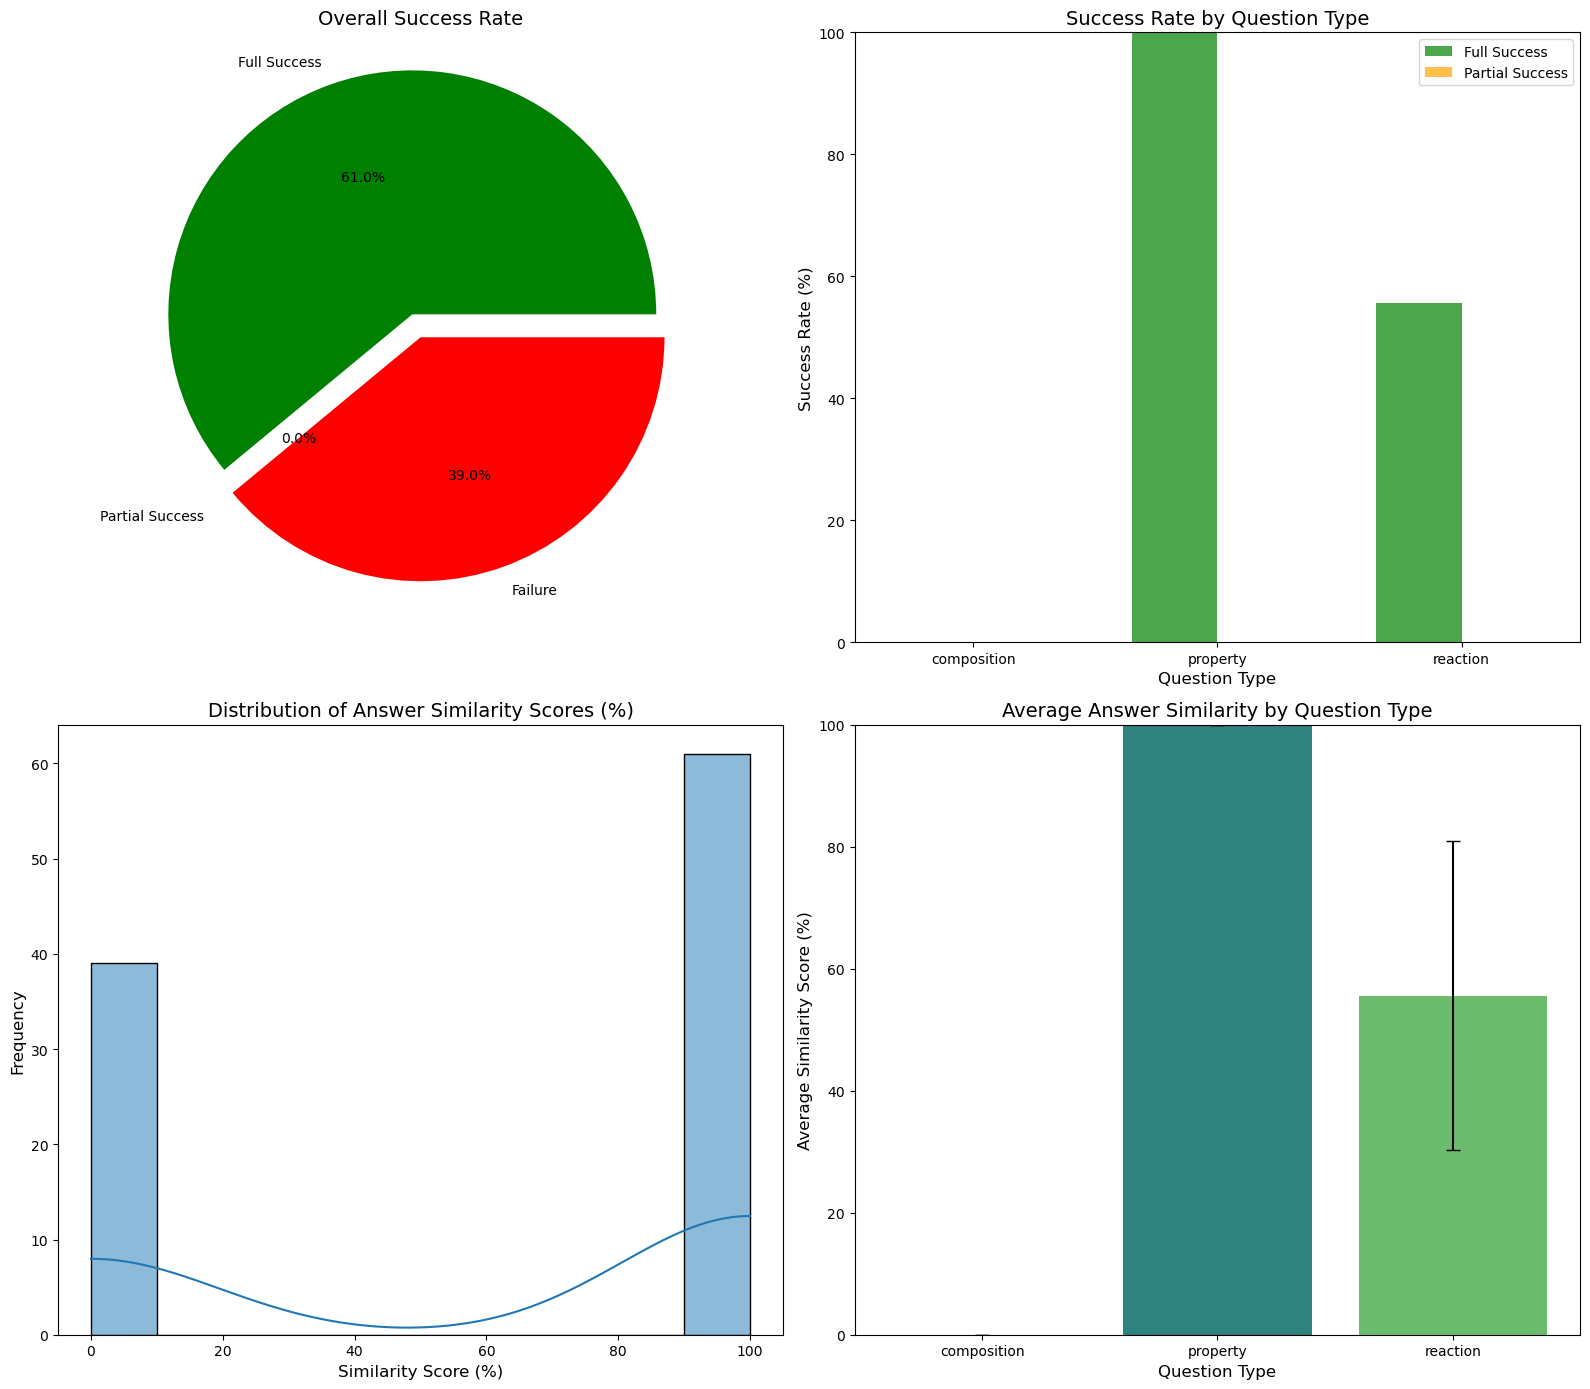


=== DETAILED VALIDATION REPORT ===
Total Questions: 100
Full Success: 61 (61.00%)
Partial Success: 0 (0.00%)
Combined Success: 61 (61.00%)
Average Similarity Score: 61.00%
Average Reasoning Steps: 1.80

Success Rates by Question Type:
  composition: 0.00% full + 0.00% partial = 0.00% combined (similarity: 0.00%)
  property: 100.00% full + 0.00% partial = 100.00% combined (similarity: 100.00%)
  reaction: 55.56% full + 0.00% partial = 55.56% combined (similarity: 55.56%)

Example Successful Reasoning:
Question: What elements are classified as moderately reactive elements?
Expected Answer: Calcium (Ca), Aluminum (Al), Magnesium (Mg), Carbon (C), Hydrogen (H), Nitrogen (N), Phosphorus (P), Sulfur (S)
Derived Answer: Calcium (Ca), Aluminum (Al), Magnesium (Mg), Carbon (C), Hydrogen (H), Nitrogen (N), Phosphorus (P), Sulfur (S)
Similarity: 100.00%
Reasoning Steps:
  Question: What elements are classified as moderately reactive elements?
  Step 1: Identify elements with medium reactivity
  

In [15]:
# main.py
# Main script that integrates the improved ontology reasoner with the enhanced validation system

# Import the improved modules


def main():
    print("===== IMPROVED CHEMISTRY ONTOLOGY REASONING SYSTEM =====")
    print("\n1. Creating enhanced chemistry ontology...")
    reasoner = create_improved_chemistry_ontology()
    
    print("\n2. Running test cases to verify reasoning capabilities...")
    demonstrate_improved_reasoning()
    
    print("\n3. Running comprehensive validation on 100 generated questions...")
    n_questions = 100  # Change this to validate more or fewer questions
    validation_report = run_improved_validation(reasoner, n_questions=n_questions)
    
    print("\nEnhanced validation complete!")
    
if __name__ == "__main__":
    main()

Loading ChEBI ontology from /home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl...
Successfully parsed ontology file with format: xml
Extracting concepts...
Adding concepts to the reasoner...


100%|██████████| 10000/10000 [00:00<00:00, 372939.73it/s]


Adding properties to concepts...


0it [00:00, ?it/s]


Adding relationships between concepts...


0it [00:00, ?it/s]

ChEBI ontology loaded with 10000 concepts and 0 relationships.

=== ChEBI Reasoning Examples ===

--- Example 1 ---
Question: What is glucose?
Expected Answer: Glucose is a monosaccharide and a carbohydrate.

Reasoning Steps:
  Question: What is glucose?
  Step 1: Identify the chemical entity: glucose
  Conclusion: Glucose is a monosaccharide and a carbohydrate.

--- Example 2 ---
Question: Which chemicals are amino acids?
Expected Answer: Glycine, Alanine, Valine, Leucine, Isoleucine, Methionine, Proline, Phenylalanine, Tryptophan, Serine

Reasoning Steps:
  Question: Which chemicals are amino acids?
  Category 'amino acids' not found in the ChEBI ontology

--- Example 3 ---
Question: What are the properties of caffeine?
Expected Answer: Caffeine is an alkaloid with formula C8H10N4O2 and has a role as a central nervous system stimulant.

Reasoning Steps:
  Question: What are the properties of caffeine?
  Entity 'caffeine' not found in the ChEBI ontology

Visualizing subgraph of the Ch

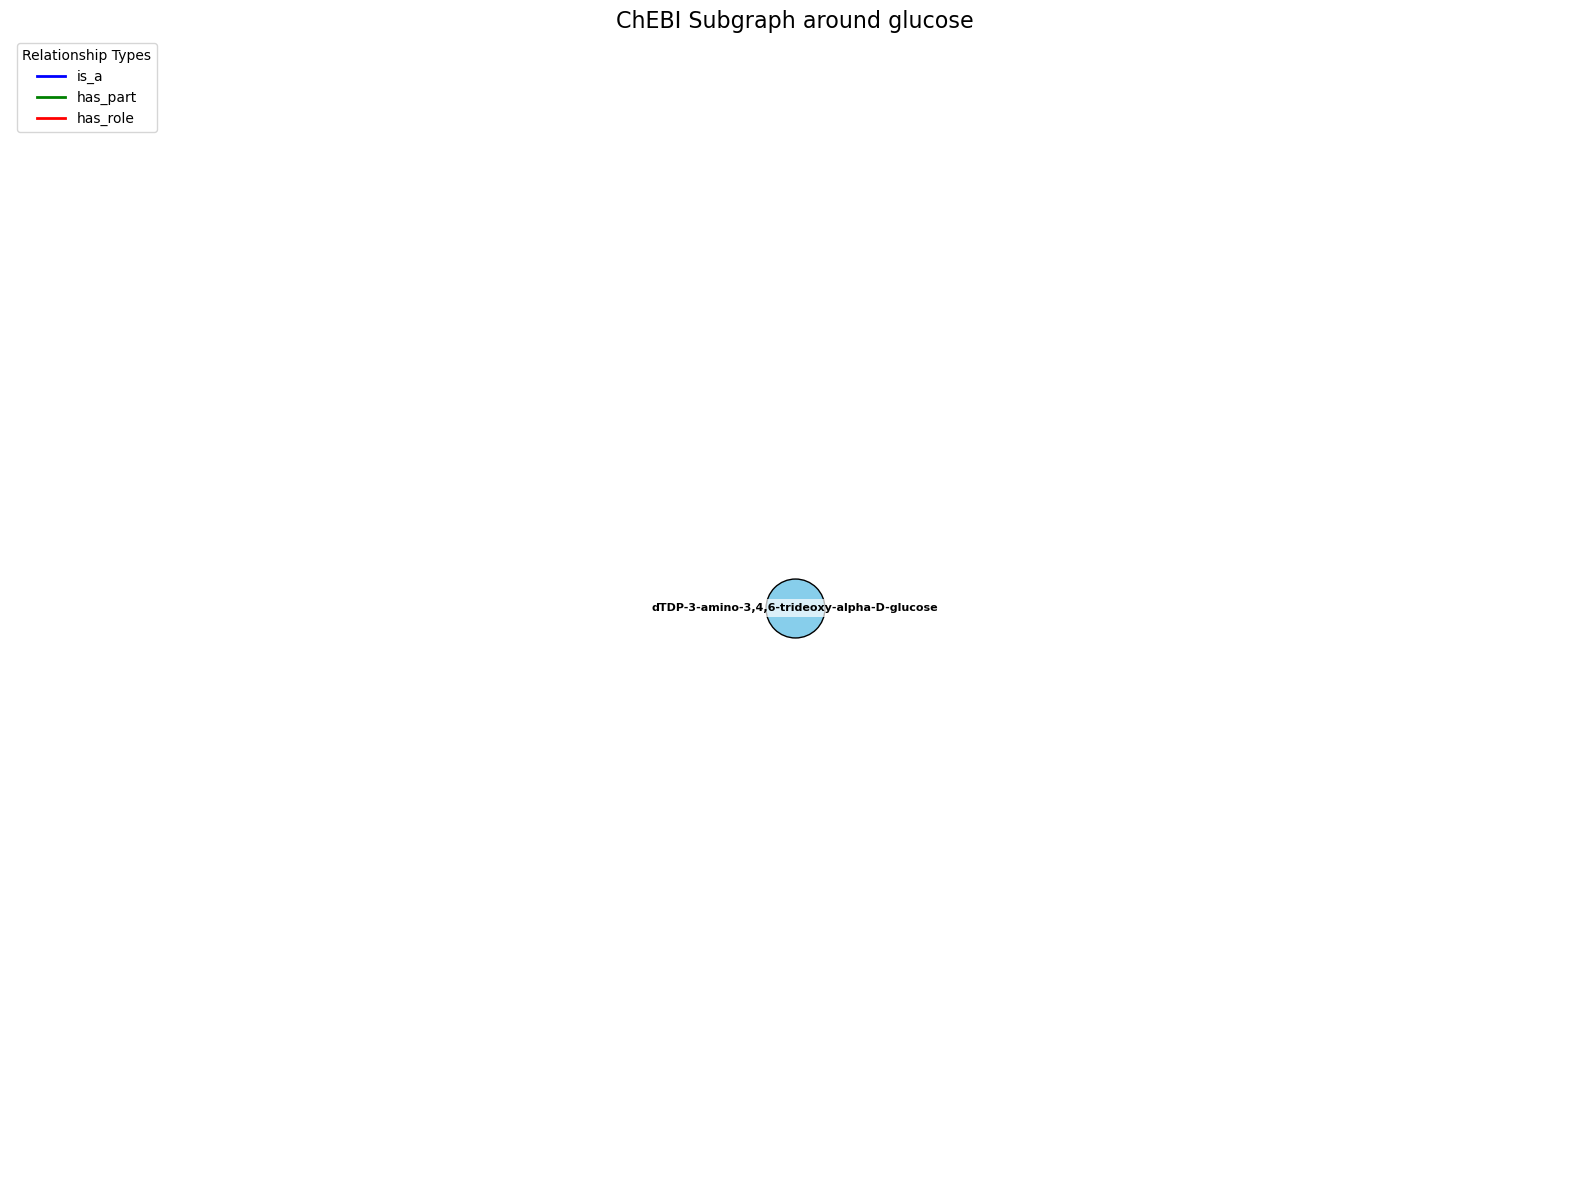

In [19]:
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Set
import re
import os
from rdflib import Graph, URIRef, Literal
from tqdm import tqdm

class ChEBIReasoner:
    """Ontology reasoner that works with the ChEBI ontology"""
    
    def __init__(self):
        # Initialize the ontology as a directed graph
        self.ontology = nx.DiGraph()
        
        # Store rules as (condition, consequence, description) triples
        self.rules = []
        
        # Track relationships between entities
        self.relationships = {}
        
        # ChEBI specific mappings
        self.chebi_id_to_name = {}
        self.name_to_chebi_id = {}
        
    def add_concept(self, concept_id: str, label: str, properties: Dict = None):
        """Add a concept to the ontology with optional properties"""
        if properties is None:
            properties = {}
            
        # Store the label in the properties
        properties['label'] = label
        
        # Add to the graph
        self.ontology.add_node(concept_id, **properties)
        
        # Update mappings
        self.chebi_id_to_name[concept_id] = label
        self.name_to_chebi_id[label.lower()] = concept_id
    
    def add_relationship(self, source_id: str, target_id: str, relation_type: str):
        """Add a relationship between two concepts"""
        self.ontology.add_edge(source_id, target_id, relation=relation_type)
        
        # Store the relationship for easier access
        if relation_type not in self.relationships:
            self.relationships[relation_type] = []
        self.relationships[relation_type].append((source_id, target_id))
    
    def add_rule(self, condition: str, consequence: str, description: str = None):
        """Add a rule to the ontology with optional description"""
        self.rules.append((condition, consequence, description))
    
    def get_concept_by_name(self, name: str):
        """Look up a concept by name, with fuzzy matching if needed"""
        name_lower = name.lower()
        
        # Direct lookup
        if name_lower in self.name_to_chebi_id:
            return self.name_to_chebi_id[name_lower]
        
        # Fuzzy matching
        for label, concept_id in self.name_to_chebi_id.items():
            if name_lower in label or label in name_lower:
                return concept_id
        
        return None
    
    def get_name_by_id(self, concept_id: str):
        """Get the human-readable name for a concept ID"""
        return self.chebi_id_to_name.get(concept_id, concept_id)
    
    def get_related_concepts(self, concept_id: str, relation_type: str) -> List[str]:
        """Get all concepts related to a given concept by a specific relation type"""
        related_ids = []
        for source, target, data in self.ontology.edges(data=True):
            if source == concept_id and data['relation'] == relation_type:
                related_ids.append(target)
        
        # Convert IDs to names
        return [self.get_name_by_id(concept_id) for concept_id in related_ids]
    
    def get_ancestors(self, concept_id: str, relation_type: str = 'is_a') -> List[str]:
        """Get all ancestors of a concept following a specific relation type"""
        ancestors = []
        visited = set()
        
        def dfs(node):
            if node in visited:
                return
            visited.add(node)
            
            for _, parent, data in self.ontology.out_edges(node, data=True):
                if data['relation'] == relation_type:
                    ancestors.append(parent)
                    dfs(parent)
        
        dfs(concept_id)
        return ancestors
    
    def get_descendants(self, concept_id: str, relation_type: str = 'is_a') -> List[str]:
        """Get all descendants of a concept following a specific relation type"""
        descendants = []
        visited = set()
        
        def dfs(node):
            if node in visited:
                return
            visited.add(node)
            
            for child, _, data in self.ontology.in_edges(node, data=True):
                if data['relation'] == relation_type:
                    descendants.append(child)
                    dfs(child)
        
        dfs(concept_id)
        return descendants
    
    def get_concepts_with_property(self, property_name: str, property_value=None) -> List[str]:
        """Get all concepts with a specific property"""
        concept_ids = []
        for node, properties in self.ontology.nodes(data=True):
            if property_name in properties:
                if property_value is None or properties[property_name] == property_value:
                    concept_ids.append(node)
        
        # Convert IDs to names
        return [self.get_name_by_id(concept_id) for concept_id in concept_ids]
    
    def get_concepts_by_category(self, category_name: str) -> List[str]:
        """Get all concepts that belong to a specific category"""
        category_id = self.get_concept_by_name(category_name)
        if not category_id:
            return []
        
        # Get all descendants of the category
        descendants = self.get_descendants(category_id)
        
        # Convert IDs to names
        return [self.get_name_by_id(concept_id) for concept_id in descendants]
    
    def apply_rules(self, facts: Set[str]) -> Tuple[Set[str], List[str]]:
        """Apply rules to derive new facts and return reasoning steps"""
        new_facts = facts.copy()
        reasoning_steps = []
        
        for condition, consequence, description in self.rules:
            if condition in new_facts and consequence not in new_facts:
                new_facts.add(consequence)
                if description:
                    reasoning_steps.append(f"Applied rule: {description}")
                else:
                    reasoning_steps.append(f"From '{condition}', derived '{consequence}'")
                    
        return new_facts, reasoning_steps
    
    def reason(self, question: str, answer: str) -> List[str]:
        """Generate reasoning steps from a question to an answer"""
        reasoning_steps = ["Question: " + question]
        
        # Implement reasoning logic based on question types
        # This will need to be adapted based on how you want to use the ChEBI ontology
        
        if "properties of" in question.lower() or "what is" in question.lower():
            # Extract the chemical entity from the question
            entity_pattern = r"properties of ([A-Za-z0-9\s()-]+)|what is ([A-Za-z0-9\s()-]+)"
            match = re.search(entity_pattern, question, re.IGNORECASE)
            
            if match:
                # Check which capture group has the match (properties of... or what is...)
                entity_name = (match.group(1) or match.group(2)).strip()
                entity_id = self.get_concept_by_name(entity_name)
                
                if entity_id:
                    reasoning_steps.append(f"Step 1: Identify the chemical entity: {entity_name}")
                    
                    # Get properties
                    properties = self.ontology.nodes[entity_id]
                    property_list = []
                    
                    for prop, value in properties.items():
                        if prop != 'label':  # Skip the label property
                            property_list.append(f"{prop}: {value}")
                    
                    if property_list:
                        reasoning_steps.append(f"Step 2: Retrieve properties of {entity_name}")
                        reasoning_steps.append(f"Properties: {', '.join(property_list)}")
                    
                    # Get relationships
                    is_a_relations = self.get_related_concepts(entity_id, 'is_a')
                    if is_a_relations:
                        reasoning_steps.append(f"Step 3: Identify classifications of {entity_name}")
                        reasoning_steps.append(f"{entity_name} is classified as: {', '.join(is_a_relations)}")
                    
                    reasoning_steps.append(f"Conclusion: {answer}")
                else:
                    reasoning_steps.append(f"Entity '{entity_name}' not found in the ChEBI ontology")
        
        elif "which chemicals" in question.lower() or "what chemicals" in question.lower():
            # Extract the category from the question
            category_pattern = r"(?:which|what) chemicals (?:are|belong to) ([A-Za-z0-9\s()-]+)"
            match = re.search(category_pattern, question, re.IGNORECASE)
            
            if match:
                category_name = match.group(1).strip()
                category_id = self.get_concept_by_name(category_name)
                
                if category_id:
                    reasoning_steps.append(f"Step 1: Identify the category: {category_name}")
                    
                    # Get all chemicals in this category
                    chemicals = self.get_concepts_by_category(category_name)
                    
                    if chemicals:
                        reasoning_steps.append(f"Step 2: Find chemicals that belong to {category_name}")
                        reasoning_steps.append(f"Found chemicals: {', '.join(chemicals)}")
                        
                        # Verify against answer
                        expected_chemicals = [c.strip() for c in answer.split(',')]
                        found_all = all(any(expected.lower() in actual.lower() for actual in chemicals) 
                                       for expected in expected_chemicals)
                        
                        if found_all:
                            reasoning_steps.append(f"Step 3: Verify that the answer is complete and correct")
                            reasoning_steps.append(f"Conclusion: {answer}")
                        else:
                            reasoning_steps.append(f"Step 3: The derived answer doesn't match the expected answer")
                            reasoning_steps.append(f"Expected: {answer}")
                            reasoning_steps.append(f"Derived: {', '.join(chemicals)}")
                    else:
                        reasoning_steps.append(f"No chemicals found in category {category_name}")
                else:
                    reasoning_steps.append(f"Category '{category_name}' not found in the ChEBI ontology")
        
        else:
            reasoning_steps.append("This question type is not currently supported by the ChEBI reasoner")
        
        return reasoning_steps
    
    def visualize_subgraph(self, root_concept: str, max_depth: int = 2, relation_types: List[str] = None):
        """Visualize a subgraph of the ontology starting from a root concept"""
        if relation_types is None:
            relation_types = ['is_a', 'has_part']
        
        # Find the root concept ID
        root_id = self.get_concept_by_name(root_concept)
        if not root_id:
            print(f"Concept '{root_concept}' not found in the ontology")
            return
        
        # Extract subgraph
        subgraph_nodes = set([root_id])
        current_nodes = set([root_id])
        
        for _ in range(max_depth):
            next_nodes = set()
            for node in current_nodes:
                for relation_type in relation_types:
                    # Add parents (outgoing edges)
                    for _, target, data in self.ontology.out_edges(node, data=True):
                        if data['relation'] == relation_type:
                            subgraph_nodes.add(target)
                            next_nodes.add(target)
                    
                    # Add children (incoming edges)
                    for source, _, data in self.ontology.in_edges(node, data=True):
                        if data['relation'] == relation_type:
                            subgraph_nodes.add(source)
                            next_nodes.add(source)
            
            current_nodes = next_nodes
        
        # Create subgraph
        subgraph = self.ontology.subgraph(subgraph_nodes)
        
        # Prepare for visualization
        plt.figure(figsize=(16, 12))
        pos = nx.kamada_kawai_layout(subgraph)
        
        # Draw nodes
        nx.draw_networkx_nodes(subgraph, pos, node_size=1800, node_color="skyblue", edgecolors='black')
        
        # Draw edges with different colors
        edge_colors = {'is_a': 'blue', 'has_part': 'green', 'has_role': 'red'}
        
        for rel_type, color in edge_colors.items():
            edges = [(s, t) for s, t, d in subgraph.edges(data=True) if d['relation'] == rel_type]
            if edges:
                nx.draw_networkx_edges(subgraph, pos, edgelist=edges, 
                                      edge_color=color, width=1.5, arrows=True,
                                      arrowstyle='->', arrowsize=15)
        
        # Draw labels with concept names instead of IDs
        labels = {node: self.chebi_id_to_name.get(node, node) for node in subgraph.nodes()}
        nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=8, font_weight='bold',
                                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=3))
        
        # Create custom legend
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0], [0], color=color, lw=2, label=rel) 
                          for rel, color in edge_colors.items()]
        
        plt.title(f"ChEBI Subgraph around {root_concept}", fontsize=16)
        plt.legend(handles=legend_elements, loc='upper left', title="Relationship Types")
        plt.axis('off')
        plt.tight_layout()
        plt.show()


def load_chebi_ontology(file_path: str) -> ChEBIReasoner:
    """Load the ChEBI ontology from an RDF/OWL file into our reasoner"""
    print(f"Loading ChEBI ontology from {file_path}...")
    
    # Create RDF graph
    g = Graph()
    
    # Determine the format based on file extension
    file_format = None
    if file_path.endswith('.owl') or file_path.endswith('.xml'):
        file_format = 'xml'
    elif file_path.endswith('.ttl'):
        file_format = 'turtle'
    elif file_path.endswith('.nt'):
        file_format = 'nt'
    elif file_path.endswith('.n3'):
        file_format = 'n3'
    
    try:
        g.parse(file_path, format=file_format)
        print(f"Successfully parsed ontology file with format: {file_format}")
    except Exception as e:
        print(f"Error parsing with format {file_format}, trying alternate formats...")
        formats_to_try = ['xml', 'turtle', 'nt', 'n3']
        for fmt in formats_to_try:
            if fmt != file_format:
                try:
                    g = Graph()
                    g.parse(file_path, format=fmt)
                    print(f"Successfully parsed using format: {fmt}")
                    break
                except:
                    continue
        else:
            raise Exception(f"Failed to parse ontology file {file_path} with any known format")
    
    # Initialize our reasoner
    reasoner = ChEBIReasoner()
    
    print("Extracting concepts...")
    
    # ChEBI namespace
    chebi_ns = "http://purl.obolibrary.org/obo/CHEBI_"
    
    # Extract chemical entities
    # This query gets entities with their labels
    entity_query = """
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    PREFIX obo: <http://purl.obolibrary.org/obo/>
    PREFIX chebi: <http://purl.obolibrary.org/obo/chebi#>
    
    SELECT ?entity ?label
    WHERE {
        ?entity rdfs:label ?label .
        FILTER(STRSTARTS(STR(?entity), "http://purl.obolibrary.org/obo/CHEBI_"))
    }
    LIMIT 10000
    """
    
    # Extract chemical properties
    property_query = """
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    PREFIX obo: <http://purl.obolibrary.org/obo/>
    PREFIX chebi: <http://purl.obolibrary.org/obo/chebi#>
    
    SELECT ?entity ?property ?value
    WHERE {
        ?entity ?property ?value .
        FILTER(STRSTARTS(STR(?entity), "http://purl.obolibrary.org/obo/CHEBI_"))
        FILTER(?property IN (
            <http://purl.obolibrary.org/obo/chebi#formula>,
            <http://purl.obolibrary.org/obo/chebi#mass>,
            <http://purl.obolibrary.org/obo/chebi#charge>
        ))
    }
    LIMIT 10000
    """
    
    # Extract relationships
    relation_query = """
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    PREFIX obo: <http://purl.obolibrary.org/obo/>
    PREFIX chebi: <http://purl.obolibrary.org/obo/chebi#>
    
    SELECT ?entity1 ?relation ?entity2
    WHERE {
        ?entity1 ?relation ?entity2 .
        FILTER(STRSTARTS(STR(?entity1), "http://purl.obolibrary.org/obo/CHEBI_"))
        FILTER(STRSTARTS(STR(?entity2), "http://purl.obolibrary.org/obo/CHEBI_"))
        FILTER(?relation IN (
            <http://purl.obolibrary.org/obo/chebi#is_a>,
            <http://purl.obolibrary.org/obo/chebi#has_part>,
            <http://purl.obolibrary.org/obo/chebi#has_role>
        ))
    }
    LIMIT 20000
    """
    
    # Helper function to extract ChEBI ID from URI
    def extract_chebi_id(uri):
        if uri.startswith(chebi_ns):
            return uri.replace(chebi_ns, "CHEBI:")
        return uri
    
    # Add entities to the reasoner
    print("Adding concepts to the reasoner...")
    entities = {}  # Store entity properties
    
    for row in tqdm(g.query(entity_query)):
        entity_uri = str(row[0])
        label = str(row[1])
        
        chebi_id = extract_chebi_id(entity_uri)
        entities[chebi_id] = {'label': label}
    
    # Add properties to entities
    print("Adding properties to concepts...")
    for row in tqdm(g.query(property_query)):
        entity_uri = str(row[0])
        property_uri = str(row[1])
        value = str(row[2])
        
        chebi_id = extract_chebi_id(entity_uri)
        if chebi_id in entities:
            # Extract property name from URI
            prop_name = property_uri.split('#')[-1]
            entities[chebi_id][prop_name] = value
    
    # Add all entities to the reasoner
    for chebi_id, props in entities.items():
        label = props.pop('label', chebi_id)
        reasoner.add_concept(chebi_id, label, props)
    
    # Add relationships to the reasoner
    print("Adding relationships between concepts...")
    for row in tqdm(g.query(relation_query)):
        entity1_uri = str(row[0])
        relation_uri = str(row[1])
        entity2_uri = str(row[2])
        
        chebi_id1 = extract_chebi_id(entity1_uri)
        chebi_id2 = extract_chebi_id(entity2_uri)
        
        # Extract relation name from URI
        relation_name = relation_uri.split('#')[-1]
        
        # Map ChEBI relations to our relation types
        relation_map = {
            'is_a': 'is_a',
            'has_part': 'has_part',
            'has_role': 'has_role'
        }
        
        if relation_name in relation_map and chebi_id1 in entities and chebi_id2 in entities:
            reasoner.add_relationship(chebi_id1, chebi_id2, relation_map[relation_name])
    
    print(f"ChEBI ontology loaded with {len(entities)} concepts and {len(reasoner.ontology.edges())} relationships.")
    return reasoner


def demonstrate_chebi_reasoning(reasoner):
    """Demonstrate reasoning with the ChEBI ontology"""
    print("\n=== ChEBI Reasoning Examples ===")
    
    # Example questions
    questions = [
        {
            "question": "What is glucose?",
            "answer": "Glucose is a monosaccharide and a carbohydrate."
        },
        {
            "question": "Which chemicals are amino acids?",
            "answer": "Glycine, Alanine, Valine, Leucine, Isoleucine, Methionine, Proline, Phenylalanine, Tryptophan, Serine"
        },
        {
            "question": "What are the properties of caffeine?",
            "answer": "Caffeine is an alkaloid with formula C8H10N4O2 and has a role as a central nervous system stimulant."
        }
    ]
    
    # Test each question
    for i, q in enumerate(questions):
        print(f"\n--- Example {i+1} ---")
        print(f"Question: {q['question']}")
        print(f"Expected Answer: {q['answer']}")
        
        # Generate reasoning steps
        steps = reasoner.reason(q['question'], q['answer'])
        
        print("\nReasoning Steps:")
        for step in steps:
            print(f"  {step}")
    
    # Visualize a subgraph of the ontology
    print("\nVisualizing subgraph of the ChEBI ontology...")
    reasoner.visualize_subgraph("glucose", max_depth=2)


if __name__ == "__main__":
    # Path to the local ChEBI ontology file
    # Replace with the actual path to your local ChEBI file
    chebi_path = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"
    
    if os.path.exists(chebi_path):
        reasoner = load_chebi_ontology(chebi_path)
        demonstrate_chebi_reasoning(reasoner)
    else:
        print(f"ChEBI ontology file not found at {chebi_path}")
        print("Please update the path to your local ChEBI file.")

In [17]:


def create_simple_demo_ontology():
    """Create a small sample ChEBI-like ontology for demonstration"""
    reasoner = ChEBIReasoner()
    
    # Add common chemical categories
    reasoner.add_concept("CHEBI:33579", "Organic Molecule", {"definition": "Carbon-containing molecules"})
    reasoner.add_concept("CHEBI:33709", "Amino Acid", {"definition": "Building blocks of proteins"})
    reasoner.add_concept("CHEBI:16646", "Carbohydrate", {"definition": "Sugars and their derivatives"})
    reasoner.add_concept("CHEBI:25367", "Molecule", {"definition": "Chemical structure with atoms"})
    reasoner.add_concept("CHEBI:35366", "Alkaloid", {"definition": "Nitrogen-containing compounds"})
    reasoner.add_concept("CHEBI:33281", "Stimulant", {"definition": "Substance that increases activity"})
    
    # Add hierarchy relationships
    reasoner.add_relationship("CHEBI:33579", "CHEBI:25367", "is_a")  # Organic molecule is a molecule
    reasoner.add_relationship("CHEBI:33709", "CHEBI:33579", "is_a")  # Amino acid is an organic molecule
    reasoner.add_relationship("CHEBI:16646", "CHEBI:33579", "is_a")  # Carbohydrate is an organic molecule
    reasoner.add_relationship("CHEBI:35366", "CHEBI:33579", "is_a")  # Alkaloid is an organic molecule
    
    # Add specific chemicals
    # Amino acids
    reasoner.add_concept("CHEBI:15428", "Glycine", {"formula": "C2H5NO2", "mass": "75.07 g/mol"})
    reasoner.add_concept("CHEBI:16977", "Alanine", {"formula": "C3H7NO2", "mass": "89.09 g/mol"})
    reasoner.add_concept("CHEBI:16015", "Serine", {"formula": "C3H7NO3", "mass": "105.09 g/mol"})
    reasoner.add_concept("CHEBI:27897", "Proline", {"formula": "C5H9NO2", "mass": "115.13 g/mol"})
    
    # Carbohydrates
    reasoner.add_concept("CHEBI:17234", "Glucose", {"formula": "C6H12O6", "mass": "180.16 g/mol"})
    reasoner.add_concept("CHEBI:17992", "Fructose", {"formula": "C6H12O6", "mass": "180.16 g/mol"})
    reasoner.add_concept("CHEBI:17992", "Sucrose", {"formula": "C12H22O11", "mass": "342.30 g/mol"})
    
    # Alkaloids/Stimulants
    reasoner.add_concept("CHEBI:27732", "Caffeine", {"formula": "C8H10N4O2", "mass": "194.19 g/mol"})
    reasoner.add_concept("CHEBI:28304", "Nicotine", {"formula": "C10H14N2", "mass": "162.23 g/mol"})
    
    # Add chemical classifications
    # Amino acids
    reasoner.add_relationship("CHEBI:15428", "CHEBI:33709", "is_a")  # Glycine is an amino acid
    reasoner.add_relationship("CHEBI:16977", "CHEBI:33709", "is_a")  # Alanine is an amino acid
    reasoner.add_relationship("CHEBI:16015", "CHEBI:33709", "is_a")  # Serine is an amino acid
    reasoner.add_relationship("CHEBI:27897", "CHEBI:33709", "is_a")  # Proline is an amino acid
    
    # Carbohydrates
    reasoner.add_relationship("CHEBI:17234", "CHEBI:16646", "is_a")  # Glucose is a carbohydrate
    reasoner.add_relationship("CHEBI:17992", "CHEBI:16646", "is_a")  # Fructose is a carbohydrate
    reasoner.add_relationship("CHEBI:17992", "CHEBI:16646", "is_a")  # Sucrose is a carbohydrate
    
    # Alkaloids
    reasoner.add_relationship("CHEBI:27732", "CHEBI:35366", "is_a")  # Caffeine is an alkaloid
    reasoner.add_relationship("CHEBI:28304", "CHEBI:35366", "is_a")  # Nicotine is an alkaloid
    
    # Add functional roles
    reasoner.add_relationship("CHEBI:27732", "CHEBI:33281", "has_role")  # Caffeine has role stimulant
    reasoner.add_relationship("CHEBI:28304", "CHEBI:33281", "has_role")  # Nicotine has role stimulant
    
    return reasoner

def run_demo():
    """Run a demonstration of ChEBI reasoning"""
    # Try to load from file if provided, otherwise use demo data
    import os
    import sys
    
    if len(sys.argv) > 1 and os.path.exists(sys.argv[1]):
        print(f"Loading ChEBI ontology from {sys.argv[1]}...")
        reasoner = load_chebi_ontology(sys.argv[1])
    else:
        print("No valid ChEBI file provided, using demo ontology instead.")
        print("For full functionality, run with: python chebi_demo.py /path/to/chebi.owl")
        reasoner = create_simple_demo_ontology()
    
    # Define test questions
    test_questions = [
        {
            "question": "What is glucose?",
            "answer": "Glucose is a carbohydrate with formula C6H12O6."
        },
        {
            "question": "Which chemicals are amino acids?",
            "answer": "Glycine, Alanine, Serine, Proline"
        },
        {
            "question": "What are the properties of caffeine?",
            "answer": "Caffeine is an alkaloid with formula C8H10N4O2 and has a role as a stimulant."
        }
    ]
    
    # Test reasoning
    print("\n===== CHEBI REASONING DEMONSTRATION =====")
    for i, test in enumerate(test_questions):
        print(f"\n--- Test Question {i+1} ---")
        print(f"Q: {test['question']}")
        print(f"Expected A: {test['answer']}")
        
        # Generate reasoning steps
        steps = reasoner.reason(test["question"], test["answer"])
        
        print("\nReasoning Steps:")
        for step in steps:
            print(f"  {step}")
    
    # Visualize a subgraph
    print("\nCreating visualization of glucose in the ontology...")
    try:
        reasoner.visualize_subgraph("glucose", max_depth=2)
    except Exception as e:
        print(f"Could not create visualization: {str(e)}")
    
    print("\nDemonstration complete!")

if __name__ == "__main__":
    run_demo()

ModuleNotFoundError: No module named 'chebi_integration'

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import requests
import tempfile
import zipfile
import io
import os
import rdflib
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, OWL

# Import the OntologyReasoner class from your original module
# If your class is in a file named ontology_reasoner.py, use:
# from ontology_reasoner import OntologyReasoner

# Since we have the class definition in the provided code, let's define it here:
class OntologyReasoner:
    def __init__(self):
        # Initialize the ontology as a directed graph
        self.ontology = nx.DiGraph()
        
        # Store rules as (condition, consequence) pairs
        self.rules = []
        
        # Track relationships between entities
        self.relationships = {}
        
    def add_concept(self, concept: str, properties=None):
        """Add a concept to the ontology with optional properties"""
        if properties is None:
            properties = {}
        self.ontology.add_node(concept, **properties)
    
    def add_relationship(self, source: str, target: str, relation_type: str):
        """Add a relationship between two concepts"""
        self.ontology.add_edge(source, target, relation=relation_type)
        
        # Store the relationship for easier access
        if relation_type not in self.relationships:
            self.relationships[relation_type] = []
        self.relationships[relation_type].append((source, target))
    
    def add_rule(self, condition: str, consequence: str):
        """Add a rule to the ontology"""
        self.rules.append((condition, consequence))
    
    def get_subclasses(self, concept: str):
        """Get all subclasses of a concept"""
        subclasses = []
        for source, target, data in self.ontology.edges(data=True):
            if target == concept and data['relation'] == 'is_a':
                subclasses.append(source)
                # Recursively get subclasses
                subclasses.extend(self.get_subclasses(source))
        return subclasses
    
    def get_properties(self, concept: str):
        """Get properties of a concept"""
        return self.ontology.nodes[concept]
    
    def apply_rules(self, facts):
        """Apply rules to derive new facts"""
        new_facts = facts.copy()
        changed = True
        
        while changed:
            changed = False
            for condition, consequence in self.rules:
                if condition in new_facts and consequence not in new_facts:
                    new_facts.add(consequence)
                    changed = True
                    
        return new_facts
    
    def reason(self, question: str, answer: str):
        """Generate reasoning steps from a question to an answer"""
        # This is a simplified implementation
        # In a real system, you'd need NLP to parse the question
        
        reasoning_steps = ["Question: " + question]
        
        # Example patterns - in a real system this would be more sophisticated
        if "Which animals" in question:
            category = question.split("Which animals")[1].strip().strip("?")
            if "can" in category:
                ability = category.split("can")[1].strip()
                reasoning_steps.append(f"Step 1: Identify entities that are animals")
                
                # Find animals with the ability
                animals_with_ability = []
                for source, target in self.relationships.get(f"can_{ability}", []):
                    animals_with_ability.append(source)
                
                reasoning_steps.append(f"Step 2: Check which animals can {ability}")
                reasoning_steps.append(f"Found animals that can {ability}: {', '.join(animals_with_ability)}")
                
                # Verify against answer
                expected_animals = [a.strip() for a in answer.split(',')]
                found_all = all(animal in animals_with_ability for animal in expected_animals)
                
                if found_all:
                    reasoning_steps.append(f"Step 3: Verify that the answer is complete and correct")
                    reasoning_steps.append(f"Conclusion: {answer}")
                else:
                    reasoning_steps.append(f"Step 3: The derived answer doesn't match the expected answer")
                    reasoning_steps.append(f"Expected: {answer}")
                    reasoning_steps.append(f"Derived: {', '.join(animals_with_ability)}")
        
        return reasoning_steps
    
    def visualize(self):
        """Visualize the ontology"""
        plt.figure(figsize=(12, 8))
        
        # Create position layout
        pos = nx.spring_layout(self.ontology)
        
        # Draw nodes
        nx.draw_networkx_nodes(self.ontology, pos, node_size=2000, node_color="lightblue")
        
        # Draw edges with different colors based on relation type
        relation_colors = {
            'is_a': 'blue',
            'has_part': 'green',
            'can_fly': 'red',
            'can_swim': 'purple',
            'can_run': 'orange'
        }
        
        for relation, color in relation_colors.items():
            edges = [(s, t) for s, t, d in self.ontology.edges(data=True) if d['relation'] == relation]
            if edges:
                nx.draw_networkx_edges(self.ontology, pos, edgelist=edges, 
                                      edge_color=color, width=2, label=relation)
        
        # Draw labels
        nx.draw_networkx_labels(self.ontology, pos, font_size=10)
        
        plt.title("Ontology Visualization")
        plt.legend()
        plt.axis('off')
        plt.tight_layout()
        plt.show()

class ChEBIOntologyReasoner(OntologyReasoner):
    def __init__(self):
        super().__init__()
        self.chebi_namespaces = {}
    
    def load_chebi_ontology(self, source='download', file_path=None):
        """
        Load the ChEBI ontology into the reasoner.
        
        Parameters:
        - source: 'download' to download the latest version or 'file' to load from a local file
        - file_path: Path to the local OWL file (only used if source='file')
        """
        print("Loading ChEBI ontology...")
        
        # Initialize RDF graph
        chebi_graph = Graph()
        
        if source == 'download':
            # URL for the latest ChEBI ontology OWL file
            chebi_url = "https://ftp.ebi.ac.uk/pub/databases/chebi/ontology/chebi.owl"
            print(f"Downloading ChEBI ontology from {chebi_url}...")
            response = requests.get(chebi_url)
            
            # Parse the OWL file
            chebi_graph.parse(data=response.content, format="xml")
            print("Download and parsing complete.")
            
        elif source == 'file' and file_path:
            print(f"Loading ChEBI ontology from {file_path}...")
            chebi_graph.parse(file_path, format="xml")
            print("Loading complete.")
            
        else:
            raise ValueError("Invalid source or missing file path.")
        
        # Set up namespaces
        self.chebi_namespaces = {
            'chebi': Namespace("http://purl.obolibrary.org/obo/CHEBI_"),
            'rdfs': RDFS,
            'rdf': RDF,
            'owl': OWL
        }
        
        # Process the ontology
        self._process_chebi_graph(chebi_graph)
        print("ChEBI ontology successfully integrated!")
    
    def _process_chebi_graph(self, graph):
        """Process the RDF graph and add concepts and relationships to the ontology"""
        
        # Extract all ChEBI entities
        print("Extracting ChEBI entities...")
        chebi_ns = self.chebi_namespaces['chebi']
        
        # Get all classes (concepts)
        classes_query = """
        SELECT DISTINCT ?chebi_class ?label
        WHERE {
            ?chebi_class a owl:Class .
            ?chebi_class rdfs:label ?label .
            FILTER(STRSTARTS(STR(?chebi_class), STR(chebi:)))
        }
        """
        
        for row in graph.query(classes_query, initNs=self.chebi_namespaces):
            class_uri = str(row.chebi_class)
            label = str(row.label)
            
            # Extract ChEBI ID from URI
            chebi_id = class_uri.split('/')[-1]
            
            # Add the concept with its properties
            self.add_concept(chebi_id, {
                'label': label,
                'uri': class_uri,
                'type': 'ChEBI'
            })
        
        print(f"Added {len([n for n,d in self.ontology.nodes(data=True) if d.get('type')=='ChEBI'])} ChEBI concepts")
        
        # Extract subclass relationships
        print("Extracting subclass relationships...")
        subclass_query = """
        SELECT DISTINCT ?subClass ?superClass
        WHERE {
            ?subClass rdfs:subClassOf ?superClass .
            ?subClass a owl:Class .
            ?superClass a owl:Class .
            FILTER(STRSTARTS(STR(?subClass), STR(chebi:)))
            FILTER(STRSTARTS(STR(?superClass), STR(chebi:)))
        }
        """
        
        is_a_count = 0
        for row in graph.query(subclass_query, initNs=self.chebi_namespaces):
            sub_uri = str(row.subClass)
            super_uri = str(row.superClass)
            
            # Extract ChEBI IDs from URIs
            sub_id = sub_uri.split('/')[-1]
            super_id = super_uri.split('/')[-1]
            
            # Add the relationship
            if sub_id in self.ontology.nodes and super_id in self.ontology.nodes:
                self.add_relationship(sub_id, super_id, 'is_a')
                is_a_count += 1
        
        print(f"Added {is_a_count} 'is_a' relationships")
        
        # Extract other relationships (e.g., has_role, has_part)
        print("Extracting other relationships...")
        relation_query = """
        SELECT DISTINCT ?subject ?predicate ?object
        WHERE {
            ?subject ?predicate ?object .
            ?subject a owl:Class .
            ?object a owl:Class .
            FILTER(STRSTARTS(STR(?subject), STR(chebi:)))
            FILTER(STRSTARTS(STR(?object), STR(chebi:)))
            FILTER(?predicate != rdfs:subClassOf)
        }
        """
        
        other_rel_count = 0
        for row in graph.query(relation_query, initNs=self.chebi_namespaces):
            sub_uri = str(row.subject)
            pred_uri = str(row.predicate)
            obj_uri = str(row.object)
            
            # Extract IDs from URIs
            sub_id = sub_uri.split('/')[-1]
            obj_id = obj_uri.split('/')[-1]
            
            # Get the predicate name (last part of the URI)
            pred_name = pred_uri.split('/')[-1]
            
            # Add the relationship
            if sub_id in self.ontology.nodes and obj_id in self.ontology.nodes:
                self.add_relationship(sub_id, obj_id, pred_name)
                other_rel_count += 1
        
        print(f"Added {other_rel_count} other relationships")
    
    def visualize_subset(self, root_concept, max_depth=2):
        """
        Visualize a subset of the ontology starting from a root concept
        
        Parameters:
        - root_concept: The starting concept (ChEBI ID)
        - max_depth: Maximum depth to traverse
        """
        # Create a subgraph by traversing the ontology
        subgraph = nx.DiGraph()
        visited = set()
        
        def traverse(concept, depth=0):
            if depth > max_depth or concept in visited:
                return
            
            visited.add(concept)
            concept_props = self.get_properties(concept)
            subgraph.add_node(concept, **concept_props)
            
            # Add parent relationships
            for _, parent, data in self.ontology.out_edges(concept, data=True):
                subgraph.add_node(parent, **self.get_properties(parent))
                subgraph.add_edge(concept, parent, **data)
                traverse(parent, depth + 1)
            
            # Add child relationships
            for child, _, data in self.ontology.in_edges(concept, data=True):
                subgraph.add_node(child, **self.get_properties(child))
                subgraph.add_edge(child, concept, **data)
                traverse(child, depth + 1)
        
        # Start traversal
        traverse(root_concept)
        
        # Visualization
        plt.figure(figsize=(15, 10))
        pos = nx.spring_layout(subgraph, k=1.5/np.sqrt(len(subgraph.nodes())))
        
        # Draw nodes
        nx.draw_networkx_nodes(subgraph, pos, node_size=1500, node_color="lightblue")
        
        # Draw edges with different colors based on relation type
        relation_types = set([d['relation'] for _, _, d in subgraph.edges(data=True)])
        colors = plt.cm.tab10(np.linspace(0, 1, len(relation_types)))
        relation_colors = dict(zip(relation_types, colors))
        
        for relation, color in relation_colors.items():
            edges = [(s, t) for s, t, d in subgraph.edges(data=True) if d['relation'] == relation]
            if edges:
                nx.draw_networkx_edges(subgraph, pos, edgelist=edges, 
                                     edge_color=color, width=2, label=relation)
        
        # Draw labels with ChEBI names instead of IDs
        labels = {}
        for node in subgraph.nodes():
            props = subgraph.nodes[node]
            if 'label' in props:
                # Show a shorter label if it's too long
                label = props['label']
                if len(label) > 20:
                    label = label[:17] + "..."
                labels[node] = f"{node}\n{label}"
            else:
                labels[node] = node
        
        nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=8)
        
        plt.title(f"ChEBI Ontology Subset: Starting from {root_concept}")
        plt.legend()
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    def query_chebi(self, query_type, params):
        """
        Query the ChEBI ontology
        
        Parameters:
        - query_type: Type of query, e.g., 'subclasses', 'properties', 'path'
        - params: Parameters for the query
        
        Returns:
        - The query results
        """
        if query_type == 'subclasses':
            # Get all subclasses of a concept
            return self.get_subclasses(params['concept'])
            
        elif query_type == 'properties':
            # Get properties of a concept
            return self.get_properties(params['concept'])
            
        elif query_type == 'path':
            # Find path between two concepts
            source = params['source']
            target = params['target']
            
            try:
                # Use NetworkX to find the shortest path
                path = nx.shortest_path(self.ontology, source=source, target=target)
                
                # Get the relationships along the path
                relationships = []
                for i in range(len(path)-1):
                    edge_data = self.ontology.get_edge_data(path[i], path[i+1])
                    relationships.append(edge_data['relation'])
                
                return {
                    'path': path,
                    'relationships': relationships
                }
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                return {
                    'path': None,
                    'relationships': None,
                    'error': 'No path found or concepts not in ontology'
                }
        
        elif query_type == 'search':
            # Search for concepts by name
            search_term = params['term'].lower()
            results = []
            
            for node, data in self.ontology.nodes(data=True):
                if 'label' in data and search_term in data['label'].lower():
                    results.append({
                        'id': node,
                        'label': data['label'],
                        'uri': data.get('uri', '')
                    })
            
            return results
        
        else:
            return {'error': 'Unknown query type'}

# Example usage
def demonstrate_chebi_integration():
    """Demonstrate the integration of ChEBI ontology"""
    
    # Create ChEBI reasoner
    reasoner = ChEBIOntologyReasoner()
    
    # Option 1: Download and load the ontology (might take some time)
    # reasoner.load_chebi_ontology(source='download')
    
    # Option 2: Load from a local file (if you've previously downloaded it)
    reasoner.load_chebi_ontology(source='file', file_path='/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl')
    
    # Example queries
    
    # 1. Search for a compound
    search_results = reasoner.query_chebi('search', {'term': 'glucose'})
    print(f"Found {len(search_results)} results for 'glucose'")
    for result in search_results[:5]:  # Show top 5 results
        print(f"  - {result['id']}: {result['label']}")
    
    # 2. Get properties of a compound
    if search_results:
        glucose_id = search_results[0]['id']
        glucose_properties = reasoner.query_chebi('properties', {'concept': glucose_id})
        print(f"\nProperties of {glucose_id} ({glucose_properties.get('label')}):")
        for key, value in glucose_properties.items():
            print(f"  - {key}: {value}")
    
    # 3. Visualize a subset of the ontology
    if search_results:
        print("\nVisualizing a subset of ChEBI ontology...")
        reasoner.visualize_subset(glucose_id, max_depth=2)
    
    # 4. Find path between two compounds
    if len(search_results) >= 2:
        source_id = search_results[0]['id']
        target_id = search_results[1]['id']
        path_result = reasoner.query_chebi('path', {'source': source_id, 'target': target_id})
        
        if path_result.get('path'):
            print(f"\nPath from {source_id} to {target_id}:")
            for i, (node, rel) in enumerate(zip(path_result['path'][:-1], path_result['relationships'])):
                next_node = path_result['path'][i+1]
                node_label = reasoner.get_properties(node).get('label', node)
                next_label = reasoner.get_properties(next_node).get('label', next_node)
                print(f"  {node} ({node_label}) --[{rel}]--> {next_node} ({next_label})")
        else:
            print(f"\nNo path found between {source_id} and {target_id}")



In [3]:
class ChEBIOntologyReasoner(OntologyReasoner):
    def __init__(self):
        super().__init__()
        self.chebi_namespaces = {}

    def _process_chebi_graph(self, graph):
        """Process the RDF graph with optimized bulk operations"""
        chebi_ns = self.chebi_namespaces['chebi']
        
        # Process nodes (concepts) in bulk
        nodes = []
        classes_query = """
        SELECT DISTINCT ?chebi_class ?label
        WHERE {
            ?chebi_class a owl:Class ;
                         rdfs:label ?label .
            FILTER(STRSTARTS(STR(?chebi_class), STR(chebi:)))
        }"""
        for row in graph.query(classes_query, initNs=self.chebi_namespaces):
            uri = str(row.chebi_class)
            chebi_id = uri.split('/')[-1]
            nodes.append((chebi_id, {
                'label': str(row.label),
                'uri': uri,
                'type': 'ChEBI'
            }))
        self.ontology.add_nodes_from(nodes)
        print(f"Added {len(nodes)} ChEBI concepts")

        # Process 'is_a' relationships in bulk
        edges = []
        is_a_rels = []
        subclass_query = """
        SELECT DISTINCT ?subClass ?superClass
        WHERE {
            ?subClass rdfs:subClassOf ?superClass .
            FILTER(STRSTARTS(STR(?subClass), STR(chebi:)))
            FILTER(STRSTARTS(STR(?superClass), STR(chebi:)))
        }"""
        for row in graph.query(subclass_query, initNs=self.chebi_namespaces):
            sub_id = row.subClass.split('/')[-1]
            super_id = row.superClass.split('/')[-1]
            edges.append((sub_id, super_id, {'relation': 'is_a'}))
            is_a_rels.append((sub_id, super_id))
        self.ontology.add_edges_from(edges)
        self.relationships['is_a'] = is_a_rels
        print(f"Added {len(edges)} 'is_a' relationships")

        # Process other relationships in bulk
        edges = []
        other_rels = defaultdict(list)
        relation_query = """
        SELECT DISTINCT ?subject ?predicate ?object
        WHERE {
            ?subject ?predicate ?object .
            FILTER(?predicate != rdfs:subClassOf)
            FILTER(STRSTARTS(STR(?subject), STR(chebi:)))
            FILTER(STRSTARTS(STR(?object), STR(chebi:)))
        }"""
        for row in graph.query(relation_query, initNs=self.chebi_namespaces):
            sub_id = row.subject.split('/')[-1]
            pred = row.predicate.split('/')[-1]
            obj_id = row.object.split('/')[-1]
            edges.append((sub_id, obj_id, {'relation': pred}))
            other_rels[pred].append((sub_id, obj_id))
        self.ontology.add_edges_from(edges)
        self.relationships.update(other_rels)
        print(f"Added {len(edges)} other relationships")

In [4]:
chebi_graph.parse(data=response.content, format="xml", parser='lxml')

NameError: name 'chebi_graph' is not defined

Glucose hierarchy:
{'CHEBI_10502': {'label': 'dTDP-3-amino-3,4,6-trideoxy-alpha-D-glucose', 'level': 0}, 'CHEBI_28375': {'label': 'dTDP-3-amino-3,4,6-trideoxy-D-glucose', 'level': 1}, 'N9ce4569292f549d98aa9458a091931f1': {'label': None, 'level': 1}, 'CHEBI_29718': {'label': None, 'level': 2}, 'CHEBI_23535': {'label': None, 'level': 2}, 'CHEBI_23557': {'label': 'dTDP-sugar', 'level': 2}, 'Nb260c7fd01a04fe0bdcf31200558175c': {'label': None, 'level': 2}}


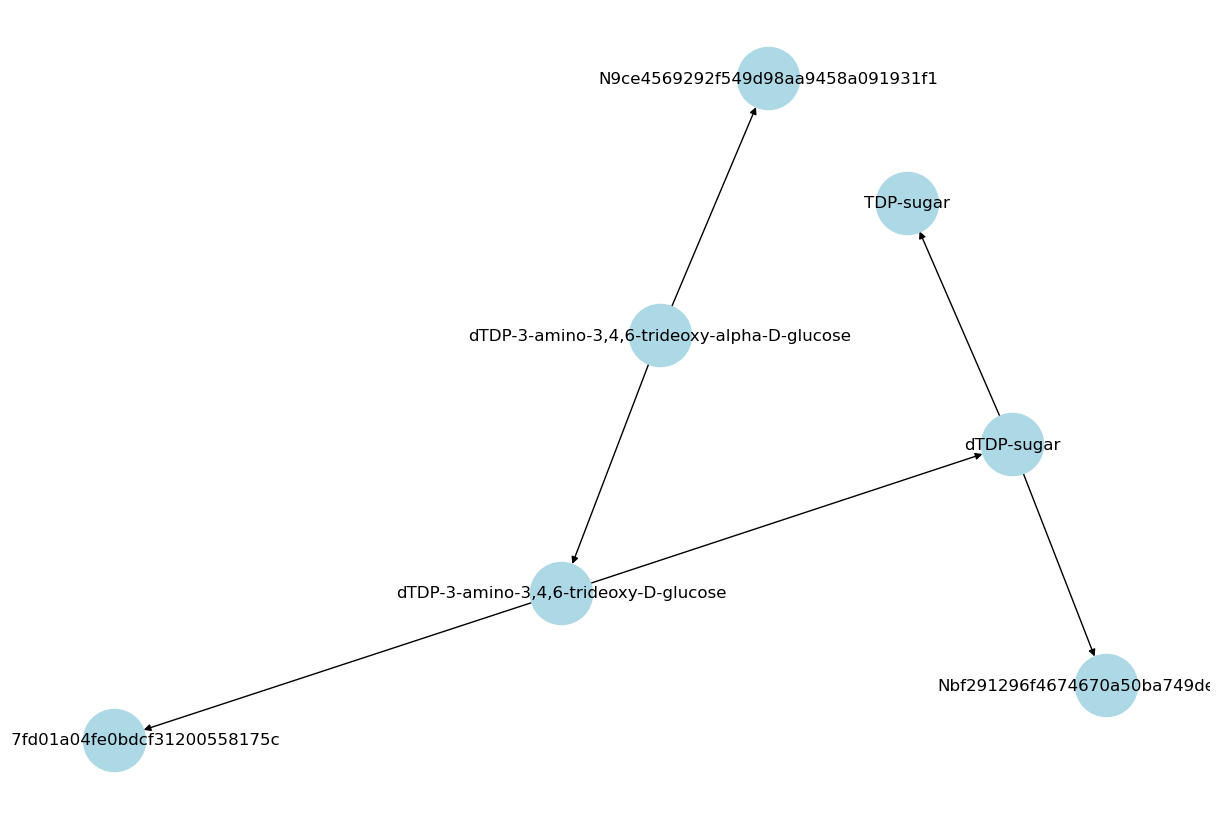

Path from CHEBI:17234 to CHEBI:16670:


NodeNotFound: Either source CHEBI:17234 or target CHEBI:16670 is not in G

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from rdflib import Graph, Namespace
from rdflib.namespace import RDF, RDFS, OWL
from collections import defaultdict
import requests

class OptimizedChEBIOntology:
    def __init__(self):
        self.graph = nx.DiGraph()
        self.relations = defaultdict(list)
        self.ns = {
            'chebi': Namespace("http://purl.obolibrary.org/obo/CHEBI_"),
            'rdfs': RDFS,
            'rdf': RDF,
            'owl': OWL
        }
    
    def load_ontology(self, source='download', file_path=None):
        """Load ontology with optimized parsing"""
        rdf_graph = Graph()
        
        if source == 'download':
            content = requests.get("https://ftp.ebi.ac.uk/pub/databases/chebi/ontology/chebi.owl").content
            rdf_graph.parse(data=content, format="xml", parser='lxml')  # Use lxml for faster parsing
        elif source == 'file' and file_path:
            rdf_graph.parse(file_path, format="xml", parser='lxml')
        else:
            raise ValueError("Invalid source")

        self._process_rdf_bulk(rdf_graph)

    def _process_rdf_bulk(self, rdf_graph):
        """Bulk process RDF data with optimized SPARQL queries"""
        # Bulk load all concepts first
        concepts = [
            (str(row.chebi_class).split('/')[-1], {'label': str(row.label)})
            for row in rdf_graph.query("""
                SELECT ?chebi_class ?label WHERE {
                    ?chebi_class a owl:Class ;
                                 rdfs:label ?label .
                    FILTER(STRSTARTS(STR(?chebi_class), "http://purl.obolibrary.org/obo/CHEBI_"))
                }""", initNs=self.ns)
        ]
        self.graph.add_nodes_from(concepts)

        # Bulk load is_a relationships
        is_a_edges = [
            (str(row.subClass).split('/')[-1], 
             str(row.superClass).split('/')[-1],
             {'relation': 'is_a'})
            for row in rdf_graph.query("""
                SELECT ?subClass ?superClass WHERE {
                    ?subClass rdfs:subClassOf ?superClass .
                    FILTER(STRSTARTS(STR(?subClass), "http://purl.obolibrary.org/obo/CHEBI_"))
                }""", initNs=self.ns)
        ]
        self.graph.add_edges_from(is_a_edges)
        self.relations['is_a'] = [(s, t) for s, t, _ in is_a_edges]

        # Bulk load other relationships
        other_edges = []
        for row in rdf_graph.query("""
            SELECT ?s ?p ?o WHERE {
                ?s ?p ?o .
                FILTER(?p NOT IN (rdf:type, rdfs:subClassOf))
                FILTER(STRSTARTS(STR(?s), "http://purl.obolibrary.org/obo/CHEBI_"))
                FILTER(STRSTARTS(STR(?o), "http://purl.obolibrary.org/obo/CHEBI_"))
            }"""):
            s = str(row.s).split('/')[-1]
            p = str(row.p).split('/')[-1]
            o = str(row.o).split('/')[-1]
            other_edges.append((s, o, {'relation': p}))
            self.relations[p].append((s, o))
        
        self.graph.add_edges_from(other_edges)

    def get_hierarchy(self, concept, depth=2):
        """Efficient hierarchy retrieval using BFS"""
        hierarchy = {}
        visited = set()
        queue = [(concept, 0)]
        
        while queue:
            node, level = queue.pop(0)
            if level > depth or node in visited:
                continue
                
            visited.add(node)
            hierarchy[node] = {
                'label': self.graph.nodes[node].get('label'),
                'level': level
            }
            
            # Add parents and children
            queue.extend((n, level+1) for n in self.graph.predecessors(node))
            queue.extend((n, level+1) for n in self.graph.successors(node))
            
        return hierarchy

    def visualize_subgraph(self, root, max_depth=2):
        """Optimized visualization using efficient traversal"""
        subgraph = nx.DiGraph()
        visited = set()
        queue = [(root, 0)]
        
        while queue:
            node, depth = queue.pop(0)
            if depth > max_depth or node in visited:
                continue
                
            visited.add(node)
            subgraph.add_node(node, **self.graph.nodes[node])
            
            for neighbor in self.graph.successors(node):
                edge_data = self.graph.get_edge_data(node, neighbor)
                subgraph.add_edge(node, neighbor, **edge_data)
                queue.append((neighbor, depth+1))
                
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(subgraph)
        nx.draw(subgraph, pos, with_labels=True, 
               labels={n: self.graph.nodes[n].get('label', n) for n in subgraph.nodes()},
               node_size=2000, node_color='lightblue')
        plt.show()

    def query(self, q_type, **kwargs):
        """Optimized query handler"""
        if q_type == 'subclasses':
            return list(nx.descendants(self.graph, kwargs['concept']))
        elif q_type == 'search':
            term = kwargs['term'].lower()
            return [n for n, data in self.graph.nodes(data=True)
                   if term in data.get('label', '').lower()]
        elif q_type == 'path':
            try:
                return nx.shortest_path(self.graph, kwargs['source'], kwargs['target'])
            except nx.NetworkXNoPath:
                return None

# Usage Example
if __name__ == "__main__":
    chebi = OptimizedChEBIOntology()
    
    # Load from local file (much faster than download)
    chebi.load_ontology(source='file', file_path='/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl')
    
    # Example queries
    glucose = next((n for n, data in chebi.graph.nodes(data=True) 
                   if 'glucose' in data.get('label', '').lower()), None)
    
    if glucose:
        print(f"Glucose hierarchy:")
        print(chebi.get_hierarchy(glucose))
        chebi.visualize_subgraph(glucose)
        
    print("Path from CHEBI:17234 to CHEBI:16670:")
    print(chebi.query('path', source='CHEBI:17234', target='CHEBI:16670'))

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Set, Optional, Union
import pandas as pd
import requests
import os
import xml.etree.ElementTree as ET
import obonet  # pip install obonet
from tqdm import tqdm  # For progress bars

class ChEBIOntologyReasoner:
    def __init__(self, load_from_file: bool = True, file_path: str = "chebi.obo"):
        """
        Initialize the ChEBI ontology reasoner
        
        Args:
            load_from_file: Whether to load the ontology from a local file
            file_path: Path to the ChEBI ontology file (.obo format)
        """
        # Initialize the ontology as a directed graph
        self.ontology = nx.MultiDiGraph()
        
        # Store rules and relationships
        self.rules = []
        self.relationships = {}
        
        # Track IDs to names mapping
        self.id_to_name = {}
        self.name_to_id = {}
        
        # Load ChEBI ontology if specified
        if load_from_file:
            self.load_chebi_ontology(file_path)
    
    def load_chebi_ontology(self, file_path: str):
        """
        Load the ChEBI ontology from an OBO file
        
        Args:
            file_path: Path to the ChEBI ontology file (.obo format)
        """
        # Check if file exists, download if not
        if not os.path.exists(file_path):
            print(f"ChEBI ontology file not found at {file_path}. Downloading...")
            self._download_chebi_ontology(file_path)
        
        print(f"Loading ChEBI ontology from {file_path}...")
        # Load the ontology using obonet
        try:
            graph = obonet.read_obo(file_path)
            
            # Convert obonet graph to networkx MultiDiGraph
            for node_id, data in tqdm(graph.nodes(data=True), desc="Loading nodes"):
                # Extract entity name from data
                name = data.get('name', node_id)
                
                # Store ID to name mapping
                self.id_to_name[node_id] = name
                self.name_to_id[name] = node_id
                
                # Add node to the ontology
                self.ontology.add_node(node_id, **data)
            
            # Add relationships
            for u, v, key, data in tqdm(graph.edges(keys=True, data=True), desc="Loading relationships"):
                relation_type = key
                
                # Add edge to the ontology
                self.ontology.add_edge(u, v, relation=relation_type, **data)
                
                # Store relationship for easier access
                if relation_type not in self.relationships:
                    self.relationships[relation_type] = []
                self.relationships[relation_type].append((u, v))
            
            print(f"ChEBI ontology loaded successfully with {self.ontology.number_of_nodes()} nodes and {self.ontology.number_of_edges()} relationships.")
        
        except Exception as e:
            print(f"Error loading ChEBI ontology: {e}")
            raise
    
    def _download_chebi_ontology(self, file_path: str):
        """
        Download the ChEBI ontology from the official repository
        
        Args:
            file_path: Where to save the downloaded ontology
        """
        url = "https://ftp.ebi.ac.uk/pub/databases/chebi/ontology/chebi.obo"
        try:
            response = requests.get(url, stream=True)
            response.raise_for_status()
            
            total_size = int(response.headers.get('content-length', 0))
            block_size = 8192
            
            with open(file_path, 'wb') as f:
                for chunk in tqdm(
                    response.iter_content(chunk_size=block_size),
                    total=total_size//block_size,
                    unit='KB',
                    desc="Downloading ChEBI ontology"
                ):
                    if chunk:
                        f.write(chunk)
            
            print(f"ChEBI ontology downloaded successfully to {file_path}")
        
        except Exception as e:
            print(f"Error downloading ChEBI ontology: {e}")
            if os.path.exists(file_path):
                os.remove(file_path)
            raise
    
    def add_concept(self, concept_id: str, properties: Dict = None):
        """Add a concept to the ontology with optional properties"""
        if properties is None:
            properties = {}
        
        # If concept_id is a name, convert to ID if possible
        if concept_id in self.name_to_id:
            concept_id = self.name_to_id[concept_id]
        
        self.ontology.add_node(concept_id, **properties)
    
    def add_relationship(self, source: str, target: str, relation_type: str, properties: Dict = None):
        """
        Add a relationship between two concepts
        
        Args:
            source: Source concept ID or name
            target: Target concept ID or name
            relation_type: Type of relation
            properties: Optional properties for the relationship
        """
        if properties is None:
            properties = {}
        
        # Convert names to IDs if possible
        if source in self.name_to_id:
            source = self.name_to_id[source]
        if target in self.name_to_id:
            target = self.name_to_id[target]
        
        # Add edge to the ontology
        self.ontology.add_edge(source, target, relation=relation_type, **properties)
        
        # Store relationship for easier access
        if relation_type not in self.relationships:
            self.relationships[relation_type] = []
        self.relationships[relation_type].append((source, target))
    
    def add_rule(self, condition: str, consequence: str, description: str = None):
        """Add a rule to the ontology with optional description"""
        self.rules.append((condition, consequence, description))
    
    def get_entity_by_id(self, entity_id: str) -> Dict:
        """
        Get entity data by ID
        
        Args:
            entity_id: ChEBI ID
        
        Returns:
            Dictionary with entity properties
        """
        if entity_id in self.ontology.nodes:
            return self.ontology.nodes[entity_id]
        return None
    
    def get_entity_by_name(self, name: str) -> Dict:
        """
        Get entity data by name
        
        Args:
            name: Entity name
        
        Returns:
            Dictionary with entity properties
        """
        if name in self.name_to_id:
            entity_id = self.name_to_id[name]
            return self.get_entity_by_id(entity_id)
        return None
    
    def search_entities(self, query: str, limit: int = 10) -> List[Tuple[str, str]]:
        """
        Search for entities by name or ID
        
        Args:
            query: Search query
            limit: Maximum number of results
        
        Returns:
            List of tuples containing (entity_id, entity_name)
        """
        results = []
        
        # Search by ID
        if query.startswith("CHEBI:"):
            if query in self.ontology.nodes:
                name = self.id_to_name.get(query, query)
                results.append((query, name))
        
        # Search by name
        query_lower = query.lower()
        for entity_id, name in self.id_to_name.items():
            if query_lower in name.lower():
                results.append((entity_id, name))
                if len(results) >= limit:
                    break
        
        return results
    
    def get_related_concepts(self, concept: str, relation_type: str = None) -> List[Tuple[str, str, str]]:
        """
        Get all concepts related to a given concept, optionally filtered by relation type
        
        Args:
            concept: Concept ID or name
            relation_type: Optional relation type filter
        
        Returns:
            List of tuples containing (source, target, relation_type)
        """
        # Convert name to ID if possible
        if concept in self.name_to_id:
            concept = self.name_to_id[concept]
        
        related = []
        
        # Get outgoing relationships
        for _, target, data in self.ontology.out_edges(concept, data=True):
            edge_relation = data.get('relation', '')
            if relation_type is None or edge_relation == relation_type:
                source_name = self.id_to_name.get(concept, concept)
                target_name = self.id_to_name.get(target, target)
                related.append((source_name, target_name, edge_relation))
        
        # Get incoming relationships
        for source, _, data in self.ontology.in_edges(concept, data=True):
            edge_relation = data.get('relation', '')
            if relation_type is None or edge_relation == relation_type:
                source_name = self.id_to_name.get(source, source)
                target_name = self.id_to_name.get(concept, concept)
                related.append((source_name, target_name, edge_relation))
        
        return related
    
    def get_concepts_with_property(self, property_name: str, property_value=None) -> List[str]:
        """
        Get all concepts with a specific property
        
        Args:
            property_name: Name of the property
            property_value: Optional property value filter
        
        Returns:
            List of concept names
        """
        concepts = []
        for node, properties in self.ontology.nodes(data=True):
            if property_name in properties:
                if property_value is None or properties[property_name] == property_value:
                    concepts.append(self.id_to_name.get(node, node))
        return concepts
    
    def get_ancestors(self, concept: str, relation_type: str = "is_a") -> List[str]:
        """
        Get all ancestors of a concept following a specific relationship type
        
        Args:
            concept: Concept ID or name
            relation_type: Relation type to follow
        
        Returns:
            List of ancestor concept names
        """
        # Convert name to ID if possible
        if concept in self.name_to_id:
            concept = self.name_to_id[concept]
        
        ancestors = []
        
        # Define recursive function to traverse ancestors
        def get_ancestors_recursive(node, relation, visited=None):
            if visited is None:
                visited = set()
            
            if node in visited:
                return
            
            visited.add(node)
            
            for _, parent, data in self.ontology.out_edges(node, data=True):
                edge_relation = data.get('relation', '')
                if edge_relation == relation:
                    parent_name = self.id_to_name.get(parent, parent)
                    ancestors.append(parent_name)
                    get_ancestors_recursive(parent, relation, visited)
        
        get_ancestors_recursive(concept, relation_type)
        return ancestors
    
    def get_descendants(self, concept: str, relation_type: str = "is_a") -> List[str]:
        """
        Get all descendants of a concept following a specific relationship type
        
        Args:
            concept: Concept ID or name
            relation_type: Relation type to follow
        
        Returns:
            List of descendant concept names
        """
        # Convert name to ID if possible
        if concept in self.name_to_id:
            concept = self.name_to_id[concept]
        
        descendants = []
        
        # Define recursive function to traverse descendants
        def get_descendants_recursive(node, relation, visited=None):
            if visited is None:
                visited = set()
            
            if node in visited:
                return
            
            visited.add(node)
            
            for child, _, data in self.ontology.in_edges(node, data=True):
                edge_relation = data.get('relation', '')
                if edge_relation == relation:
                    child_name = self.id_to_name.get(child, child)
                    descendants.append(child_name)
                    get_descendants_recursive(child, relation, visited)
        
        get_descendants_recursive(concept, relation_type)
        return descendants
    
    def apply_rules(self, facts: Set[str]) -> Tuple[Set[str], List[str]]:
        """
        Apply rules to derive new facts and return reasoning steps
        
        Args:
            facts: Set of initial facts
        
        Returns:
            Tuple containing (updated facts, reasoning steps)
        """
        new_facts = facts.copy()
        reasoning_steps = []
        
        change_made = True
        while change_made:
            change_made = False
            for condition, consequence, description in self.rules:
                if condition in new_facts and consequence not in new_facts:
                    new_facts.add(consequence)
                    change_made = True
                    if description:
                        reasoning_steps.append(f"Applied rule: {description}")
                    else:
                        reasoning_steps.append(f"From '{condition}', derived '{consequence}'")
        
        return new_facts, reasoning_steps
    
    def reason(self, question: str) -> List[str]:
        """
        Generate reasoning steps from a question
        
        Args:
            question: Question to reason about
        
        Returns:
            List of reasoning steps
        """
        reasoning_steps = ["Question: " + question]
        
        # Extract entities from question
        entities = self._extract_entities_from_question(question)
        
        if entities:
            reasoning_steps.append(f"Step 1: Identified entities: {', '.join(entities)}")
            
            # Lookup entities in the ontology
            entity_info = []
            for entity in entities:
                entity_data = self.get_entity_by_name(entity)
                if entity_data:
                    entity_info.append(f"{entity} (Found in ChEBI)")
                else:
                    entity_info.append(f"{entity} (Not found in ChEBI)")
            
            reasoning_steps.append(f"Step 2: Entity lookup: {', '.join(entity_info)}")
            
            # Process question patterns
            if "classification" in question.lower() or "type" in question.lower():
                self._reason_classification(entities, reasoning_steps)
            
            elif "relationship" in question.lower() or "related" in question.lower():
                self._reason_relationships(entities, reasoning_steps)
            
            elif "property" in question.lower() or "properties" in question.lower():
                self._reason_properties(entities, reasoning_steps)
            
            elif "pathway" in question.lower() or "reaction" in question.lower():
                self._reason_pathways(entities, reasoning_steps)
            
            else:
                reasoning_steps.append("Step 3: Providing general information about entities")
                for entity in entities:
                    if entity in self.name_to_id:
                        entity_id = self.name_to_id[entity]
                        ancestors = self.get_ancestors(entity_id)
                        if ancestors:
                            reasoning_steps.append(f"{entity} is classified as: {', '.join(ancestors[:5])}")
                        
                        related = self.get_related_concepts(entity_id)
                        if related:
                            related_info = [f"{source} {relation} {target}" for source, target, relation in related[:5]]
                            reasoning_steps.append(f"Related concepts: {'; '.join(related_info)}")
        else:
            reasoning_steps.append("No specific chemical entities were identified in the question.")
        
        return reasoning_steps
    
    def _extract_entities_from_question(self, question: str) -> List[str]:
        """
        Extract chemical entity names from a question
        
        Args:
            question: Question to extract entities from
        
        Returns:
            List of entity names found in the question
        """
        entities = []
        
        # Simple extraction based on known entities
        for name in self.name_to_id.keys():
            if name in question:
                entities.append(name)
        
        # If specific ChEBI IDs are mentioned
        if "CHEBI:" in question:
            import re
            chebi_ids = re.findall(r'CHEBI:\d+', question)
            for chebi_id in chebi_ids:
                if chebi_id in self.id_to_name:
                    entities.append(self.id_to_name[chebi_id])
        
        return entities
    
    def _reason_classification(self, entities: List[str], reasoning_steps: List[str]):
        """
        Generate reasoning steps for classification questions
        
        Args:
            entities: List of entity names
            reasoning_steps: List to append reasoning steps to
        """
        reasoning_steps.append("Step 3: Analyzing classification hierarchy")
        
        for entity in entities:
            if entity in self.name_to_id:
                entity_id = self.name_to_id[entity]
                
                # Get ancestors (classifications)
                ancestors = self.get_ancestors(entity_id)
                if ancestors:
                    reasoning_steps.append(f"{entity} is classified as: {', '.join(ancestors[:10])}")
                else:
                    reasoning_steps.append(f"{entity} has no parent classifications")
                
                # Get descendants (subclasses)
                descendants = self.get_descendants(entity_id)
                if descendants:
                    reasoning_steps.append(f"Subclasses of {entity}: {', '.join(descendants[:10])}")
                    if len(descendants) > 10:
                        reasoning_steps.append(f"...and {len(descendants) - 10} more")
                else:
                    reasoning_steps.append(f"{entity} has no subclasses")
    
    def _reason_relationships(self, entities: List[str], reasoning_steps: List[str]):
        """
        Generate reasoning steps for relationship questions
        
        Args:
            entities: List of entity names
            reasoning_steps: List to append reasoning steps to
        """
        reasoning_steps.append("Step 3: Analyzing relationships between entities")
        
        if len(entities) >= 2:
            # Look for direct relationships between pairs of entities
            for i in range(len(entities)):
                for j in range(i+1, len(entities)):
                    entity1, entity2 = entities[i], entities[j]
                    
                    if entity1 in self.name_to_id and entity2 in self.name_to_id:
                        entity1_id = self.name_to_id[entity1]
                        entity2_id = self.name_to_id[entity2]
                        
                        # Check for direct relationships
                        direct_relations = []
                        for _, _, data in self.ontology.get_edge_data(entity1_id, entity2_id, default=[]).items():
                            relation = data.get('relation', 'related_to')
                            direct_relations.append(f"{entity1} {relation} {entity2}")
                        
                        for _, _, data in self.ontology.get_edge_data(entity2_id, entity1_id, default=[]).items():
                            relation = data.get('relation', 'related_to')
                            direct_relations.append(f"{entity2} {relation} {entity1}")
                        
                        if direct_relations:
                            reasoning_steps.append(f"Direct relationships: {'; '.join(direct_relations)}")
                        else:
                            reasoning_steps.append(f"No direct relationships found between {entity1} and {entity2}")
                            
                            # Check for common ancestors
                            ancestors1 = set(self.get_ancestors(entity1_id))
                            ancestors2 = set(self.get_ancestors(entity2_id))
                            common_ancestors = ancestors1.intersection(ancestors2)
                            
                            if common_ancestors:
                                reasoning_steps.append(f"Common classifications: {', '.join(list(common_ancestors)[:5])}")
        
        # For each entity, show its important relationships
        for entity in entities:
            if entity in self.name_to_id:
                entity_id = self.name_to_id[entity]
                related = self.get_related_concepts(entity_id)
                
                # Group by relation type
                by_relation = {}
                for source, target, relation in related:
                    if relation not in by_relation:
                        by_relation[relation] = []
                    
                    if source == entity:
                        by_relation[relation].append(target)
                    else:
                        by_relation[relation].append(source)
                
                # Show important relations
                for relation, related_entities in by_relation.items():
                    if len(related_entities) > 0:
                        reasoning_steps.append(f"{entity} has {relation} relationship with: {', '.join(related_entities[:5])}")
                        if len(related_entities) > 5:
                            reasoning_steps.append(f"...and {len(related_entities) - 5} more")
    
    def _reason_properties(self, entities: List[str], reasoning_steps: List[str]):
        """
        Generate reasoning steps for property questions
        
        Args:
            entities: List of entity names
            reasoning_steps: List to append reasoning steps to
        """
        reasoning_steps.append("Step 3: Analyzing properties of entities")
        
        for entity in entities:
            if entity in self.name_to_id:
                entity_id = self.name_to_id[entity]
                entity_data = self.get_entity_by_id(entity_id)
                
                if entity_data:
                    # Extract properties
                    properties = []
                    for key, value in entity_data.items():
                        if key != 'name' and not key.startswith('_'):
                            properties.append(f"{key}: {value}")
                    
                    if properties:
                        reasoning_steps.append(f"Properties of {entity}:")
                        for prop in properties:
                            reasoning_steps.append(f"- {prop}")
                    else:
                        reasoning_steps.append(f"No properties found for {entity}")
                
                # Look for specific ChEBI properties like mass, formula, etc.
                for relation in ["has_mass", "has_formula", "has_charge"]:
                    related = self.get_related_concepts(entity_id, relation)
                    if related:
                        for source, target, rel in related:
                            reasoning_steps.append(f"{entity} {rel}: {target}")
    
    def _reason_pathways(self, entities: List[str], reasoning_steps: List[str]):
        """
        Generate reasoning steps for pathway/reaction questions
        
        Args:
            entities: List of entity names
            reasoning_steps: List to append reasoning steps to
        """
        reasoning_steps.append("Step 3: Analyzing pathways and reactions")
        
        for entity in entities:
            if entity in self.name_to_id:
                entity_id = self.name_to_id[entity]
                
                # Look for participation in reactions
                reactions = []
                
                # Look for 'is_reactant_in', 'is_product_of' relationships
                for relation in ["is_reactant_in", "is_product_of", "is_substrate_of", "is_inhibitor_of"]:
                    related = self.get_related_concepts(entity_id, relation)
                    for source, target, rel in related:
                        reactions.append(f"{entity} {rel} {target}")
                
                if reactions:
                    reasoning_steps.append(f"Reaction participation for {entity}:")
                    for reaction in reactions:
                        reasoning_steps.append(f"- {reaction}")
                else:
                    reasoning_steps.append(f"No reaction participation found for {entity}")
    
    def visualize(self, concept: str = None, max_nodes: int = 50, relation_types: List[str] = None):
        """
        Visualize the ontology or a subset around a concept
        
        Args:
            concept: Optional center concept to visualize neighborhood
            max_nodes: Maximum number of nodes to include
            relation_types: Optional list of relation types to include
        """
        plt.figure(figsize=(14, 10))
        
        # Create subgraph to visualize
        if concept:
            # Convert name to ID if possible
            if concept in self.name_to_id:
                concept = self.name_to_id[concept]
            
            # Create neighborhood subgraph
            nodes = set([concept])
            edges = []
            
            # Add immediate neighbors
            for source, target, data in self.ontology.out_edges(concept, data=True):
                rel = data.get('relation', '')
                if relation_types is None or rel in relation_types:
                    nodes.add(target)
                    edges.append((source, target, data))
            
            for source, target, data in self.ontology.in_edges(concept, data=True):
                rel = data.get('relation', '')
                if relation_types is None or rel in relation_types:
                    nodes.add(source)
                    edges.append((source, target, data))
            
            # If we have room, add second-level neighbors
            if len(nodes) < max_nodes:
                additional_nodes = set()
                additional_edges = []
                
                for node in list(nodes):
                    if node != concept:  # Skip center node
                        for source, target, data in self.ontology.out_edges(node, data=True):
                            rel = data.get('relation', '')
                            if (relation_types is None or rel in relation_types) and target not in nodes:
                                additional_nodes.add(target)
                                additional_edges.append((source, target, data))
                                if len(nodes) + len(additional_nodes) >= max_nodes:
                                    break
                        
                        for source, target, data in self.ontology.in_edges(node, data=True):
                            rel = data.get('relation', '')
                            if (relation_types is None or rel in relation_types) and source not in nodes:
                                additional_nodes.add(source)
                                additional_edges.append((source, target, data))
                                if len(nodes) + len(additional_nodes) >= max_nodes:
                                    break
                
                nodes.update(additional_nodes)
                edges.extend(additional_edges)
            
            # Create subgraph
            subgraph = nx.MultiDiGraph()
            for node in nodes:
                node_data = self.ontology.nodes[node]
                name = self.id_to_name.get(node, node)
                subgraph.add_node(node, name=name, **node_data)
            
            for source, target, data in edges:
                subgraph.add_edge(source, target, **data)
            
            graph = subgraph
        else:
            # Limit to max_nodes
            node_list = list(self.ontology.nodes())[:max_nodes]
            graph = self.ontology.subgraph(node_list)
        
        # Create position layout
        pos = nx.spring_layout(graph, k=0.8, iterations=50)
        
        # Draw nodes
        nx.draw_networkx_nodes(graph, pos, node_size=1800, node_color="lightblue")
        
        # Draw node labels
        labels = {}
        for node in graph.nodes():
            name = self.id_to_name.get(node, node)
            # Truncate long names
            if len(name) > 20:
                name = name[:17] + "..."
            labels[node] = name
        
        nx.draw_networkx_labels(graph, pos, labels=labels, font_size=10)
        
        # Draw edges with different colors based on relation type
        edge_colors = {}
        for i, rel_type in enumerate(set(data.get('relation', '') for _, _, data in graph.edges(data=True))):
            # Generate a color based on relation type
            color = plt.cm.tab10(i % 10)
            edge_colors[rel_type] = color
        
        # Draw edges grouped by relation type
        for rel_type, color in edge_colors.items():
            edges = [(s, t) for s, t, d in graph.edges(data=True) if d.get('relation', '') == rel_type]
            if edges:
                nx.draw_networkx_edges(graph, pos, edgelist=edges, 
                                      edge_color=[color]*len(edges), width=1.5, 
                                      label=rel_type, connectionstyle='arc3,rad=0.1')
        
        plt.title("ChEBI Ontology Visualization")
        if len(edge_colors) > 0:
            plt.legend()
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    def export_subgraph(self, concept: str, depth: int = 2, relation_types: List[str] = None, output_file: str = "subgraph.graphml"):
        """
        Export a subgraph around a concept to a GraphML file
        
        Args:
            concept: Center concept
            depth: Neighborhood depth
            relation_types: Optional list of relation types to include
            output_file: Output GraphML file path
        """
        # Convert name to ID if possible
        if concept in self.name_to_id:
            concept = self.name_to_id[concept]
        
        # Create subgraph
        subgraph = nx.MultiDiGraph()
        
        # Add center node
        if concept in self.ontology.nodes:
            node_data = self.ontology.nodes[concept]
            name = self.id_to_name.get(concept, concept)
            subgraph.add_node(concept, name=name, **node_data)
            
            # BFS to get neighborhood
            visited = {concept}
            current_level = {concept}
            
            for _ in range(depth):
                next_level = set()
                
                for node in current_level:
                    # Outgoing edges
                    for source, target, data in self.ontology.out_edges(node, data=True):
                        rel = data.get('relation', '')
                        if relation_types is None or rel in relation_types:
                            if target not in subgraph:
                                target_data = self.ontology.nodes[target]
                                target_name = self.id_to_name.get(target, target)
                                subgraph.add_node(target, name=target_name, **target_data)
                            
                            subgraph.add_edge(source, target, **data)
                            
                            if target not in visited:
                                next_level.add(target)
                                visited.add(target)
                    
                    # Incoming edges
                    for source, target, data in self.ontology.in_edges(node, data=True):
                        rel = data.get('relation', '')
                        if relation_types is None or rel in relation_types:
                            if source not in subgraph:
                                source_data = self.ontology.nodes[source]
                                source_name = self.id_to_name.get(source, source)
                                subgraph.add_node(source, name=source_name, **source_data)
                            
                            subgraph.add_edge(source, target, **data)
                            
                            if source not in visited:
                                next_level.add(source)
                                visited.add(source)
                
                current_level = next_level
                if not current_level:
                    break
            
            # Export to GraphML
            try:
                nx.write_graphml(subgraph, output_file)
                print(f"Subgraph exported to {output_file} with {subgraph.number_of_nodes()} nodes and {subgraph.number_of_edges()} edges")
            except Exception as e:
                print(f"Error exporting subgraph: {e}")
        else:
            print(f"Concept {concept} not found in the ontology")
    
    def query_entities(self, query_type: str, parameters: Dict) -> List[Dict]:
        """
        Advanced query interface for ChEBI entities
        
        Args:
            query_type: Type of query ("subclass", "property", "relationship", etc.)
            parameters: Query parameters
        
        Returns:
            List of matching entities with their data
        """
        results = []
        
        if query_type == "subclass":
            # Find subclasses of a concept
            parent = parameters.get("parent")
            if parent:
                if parent in self.name_to_id:
                    parent_id = self.name_to_id[parent]
                else:
                    parent_id = parent
                
                descendants = self.get_descendants(parent_id)
                for desc in descendants:
                    if desc in self.name_to_id:
                        desc_id = self.name_to_id[desc]
                        results.append({
                            "id": desc_id,
                            "name": desc,
                            "data": self.get_entity_by_id(desc_id)
                        })
        
        elif query_type == "property":
            # Find entities with specific property
            prop_name = parameters.get("name")
            prop_value = parameters.get("value")
            
            if prop_name:
                for node, data in self.ontology.nodes(data=True):
                    if prop_name in data:
                        if prop_value is None or data[prop_name] == prop_value:
                            name = self.id_to_name.get(node, node)
                            results.append({
                                "id": node,
                                "name": name,
                                "data": data
                            })
        
        elif query_type == "relationship":
            # Find entities with specific relationship
            rel_type = parameters.get("type")
            source = parameters.get("source")
            target = parameters.get("target")
            
            if rel_type and (source or target):
                if source:
                    if source in self.name_to_id:
                        source_id = self.name_to_id[source]
                    else:
                        source_id = source
                    
                    for s, t, data in self.ontology.out_edges(source_id, data=True):
                        if data.get('relation') == rel_type:
                            target_name = self.id_to_name.get(t, t)
                            results.append({
                                "source_id": s,
                                "source_name": source,
                                "target_id": t,
                                "target_name": target_name,
                                "relation": rel_type
                            })
                
                if target:
                    if target in self.name_to_id:
                        target_id = self.name_to_id[target]
                    else:
                        target_id = target
                    
                    for s, t, data in self.ontology.in_edges(target_id, data=True):
                        if data.get('relation') == rel_type:
                            source_name = self.id_to_name.get(s, s)
                            results.append({
                                "source_id": s,
                                "source_name": source_name,
                                "target_id": t,
                                "target_name": target,
                                "relation": rel_type
                            })
        
        elif query_type == "path":
            # Find path between two entities
            source = parameters.get("source")
            target = parameters.get("target")
            max_length = parameters.get("max_length", 5)
            
            if source and target:
                if source in self.name_to_id:
                    source_id = self.name_to_id[source]
                else:
                    source_id = source
                
                if target in self.name_to_id:
                    target_id = self.name_to_id[target]
                else:
                    target_id = target
                
                try:
                    path = nx.shortest_path(self.ontology, source_id, target_id, weight=None)
                    
                    # Convert path to readable format
                    readable_path = []
                    for i in range(len(path) - 1):
                        src = path[i]
                        tgt = path[i + 1]
                        src_name = self.id_to_name.get(src, src)
                        tgt_name = self.id_to_name.get(tgt, tgt)
                        
                        edge_data = self.ontology.get_edge_data(src, tgt)
                        if edge_data:
                            # Get the first edge (in case of multi-graph)
                            first_edge = list(edge_data.values())[0]
                            relation = first_edge.get('relation', 'related_to')
                        else:
                            relation = 'related_to'
                        
                        readable_path.append({
                            "source_id": src,
                            "source_name": src_name,
                            "target_id": tgt,
                            "target_name": tgt_name,
                            "relation": relation
                        })
                    
                    results = readable_path
                except nx.NetworkXNoPath:
                    # No path found
                    pass
        
        return results
    
    def find_similar_entities(self, entity: str, limit: int = 10) -> List[Tuple[str, float]]:
        """
        Find entities similar to the given entity based on shared properties and relationships
        
        Args:
            entity: Entity name or ID
            limit: Maximum number of similar entities to return
        
        Returns:
            List of tuples containing (entity_name, similarity_score)
        """
        if entity in self.name_to_id:
            entity_id = self.name_to_id[entity]
        else:
            entity_id = entity
        
        if entity_id not in self.ontology:
            return []
        
        # Get entity's ancestors and relationships
        ancestors = set(self.get_ancestors(entity_id))
        
        # Get direct relationships
        relationships = set()
        for s, t, data in self.ontology.out_edges(entity_id, data=True):
            rel = data.get('relation', '')
            if rel:
                relationships.add((rel, t))
        
        for s, t, data in self.ontology.in_edges(entity_id, data=True):
            rel = data.get('relation', '')
            if rel:
                relationships.add((rel, s))
        
        # Calculate similarity scores for all other entities
        similarity_scores = []
        
        for node in self.ontology.nodes():
            if node == entity_id:
                continue
            
            # Skip nodes that are not entities (e.g., reaction nodes)
            if "+" in node:
                continue
            
            node_ancestors = set(self.get_ancestors(node))
            
            # Calculate Jaccard similarity of ancestors
            ancestors_intersection = len(ancestors.intersection(node_ancestors))
            ancestors_union = len(ancestors.union(node_ancestors))
            ancestor_similarity = ancestors_intersection / ancestors_union if ancestors_union > 0 else 0
            
            # Calculate relationship similarity
            node_relationships = set()
            for s, t, data in self.ontology.out_edges(node, data=True):
                rel = data.get('relation', '')
                if rel:
                    node_relationships.add((rel, t))
            
            for s, t, data in self.ontology.in_edges(node, data=True):
                rel = data.get('relation', '')
                if rel:
                    node_relationships.add((rel, s))
            
            relationship_intersection = len(relationships.intersection(node_relationships))
            relationship_union = len(relationships.union(node_relationships))
            relationship_similarity = relationship_intersection / relationship_union if relationship_union > 0 else 0
            
            # Combined similarity (weighted)
            combined_similarity = 0.7 * ancestor_similarity + 0.3 * relationship_similarity
            
            node_name = self.id_to_name.get(node, node)
            similarity_scores.append((node_name, combined_similarity))
        
        # Sort by similarity (descending) and return top 'limit'
        similarity_scores.sort(key=lambda x: x[1], reverse=True)
        return similarity_scores[:limit]


# Example usage and demonstration
def demonstrate_chebi_reasoner():
    """
    Demonstrate the ChEBI ontology reasoner functionality
    """
    # Initialize the reasoner
    # Note: First run will download the ChEBI ontology (approx. 150MB)
    print("Initializing ChEBI Ontology Reasoner...")
    reasoner = ChEBIOntologyReasoner(load_from_file=True)
    
    # Demo 1: Basic entity lookup
    print("\n=== Demo 1: Basic Entity Lookup ===")
    entity_name = "dopamine"
    entity_results = reasoner.search_entities(entity_name)
    
    if entity_results:
        print(f"Found {len(entity_results)} matches for '{entity_name}':")
        for entity_id, name in entity_results:
            print(f"  - {name} ({entity_id})")
        
        # Get entity details
        first_entity_id = entity_results[0][0]
        entity_data = reasoner.get_entity_by_id(first_entity_id)
        
        print(f"\nDetails for {entity_results[0][1]}:")
        for key, value in entity_data.items():
            if key != 'name' and not key.startswith('_'):
                print(f"  {key}: {value}")
    else:
        print(f"No entities found for '{entity_name}'")
    
    # Demo 2: Explore classifications (is_a relationships)
    print("\n=== Demo 2: Classification Hierarchy ===")
    if entity_results:
        entity_id = entity_results[0][0]
        entity_name = entity_results[0][1]
        
        # Get ancestors (parent classes)
        ancestors = reasoner.get_ancestors(entity_id)
        print(f"Classifications for {entity_name}:")
        for i, ancestor in enumerate(ancestors[:10]):
            print(f"  {i+1}. {ancestor}")
        if len(ancestors) > 10:
            print(f"  ... and {len(ancestors) - 10} more")
        
        # Get descendants (subclasses)
        descendants = reasoner.get_descendants(entity_id)
        print(f"\nSubclasses of {entity_name}:")
        for i, descendant in enumerate(descendants[:10]):
            print(f"  {i+1}. {descendant}")
        if len(descendants) > 10:
            print(f"  ... and {len(descendants) - 10} more")
    
    # Demo 3: Relationship exploration
    print("\n=== Demo 3: Relationship Exploration ===")
    if entity_results:
        entity_id = entity_results[0][0]
        entity_name = entity_results[0][1]
        
        # Get all relationships
        related = reasoner.get_related_concepts(entity_id)
        
        # Group by relation type
        relation_groups = {}
        for source, target, relation in related:
            if relation not in relation_groups:
                relation_groups[relation] = []
            relation_groups[relation].append((source, target))
        
        print(f"Relationships for {entity_name}:")
        for relation, pairs in relation_groups.items():
            print(f"  {relation} ({len(pairs)}):")
            for source, target in pairs[:5]:
                if source == entity_name:
                    print(f"    - {source} {relation} {target}")
                else:
                    print(f"    - {target} {relation} {source}")
            if len(pairs) > 5:
                print(f"    ... and {len(pairs) - 5} more")
    
    # Demo 4: Reasoning with ChEBI
    print("\n=== Demo 4: Reasoning with ChEBI ===")
    questions = [
        f"What is the classification of {entity_name}?",
        f"What are the properties of {entity_name}?",
        f"How is {entity_name} related to other neurotransmitters?"
    ]
    
    for question in questions:
        print(f"\nQuestion: {question}")
        reasoning_steps = reasoner.reason(question)
        for step in reasoning_steps[1:]:  # Skip the first step (question)
            print(f"  {step}")
    
    # Demo 5: Similarity analysis
    print("\n=== Demo 5: Similarity Analysis ===")
    if entity_results:
        entity_id = entity_results[0][0]
        entity_name = entity_results[0][1]
        
        similar_entities = reasoner.find_similar_entities(entity_id, limit=5)
        
        print(f"Entities similar to {entity_name}:")
        for similar_entity, score in similar_entities:
            print(f"  - {similar_entity} (similarity: {score:.2f})")
    
    # Demo 6: Visualization
    print("\n=== Demo 6: Visualization ===")
    if entity_results:
        entity_id = entity_results[0][0]
        entity_name = entity_results[0][1]
        
        print(f"Visualizing neighborhood of {entity_name}")
        # Uncomment to display visualization
        # reasoner.visualize(concept=entity_id, max_nodes=30, relation_types=["is_a", "has_role", "has_part"])
        
        # Export subgraph
        output_file = f"{entity_name.replace(' ', '_')}_subgraph.graphml"
        print(f"Exporting subgraph to {output_file}")
        reasoner.export_subgraph(entity_id, depth=2, relation_types=["is_a", "has_role", "has_part"], output_file=output_file)


if __name__ == "__main__":
    demonstrate_chebi_reasoner()

Initializing ChEBI Ontology Reasoner...
ChEBI ontology file not found at chebi.obo. Downloading...


ChEBI ontology downloaded successfully to chebi.obo
Loading ChEBI ontology from chebi.obo...


Loading relationships: 100%|██████████| 374296/374296 [00:01<00:00, 312382.97it/s]


ChEBI ontology loaded successfully with 202139 nodes and 374296 relationships.

=== Demo 1: Basic Entity Lookup ===
Found 10 matches for 'dopamine':
  - dopamine quinone(1+) (CHEBI:167191)
  - 3-O-Methyl-a-methyldopamine (CHEBI:173516)
  - a-Methyldopamine (CHEBI:193722)
  - oxidopamine (CHEBI:78741)
  - dopamine 3-O-sulfate (CHEBI:37946)
  - dopamine 4-O-sulfate (CHEBI:34729)
  - 5-Hydroxydopamine (CHEBI:89485)
  - Dopamine hydrochloride (CHEBI:4698)
  - 2-Methyldopamine (CHEBI:182772)
  - dopamine (CHEBI:18243)

Details for dopamine quinone(1+):
  subset: ['3_STAR']
  def: "A primary ammonium ion that is the conjugate acid of dopamine quinone, resulting from the protonation of the primary amino group. Major species at pH 7.3." []
  synonym: ['"2-(3,4-dioxocyclohexa-1,5-dien-1-yl)ethan-1-aminium" RELATED [IUPAC]', '"dopamine quinone" RELATED [UniProt]', '"dopamine quinone cation" RELATED [ChEBI]', '"2-(3,4-dioxocyclohexa-1,5-dien-1-yl)ethanaminium" EXACT IUPAC_NAME [IUPAC]']
  propert

AttributeError: 'list' object has no attribute 'items'

In [ ]:
from chebi_reasoner import ChEBIOntologyReasoner
import networkx as nx
import matplotlib.pyplot as plt

class CustomChEBIReasoner(ChEBIOntologyReasoner):
    """
    Extended ChEBI reasoner with custom rules for chemical inference
    """
    
    def __init__(self, load_from_file=True, file_path="chebi.obo"):
        """Initialize with parent constructor"""
        super().__init__(load_from_file, file_path)
        
        # Add custom rules
        self._add_custom_rules()
    
    def _add_custom_rules(self):
        """Add custom chemical reasoning rules"""
        # Rule 1: Compounds with alcohol groups are likely to be soluble in water
        self.add_rule(
            "has_functional_group:alcohol", 
            "property:water_soluble", 
            "Compounds with alcohol functional groups are generally water-soluble"
        )
        
        # Rule 2: Compounds with long alkyl chains tend to be hydrophobic
        self.add_rule(
            "has_functional_group:long_alkyl_chain", 
            "property:hydrophobic", 
            "Compounds with long alkyl chains are generally hydrophobic"
        )
        
        # Rule 3: Carboxylic acids can act as weak acids
        self.add_rule(
            "has_functional_group:carboxylic_acid", 
            "property:weak_acid", 
            "Carboxylic acid groups can donate a proton, acting as weak acids"
        )
        
        # Rule 4: Compounds with amine groups can act as weak bases
        self.add_rule(
            "has_functional_group:amine", 
            "property:weak_base", 
            "Compounds with amine groups can act as weak bases"
        )
        
        # Rule 5: Compounds with multiple rings are often used in drug development
        self.add_rule(
            "has_structure:multiple_rings", 
            "application:drug_candidate", 
            "Multi-ring structures are common scaffolds in drug development"
        )
    
    def infer_properties_from_structure(self, entity: str):
        """
        Infer chemical properties based on structure and apply rules
        
        Args:
            entity: Entity name or ID
        
        Returns:
            Set of inferred properties with reasoning steps
        """
        if entity in self.name_to_id:
            entity_id = self.name_to_id[entity]
        else:
            entity_id = entity
        
        entity_data = self.get_entity_by_id(entity_id)
        if not entity_data:
            return set(), []
        
        # Initial facts based on structure analysis
        facts = set()
        reasoning_steps = []
        
        # Analyze structure (this would require chemical structure parsing in a real system)
        # Here we'll simulate by looking at entity names and relationships
        
        # Check for functional groups via relationships or name patterns
        entity_name = self.id_to_name.get(entity_id, "")
        
        # Example pattern matching (in a real system, this would use actual structure data)
        if "alcohol" in entity_name.lower() or "ol" in entity_name.lower():
            facts.add("has_functional_group:alcohol")
            reasoning_steps.append(f"Detected alcohol group in {entity_name}")
        
        if "acid" in entity_name.lower() or "oic acid" in entity_name.lower():
            facts.add("has_functional_group:carboxylic_acid")
            reasoning_steps.append(f"Detected carboxylic acid group in {entity_name}")
        
        if "amine" in entity_name.lower() or "amine" in entity_name.lower():
            facts.add("has_functional_group:amine")
            reasoning_steps.append(f"Detected amine group in {entity_name}")
        
        # Check for specific structural features using relations
        relations = self.get_related_concepts(entity_id)
        
        for _, target, relation in relations:
            if relation == "has_part" and "chain" in target.lower():
                if "long" in target.lower() or "alkyl" in target.lower():
                    facts.add("has_functional_group:long_alkyl_chain")
                    reasoning_steps.append(f"Detected long alkyl chain through relationship to {target}")
            
            if relation == "has_part" and "ring" in target.lower():
                facts.add("has_structure:ring")
                reasoning_steps.append(f"Detected ring structure through relationship to {target}")
        
        # Check for multiple rings
        if "naphthalene" in entity_name.lower() or "steroid" in entity_name.lower():
            facts.add("has_structure:multiple_rings")
            reasoning_steps.append(f"Detected multiple ring structures in {entity_name}")
        
        # Apply rules to derive new facts
        new_facts, rule_steps = self.apply_rules(facts)
        reasoning_steps.extend(rule_steps)
        
        return new_facts, reasoning_steps
    
    def suggest_applications(self, entity: str):
        """
        Suggest potential applications for a chemical entity
        
        Args:
            entity: Entity name or ID
        
        Returns:
            List of suggested applications with reasoning
        """
        # Infer properties first
        inferred_facts, reasoning = self.infer_properties_from_structure(entity)
        
        # Analyze classifications and properties
        if entity in self.name_to_id:
            entity_id = self.name_to_id[entity]
        else:
            entity_id = entity
        
        entity_name = self.id_to_name.get(entity_id, entity)
        
        # Get classifications
        ancestors = set(self.get_ancestors(entity_id))
        
        # Application suggestions based on properties and classifications
        suggestions = []
        
        # Check for pharmaceutical applications
        if "property:weak_acid" in inferred_facts or "property:weak_base" in inferred_facts:
            suggestions.append({
                "application": "Pharmaceutical Buffer",
                "reasoning": "Can act as a weak acid/base, useful in pharmaceutical buffers"
            })
        
        if "application:drug_candidate" in inferred_facts:
            suggestions.append({
                "application": "Drug Development",
                "reasoning": "Complex structure common in pharmaceutical compounds"
            })
        
        # Check for solubility-based applications
        if "property:water_soluble" in inferred_facts:
            suggestions.append({
                "application": "Aqueous Formulations",
                "reasoning": "Good water solubility makes it suitable for aqueous formulations"
            })
        
        if "property:hydrophobic" in inferred_facts:
            suggestions.append({
                "application": "Lipid-Based Formulations",
                "reasoning": "Hydrophobic nature makes it suitable for lipid-based formulations"
            })
        
        # Check classifications
        is_hormone = any("hormone" in ancestor.lower() for ancestor in ancestors)
        is_enzyme = any("enzyme" in ancestor.lower() for ancestor in ancestors)
        is_neurotransmitter = any("neurotransmitter" in ancestor.lower() for ancestor in ancestors)
        
        if is_hormone:
            suggestions.append({
                "application": "Hormone Therapy",
                "reasoning": "Classified as a hormone or hormone derivative"
            })
        
        if is_enzyme:
            suggestions.append({
                "application": "Enzyme Research",
                "reasoning": "Classified as an enzyme or enzyme substrate"
            })
        
        if is_neurotransmitter:
            suggestions.append({
                "application": "Neurological Research",
                "reasoning": "Classified as a neurotransmitter or related compound"
            })
        
        return suggestions, reasoning


def demonstrate_custom_reasoning():
    """Demonstrate custom reasoning capabilities with ChEBI"""
    print("Initializing Custom ChEBI Reasoner...")
    reasoner = CustomChEBIReasoner(load_from_file=True)
    
    # Example: Analyze a few compounds
    example_compounds = ["dopamine", "cholesterol", "acetic acid", "glucose"]
    
    for compound in example_compounds:
        print(f"\n=== Analysis of {compound} ===")
        
        # Search for the compound
        results = reasoner.search_entities(compound)
        if not results:
            print(f"  Compound '{compound}' not found in ChEBI")
            continue
        
        entity_id, entity_name = results[0]
        print(f"  Found: {entity_name} ({entity_id})")
        
        # Infer properties
        inferred_facts, reasoning_steps = reasoner.infer_properties_from_structure(entity_id)
        
        print("\n  Reasoning steps:")
        for step in reasoning_steps:
            print(f"    - {step}")
        
        print("\n  Inferred properties:")
        for fact in inferred_facts:
            print(f"    - {fact}")
        
        # Suggest applications
        suggestions, _ = reasoner.suggest_applications(entity_id)
        
        print("\n  Suggested applications:")
        for suggestion in suggestions:
            print(f"    - {suggestion['application']}: {suggestion['reasoning']}")
        
        # Get classification hierarchy
        ancestors = reasoner.get_ancestors(entity_id)
        
        print("\n  Classification hierarchy:")
        top_ancestors = ancestors[:5]  # Show only top 5 classifications
        for ancestor in top_ancestors:
            print(f"    - {ancestor}")
        if len(ancestors) > 5:
            print(f"    ... and {len(ancestors) - 5} more")


def create_application_rules():
    """Create reasoning rules for specific chemical applications"""
    rules = [
        # Solvent rules
        {
            "condition": "property:water_soluble",
            "consequence": "application:aqueous_solvent",
            "description": "Water-soluble compounds can be used as aqueous solvents"
        },
        {
            "condition": "property:hydrophobic",
            "consequence": "application:organic_solvent",
            "description": "Hydrophobic compounds can be used as organic solvents"
        },
        
        # Pharmaceutical rules
        {
            "condition": "has_role:enzyme_inhibitor",
            "consequence": "application:pharmaceutical",
            "description": "Enzyme inhibitors are often used in pharmaceuticals"
        },
        {
            "condition": "has_role:antioxidant",
            "consequence": "application:pharmaceutical",
            "description": "Antioxidants can be used in pharmaceuticals and supplements"
        },
        
        # Biochemical research rules
        {
            "condition": "is_a:neurotransmitter",
            "consequence": "application:neuroscience_research",
            "description": "Neurotransmitters are important in neuroscience research"
        },
        {
            "condition": "is_a:hormone",
            "consequence": "application:endocrinology_research",
            "description": "Hormones are important in endocrinology research"
        },
        
        # Functional material rules
        {
            "condition": "has_functional_group:benzene_ring",
            "consequence": "application:aromatic_chemistry",
            "description": "Benzene rings are important in aromatic chemistry applications"
        },
        {
            "condition": "has_element:transition_metal",
            "consequence": "application:catalysis",
            "description": "Transition metals are often used in catalysis"
        }
    ]
    
    return rules


if __name__ == "__main__":
    demonstrate_custom_reasoning()

In [1]:
import sys
import os
from chebi_reasoner import ChEBIOntologyReasoner
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Set, Optional
import pandas as pd

class ChemicalPathwayAnalyzer:
    """
    An application to analyze biochemical pathways using the ChEBI ontology
    """
    
    def __init__(self, load_from_file=True, file_path="chebi.obo"):
        """Initialize the pathway analyzer with ChEBI reasoner"""
        self.reasoner = ChEBIOntologyReasoner(load_from_file, file_path)
        
        # Store pathway data
        self.pathways = {}
        self.reactions = {}
        
        # Add custom reaction inference rules
        self._add_reaction_rules()
    
    def _add_reaction_rules(self):
        """Add rules for inferring reactions and pathways"""
        # Example rules for reaction patterns
        self.reasoner.add_rule(
            "has_functional_group:aldehyde + has_functional_group:alcohol",
            "reaction:hemiacetal_formation",
            "Aldehydes react with alcohols to form hemiacetals"
        )
        
        self.reasoner.add_rule(
            "has_functional_group:carboxylic_acid + has_functional_group:alcohol",
            "reaction:esterification",
            "Carboxylic acids react with alcohols to form esters through esterification"
        )
        
        self.reasoner.add_rule(
            "has_functional_group:amine + has_functional_group:carboxylic_acid",
            "reaction:amide_formation",
            "Amines react with carboxylic acids to form amides"
        )
        
        # Add pathway rules
        self.reasoner.add_rule(
            "is_a:carbohydrate + reaction:glycolysis_enzyme",
            "pathway:glycolysis",
            "Carbohydrates are metabolized through the glycolysis pathway"
        )
        
        self.reasoner.add_rule(
            "is_a:fatty_acid + reaction:beta_oxidation_enzyme",
            "pathway:beta_oxidation",
            "Fatty acids are metabolized through the beta oxidation pathway"
        )
        
        self.reasoner.add_rule(
            "is_a:amino_acid + reaction:transamination",
            "pathway:amino_acid_metabolism",
            "Amino acids undergo transamination in amino acid metabolism pathways"
        )
    
    def load_pathway_data(self, pathway_file: str):
        """
        Load pathway data from a CSV file
        
        Args:
            pathway_file: Path to CSV file with pathway data
        """
        try:
            # Read pathway data
            pathway_data = pd.read_csv(pathway_file)
            
            # Process pathway data
            for _, row in pathway_data.iterrows():
                pathway_id = row['pathway_id']
                pathway_name = row['pathway_name']
                
                if 'reactions' in row:
                    reactions = row['reactions'].split(';')
                else:
                    reactions = []
                
                if 'compounds' in row:
                    compounds = row['compounds'].split(';')
                else:
                    compounds = []
                
                # Store pathway information
                self.pathways[pathway_id] = {
                    'name': pathway_name,
                    'reactions': reactions,
                    'compounds': compounds
                }
            
            print(f"Loaded {len(self.pathways)} pathways from {pathway_file}")
        
        except Exception as e:
            print(f"Error loading pathway data: {e}")
    
    def load_reaction_data(self, reaction_file: str):
        """
        Load reaction data from a CSV file
        
        Args:
            reaction_file: Path to CSV file with reaction data
        """
        try:
            # Read reaction data
            reaction_data = pd.read_csv(reaction_file)
            
            # Process reaction data
            for _, row in reaction_data.iterrows():
                reaction_id = row['reaction_id']
                reaction_name = row['reaction_name']
                
                reactants = []
                products = []
                
                if 'reactants' in row:
                    reactants = row['reactants'].split(';')
                
                if 'products' in row:
                    products = row['products'].split(';')
                
                # Store reaction information
                self.reactions[reaction_id] = {
                    'name': reaction_name,
                    'reactants': reactants,
                    'products': products
                }
            
            print(f"Loaded {len(self.reactions)} reactions from {reaction_file}")
        
        except Exception as e:
            print(f"Error loading reaction data: {e}")
    
    def find_compounds_in_pathway(self, pathway_id: str) -> List[str]:
        """
        Find all compounds involved in a pathway
        
        Args:
            pathway_id: Pathway identifier
        
        Returns:
            List of compound names
        """
        if pathway_id not in self.pathways:
            return []
        
        # Get compounds directly associated with the pathway
        compounds = set(self.pathways[pathway_id].get('compounds', []))
        
        # Add compounds from reactions in the pathway
        for reaction_id in self.pathways[pathway_id].get('reactions', []):
            if reaction_id in self.reactions:
                reaction = self.reactions[reaction_id]
                compounds.update(reaction.get('reactants', []))
                compounds.update(reaction.get('products', []))
        
        # Map to ChEBI entities where possible
        chebi_compounds = []
        for compound in compounds:
            results = self.reasoner.search_entities(compound)
            if results:
                chebi_compounds.append(results[0][1])  # Use ChEBI name
            else:
                chebi_compounds.append(compound)  # Use original name
        
        return chebi_compounds
    
    def find_pathways_for_compound(self, compound: str) -> List[str]:
        """
        Find all pathways involving a compound
        
        Args:
            compound: Compound name or ID
        
        Returns:
            List of pathway names
        """
        matching_pathways = []
        
        # Search for the compound in ChEBI
        results = self.reasoner.search_entities(compound)
        if not results:
            # Try using the name directly
            compound_variations = [compound]
        else:
            # Use both ChEBI ID and name
            entity_id, entity_name = results[0]
            compound_variations = [entity_id, entity_name, compound]
        
        # Check each pathway for the compound
        for pathway_id, pathway_data in self.pathways.items():
            # Check if compound is directly listed in pathway
            if any(comp_var in pathway_data.get('compounds', []) for comp_var in compound_variations):
                matching_pathways.append(pathway_data['name'])
                continue
            
            # Check reactions in the pathway
            for reaction_id in pathway_data.get('reactions', []):
                if reaction_id in self.reactions:
                    reaction = self.reactions[reaction_id]
                    
                    if (any(comp_var in reaction.get('reactants', []) for comp_var in compound_variations) or
                        any(comp_var in reaction.get('products', []) for comp_var in compound_variations)):
                        matching_pathways.append(pathway_data['name'])
                        break
        
        return matching_pathways
    
    def predict_reactions(self, compound1: str, compound2: str = None) -> List[Dict]:
        """
        Predict possible reactions between compounds
        
        Args:
            compound1: First compound name or ID
            compound2: Optional second compound name or ID
        
        Returns:
            List of predicted reactions with explanations
        """
        # Search for the compounds in ChEBI
        results1 = self.reasoner.search_entities(compound1)
        if not results1:
            print(f"Compound '{compound1}' not found in ChEBI")
            return []
        
        entity1_id, entity1_name = results1[0]
        
        # Initialize facts for reasoning
        facts = set()
        
        # Gather functional group information for compound1
        entity1_data = self.reasoner.get_entity_by_id(entity1_id)
        ancestors1 = self.reasoner.get_ancestors(entity1_id)
        
        # Analyze functional groups (simulated)
        for ancestor in ancestors1:
            ancestor_lower = ancestor.lower()
            if "alcohol" in ancestor_lower:
                facts.add("has_functional_group:alcohol")
            elif "aldehyde" in ancestor_lower:
                facts.add("has_functional_group:aldehyde")
            elif "ketone" in ancestor_lower:
                facts.add("has_functional_group:ketone")
            elif "carboxylic acid" in ancestor_lower or "carboxylate" in ancestor_lower:
                facts.add("has_functional_group:carboxylic_acid")
            elif "amine" in ancestor_lower:
                facts.add("has_functional_group:amine")
            elif "thiol" in ancestor_lower:
                facts.add("has_functional_group:thiol")
        
        # If a second compound is specified
        if compound2:
            results2 = self.reasoner.search_entities(compound2)
            if not results2:
                print(f"Compound '{compound2}' not found in ChEBI")
                return []
            
            entity2_id, entity2_name = results2[0]
            
            # Gather functional group information for compound2
            entity2_data = self.reasoner.get_entity_by_id(entity2_id)
            ancestors2 = self.reasoner.get_ancestors(entity2_id)
            
            # Analyze functional groups for compound2
            compound2_facts = set()
            for ancestor in ancestors2:
                ancestor_lower = ancestor.lower()
                if "alcohol" in ancestor_lower:
                    compound2_facts.add("has_functional_group:alcohol")
                elif "aldehyde" in ancestor_lower:
                    compound2_facts.add("has_functional_group:aldehyde")
                elif "ketone" in ancestor_lower:
                    compound2_facts.add("has_functional_group:ketone")
                elif "carboxylic acid" in ancestor_lower or "carboxylate" in ancestor_lower:
                    compound2_facts.add("has_functional_group:carboxylic_acid")
                elif "amine" in ancestor_lower:
                    compound2_facts.add("has_functional_group:amine")
                elif "thiol" in ancestor_lower:
                    compound2_facts.add("has_functional_group:thiol")
            
            # Create combined facts for reactions between the two compounds
            combined_facts = set()
            for fact1 in facts:
                for fact2 in compound2_facts:
                    combined_facts.add(f"{fact1} + {fact2}")
            
            # Apply rules to predict reactions
            predicted_reactions, reasoning_steps = self.reasoner.apply_rules(combined_facts)
            
            # Format the results
            results = []
            for reaction in predicted_reactions:
                if reaction.startswith("reaction:"):
                    reaction_type = reaction.split(":")[1]
                    result = {
                        "reaction_type": reaction_type,
                        "reactants": [entity1_name, entity2_name],
                        "explanation": f"Predicted {reaction_type} reaction between {entity1_name} and {entity2_name}"
                    }
                    
                    # Find the reasoning step for this reaction
                    for step in reasoning_steps:
                        if reaction in step:
                            result["reasoning"] = step
                            break
                    
                    results.append(result)
            
            return results
        
        else:
            # For a single compound, predict possible reaction types based on functional groups
            predicted_reactions = []
            
            if "has_functional_group:alcohol" in facts:
                predicted_reactions.append({
                    "reaction_type": "oxidation",
                    "reactants": [entity1_name],
                    "explanation": f"{entity1_name} contains an alcohol group which can undergo oxidation"
                })
            
            if "has_functional_group:aldehyde" in facts:
                predicted_reactions.append({
                    "reaction_type": "oxidation",
                    "reactants": [entity1_name],
                    "explanation": f"{entity1_name} contains an aldehyde group which can undergo oxidation to carboxylic acid"
                })
            
            if "has_functional_group:carboxylic_acid" in facts:
                predicted_reactions.append({
                    "reaction_type": "esterification",
                    "reactants": [entity1_name, "alcohol"],
                    "explanation": f"{entity1_name} contains a carboxylic acid group which can undergo esterification with alcohols"
                })
            
            if "has_functional_group:amine" in facts:
                predicted_reactions.append({
                    "reaction_type": "amide_formation",
                    "reactants": [entity1_name, "carboxylic acid"],
                    "explanation": f"{entity1_name} contains an amine group which can form amides with carboxylic acids"
                })
            
            return predicted_reactions
    
    def analyze_pathway(self, pathway_id: str) -> Dict:
        """
        Perform a comprehensive analysis of a pathway
        
        Args:
            pathway_id: Pathway identifier
        
        Returns:
            Dictionary with pathway analysis results
        """
        if pathway_id not in self.pathways:
            return {"error": f"Pathway {pathway_id} not found"}
        
        pathway_name = self.pathways[pathway_id]['name']
        
        # Get compounds in the pathway
        compounds = self.find_compounds_in_pathway(pathway_id)
        
        # Get reactions in the pathway
        reactions = []
        for reaction_id in self.pathways[pathway_id].get('reactions', []):
            if reaction_id in self.reactions:
                reactions.append(self.reactions[reaction_id])
        
        # Analyze compounds
        compound_analysis = []
        for compound in compounds:
            # Search for the compound in ChEBI
            results = self.reasoner.search_entities(compound)
            if results:
                entity_id, entity_name = results[0]
                
                # Get classification information
                ancestors = self.reasoner.get_ancestors(entity_id)[:5]  # Top 5 classifications
                
                compound_analysis.append({
                    "name": entity_name,
                    "chebi_id": entity_id,
                    "classifications": ancestors
                })
        
        # Build pathway graph
        pathway_graph = nx.DiGraph()
        
        # Add compounds as nodes
        for compound in compounds:
            pathway_graph.add_node(compound, type="compound")
        
        # Add reactions as edges
        for reaction in reactions:
            reaction_name = reaction['name']
            
            for reactant in reaction.get('reactants', []):
                for product in reaction.get('products', []):
                    pathway_graph.add_edge(reactant, product, reaction=reaction_name)
        
        # Identify key compounds (high degree centrality)
        centrality = nx.degree_centrality(pathway_graph)
        key_compounds = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:3]
        
        # Pathway bottlenecks (betweenness centrality)
        betweenness = nx.betweenness_centrality(pathway_graph)
        bottlenecks = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:3]
        
        # Return analysis results
        return {
            "pathway_id": pathway_id,
            "pathway_name": pathway_name,
            "compounds": compounds,
            "compound_analysis": compound_analysis,
            "reactions": [r['name'] for r in reactions],
            "key_compounds": key_compounds,
            "bottlenecks": bottlenecks,
            "graph": pathway_graph  # Will need to be processed for visualization
        }
    
    def visualize_pathway(self, pathway_id: str, output_file: str = None):
        """
        Visualize a metabolic pathway
        
        Args:
            pathway_id: Pathway identifier
            output_file: Optional output file path for the visualization
        """
        # Get pathway analysis
        analysis = self.analyze_pathway(pathway_id)
        
        if "error" in analysis:
            print(analysis["error"])
            return
        
        # Extract graph
        graph = analysis.get("graph")
        
        if not graph:
            print("No pathway graph available for visualization")
            return
        
        # Create visualization
        plt.figure(figsize=(14, 10))
        
        # Create position layout
        pos = nx.spring_layout(graph, k=0.8, seed=42)
        
        # Draw nodes (compounds)
        nx.draw_networkx_nodes(graph, pos, node_size=1800, node_color="lightblue")
        
        # Draw edges (reactions)
        nx.draw_networkx_edges(graph, pos, width=1.5, arrowsize=20)
        
        # Draw node labels
        nx.draw_networkx_labels(graph, pos, font_size=10)
        
        # Draw edge labels (reaction names)
        edge_labels = nx.get_edge_attributes(graph, 'reaction')
        nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8)
        
        pathway_name = analysis.get("pathway_name", pathway_id)
        plt.title(f"Pathway: {pathway_name}")
        plt.axis('off')
        plt.tight_layout()
        
        if output_file:
            plt.savefig(output_file)
            print(f"Pathway visualization saved to {output_file}")
        else:
            plt.show()


def demonstrate_pathway_analysis():
    """Demonstrate the pathway analyzer functionality"""
    print("Initializing Chemical Pathway Analyzer...")
    analyzer = ChemicalPathwayAnalyzer(load_from_file=True)
    
    # Example: Create sample data if no real data is available
    # In a real application, you would load pathway and reaction data from files
    sample_pathway_file = "sample_pathways.csv"
    sample_reaction_file = "sample_reactions.csv"
    
    if not os.path.exists(sample_pathway_file):
        print("Creating sample pathway data...")
        sample_pathways = pd.DataFrame({
            'pathway_id': ['P001', 'P002', 'P003'],
            'pathway_name': ['Glycolysis', 'TCA Cycle', 'Fatty Acid Beta-Oxidation'],
            'reactions': ['R001;R002;R003', 'R004;R005', 'R006;R007'],
            'compounds': ['glucose;pyruvate', 'citrate;succinate;oxaloacetate', 'palmitic acid;acetyl-CoA']
        })
        sample_pathways.to_csv(sample_pathway_file, index=False)
    
    if not os.path.exists(sample_reaction_file):
        print("Creating sample reaction data...")
        sample_reactions = pd.DataFrame({
            'reaction_id': ['R001', 'R002', 'R003', 'R004', 'R005', 'R006', 'R007'],
            'reaction_name': [
                'Glucose Phosphorylation', 
                'Phosphofructokinase', 
                'Pyruvate Kinase',
                'Citrate Synthase',
                'Succinate Dehydrogenase',
                'Acyl-CoA Dehydrogenase',
                'Beta-Ketothiolase'
            ],
            'reactants': [
                'glucose', 
                'fructose-6-phosphate', 
                'phosphoenolpyruvate',
                'oxaloacetate;acetyl-CoA',
                'succinate',
                'palmitic acid',
                'beta-ketoacyl-CoA'
            ],
            'products': [
                'glucose-6-phosphate', 
                'fructose-1,6-bisphosphate', 
                'pyruvate',
                'citrate',
                'fumarate',
                'enoyl-CoA',
                'acetyl-CoA'
            ]
        })
        sample_reactions.to_csv(sample_reaction_file, index=False)
    
    # Load the pathway and reaction data
    analyzer.load_pathway_data(sample_pathway_file)
    analyzer.load_reaction_data(sample_reaction_file)
    
    # Example 1: Find compounds in a pathway
    pathway_id = 'P001'  # Glycolysis
    print(f"\n=== Compounds in Pathway {pathway_id} ===")
    compounds = analyzer.find_compounds_in_pathway(pathway_id)
    print(f"Found {len(compounds)} compounds:")
    for compound in compounds:
        print(f"  - {compound}")
    
    # Example 2: Find pathways for a compound
    compound = 'pyruvate'
    print(f"\n=== Pathways involving {compound} ===")
    pathways = analyzer.find_pathways_for_compound(compound)
    print(f"Found {len(pathways)} pathways:")
    for pathway in pathways:
        print(f"  - {pathway}")
    
    # Example 3: Predict reactions
    compound1 = 'glucose'
    compound2 = 'pyruvate'
    print(f"\n=== Predicting reactions between {compound1} and {compound2} ===")
    reactions = analyzer.predict_reactions(compound1, compound2)
    
    if reactions:
        print(f"Predicted {len(reactions)} possible reactions:")
        for i, reaction in enumerate(reactions):
            print(f"  {i+1}. {reaction['reaction_type']}:")
            print(f"     Reactants: {', '.join(reaction['reactants'])}")
            print(f"     Explanation: {reaction['explanation']}")
            if 'reasoning' in reaction:
                print(f"     Reasoning: {reaction['reasoning']}")
    else:
        print("No reactions predicted")
    
    # Example 4: Analyze a full pathway
    pathway_id = 'P001'  # Glycolysis
    print(f"\n=== Comprehensive analysis of pathway {pathway_id} ===")
    analysis = analyzer.analyze_pathway(pathway_id)
    
    print(f"Pathway: {analysis['pathway_name']} ({pathway_id})")
    print(f"Compounds: {', '.join(analysis['compounds'])}")
    print(f"Reactions: {', '.join(analysis['reactions'])}")
    
    print("\nKey compounds:")
    for compound, centrality in analysis['key_compounds']:
        print(f"  - {compound} (centrality: {centrality:.3f})")
    
    print("\nBottlenecks:")
    for compound, betweenness in analysis['bottlenecks']:
        print(f"  - {compound} (betweenness: {betweenness:.3f})")
    
    # Example 5: Visualize a pathway
    print(f"\n=== Visualizing pathway {pathway_id} ===")
    output_file = f"pathway_{pathway_id}.png"
    analyzer.visualize_pathway(pathway_id, output_file)


if __name__ == "__main__":
    demonstrate_pathway_analysis()

ModuleNotFoundError: No module named 'chebi_reasoner'

In [ ]:
analyzer = ChemicalPathwayAnalyzer()

# Load pathway and reaction data
analyzer.load_pathway_data("pathways.csv")
analyzer.load_reaction_data("reactions.csv")

# Analyze a pathway
analysis = analyzer.analyze_pathway("glycolysis")

# Visualize the pathway
analyzer.visualize_pathway("glycolysis", "glycolysis_pathway.png")